# Updated Analysis of TR

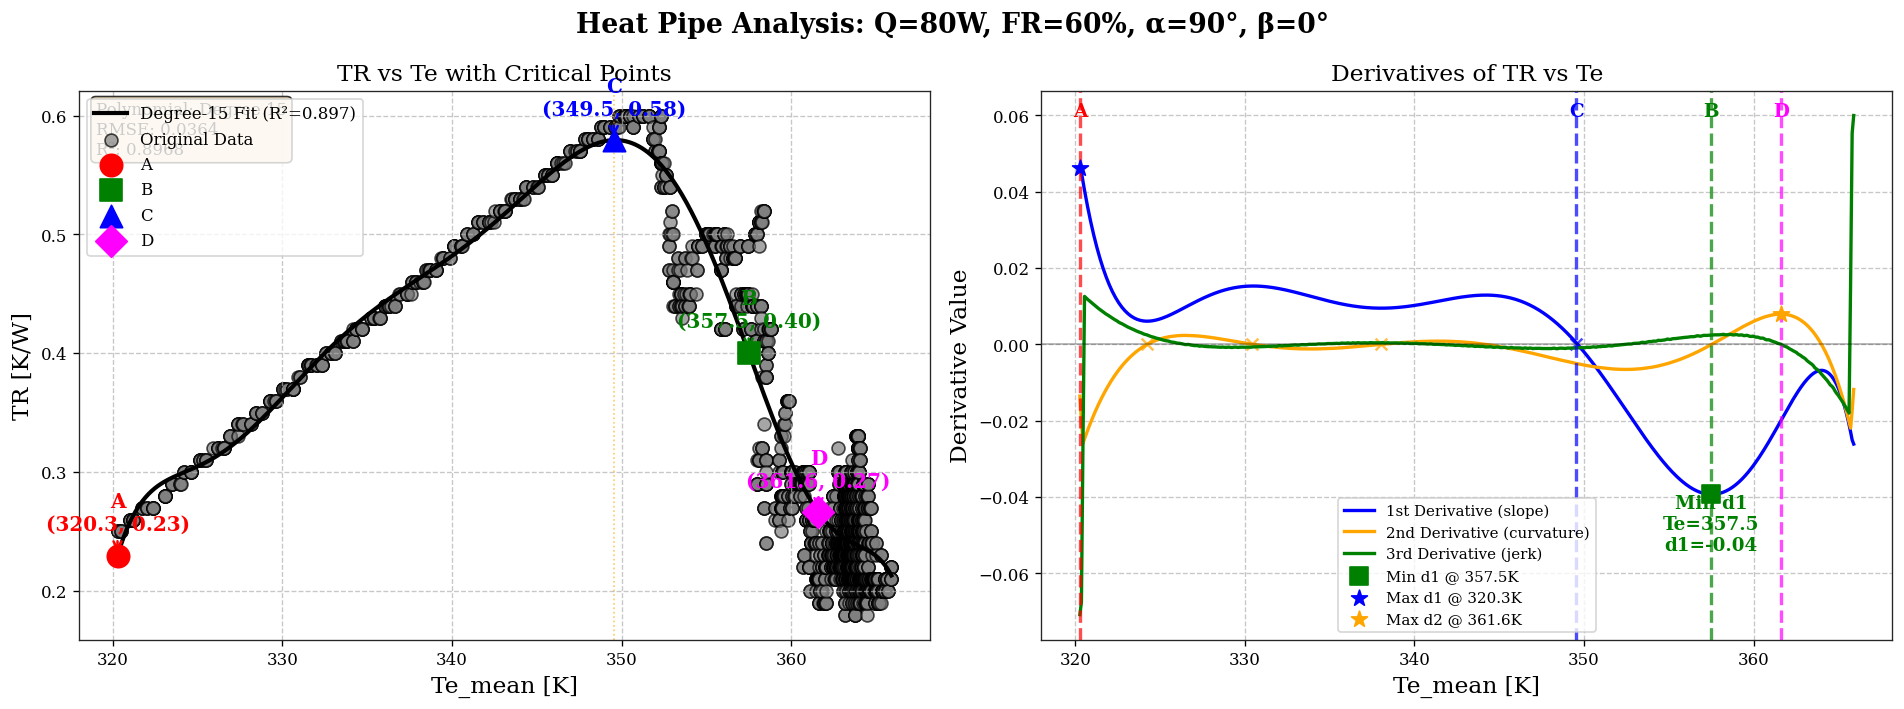

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):
    # Point A: Near to te_min and not closer to te_max
    te_min_val = Te_fine[0]
    te_max_val = Te_fine[-1]
    # Find local minima near te_min and not close to te_max
    min_indices = np.where((np.r_[True, Y_fit[1:] < Y_fit[:-1]] & np.r_[Y_fit[:-1] < Y_fit[1:], True]))[0]
    # Exclude minima too close to te_max (within last 10% of range)
    valid_min_indices = [i for i in min_indices if (Te_fine[i] - te_min_val) < 0.5 * (te_max_val - te_min_val)]
    if valid_min_indices:
        point_A_idx = valid_min_indices[np.argmin(np.abs(Te_fine[valid_min_indices] - te_min_val))]
    else:
        point_A_idx = np.argmin(np.abs(Te_fine - te_min_val))
    # Point B: 1st derivative is minimum, 2nd derivative closest to zero
    d1_min_idx = np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2))
    point_B_idx = d1_min_idx if abs(d2[d1_min_idx]) < 0.1 else d2_near_zero
    # Point C: 1st derivative zero crossing closest to A
    zero_crossings_d1 = _find_zero_crossings(d1)
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmin(np.abs(zero_crossings_d1 - point_A_idx))]
    else:
        point_C_idx = np.argmax(d1)
    # Point D: 2nd derivative is maximum, 3rd derivative closest to zero
    d2_max_idx = np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3))
    point_D_idx = d2_max_idx if abs(d3[d2_max_idx]) < 0.1 else d3_near_zero
    return {
        'A': point_A_idx,
        'B': point_B_idx,
        'C': point_C_idx,
        'D': point_D_idx
    }

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': TR,
        'Te_fine': Te_fine,
        'Y_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'y_label': 'TR',
        'y_unit': 'K/W',
        'rmse': np.sqrt(mean_squared_error(TR, poly(Te))),
        'r2': 1 - np.sum((TR - poly(Te)) ** 2) / np.sum((TR - np.mean(TR)) ** 2)
    }

def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    """Create comprehensive plots for the first relationship only (removes bottom blank plots)"""
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    # Only plot the first analysis in results
    for analysis_type, data in results.items():
        if data is None:
            continue
        # Main relationship plot
        ax1 = axes[0]
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        for label, idx in data['points'].items():
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
            ax1.annotate(f'{label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        for zc in zero_crossings_d1[:3]:
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        # Derivatives plot
        ax2 = axes[1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        for label, idx in data['points'].items():
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
        # Mark min d1 and write its value at the corresponding Te
        min_d1_idx = np.argmin(data['d1'])
        ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='s', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
        ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        ax2.scatter(data['Te_fine'][max_d1_idx], data['d1'][max_d1_idx], color='blue', s=100, marker='*', zorder=10, label=f'Max d1 @ {data["Te_fine"][max_d1_idx]:.1f}K')
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
        break  # Only plot the first analysis
    plt.tight_layout()
    plt.show()

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

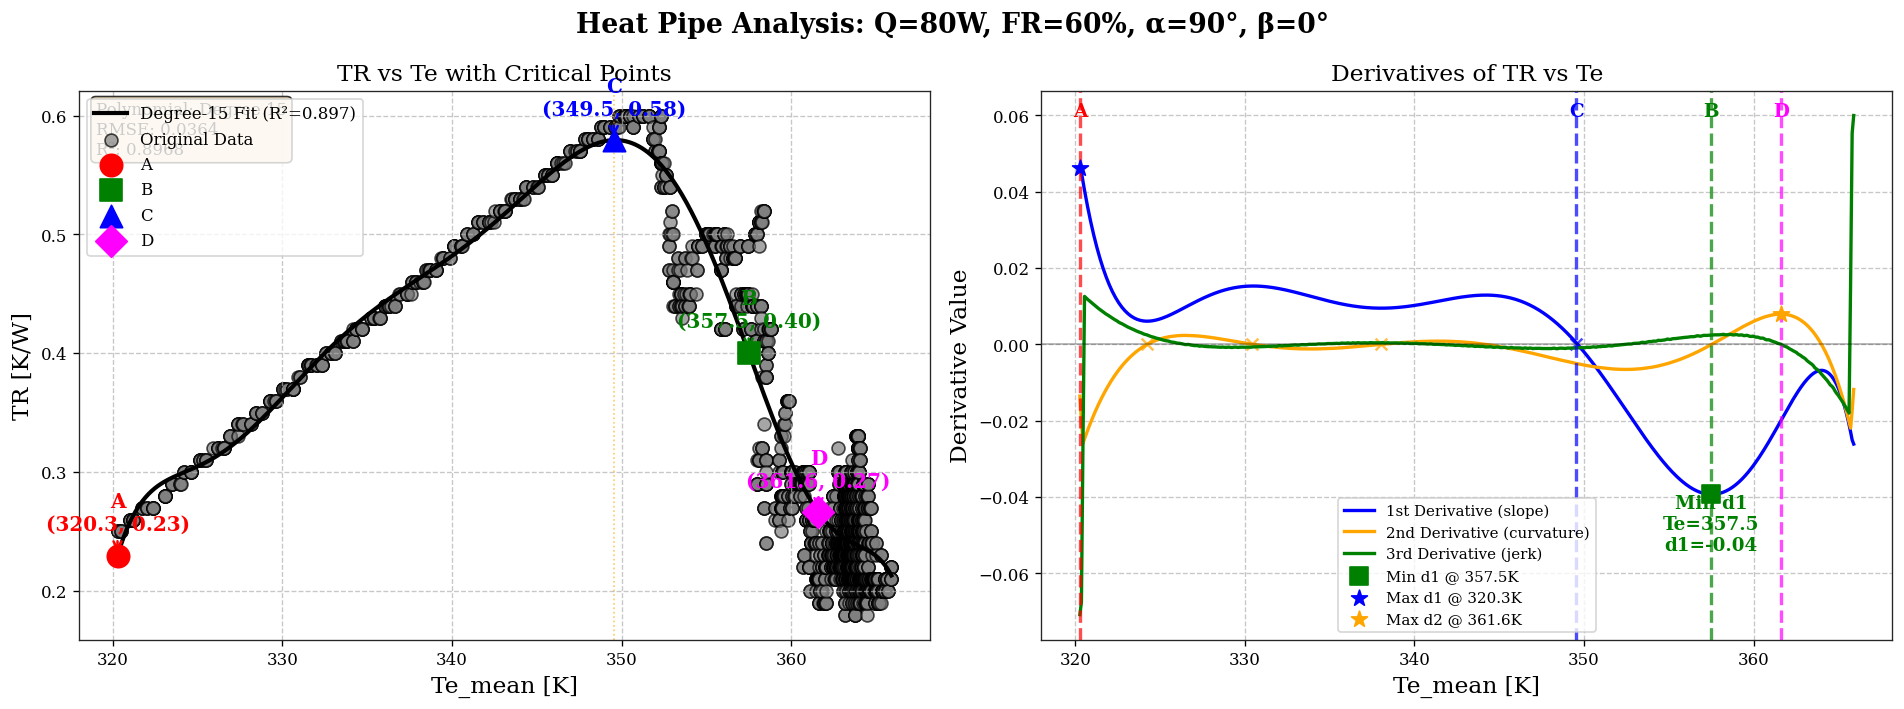

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):
    # Point A: Near to te_min and not closer to te_max
    te_min_val = Te_fine[0]
    te_max_val = Te_fine[-1]
    # Find local minima near te_min and not close to te_max
    min_indices = np.where((np.r_[True, Y_fit[1:] < Y_fit[:-1]] & np.r_[Y_fit[:-1] < Y_fit[1:], True]))[0]
    # Exclude minima too close to te_max (within last 10% of range)
    valid_min_indices = [i for i in min_indices if (Te_fine[i] - te_min_val) < 0.5 * (te_max_val - te_min_val)]
    if valid_min_indices:
        point_A_idx = valid_min_indices[np.argmin(np.abs(Te_fine[valid_min_indices] - te_min_val))]
    else:
        point_A_idx = np.argmin(np.abs(Te_fine - te_min_val))
    # Point B: 1st derivative is minimum, 2nd derivative closest to zero
    d1_min_idx = np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2))
    point_B_idx = d1_min_idx if abs(d2[d1_min_idx]) < 0.1 else d2_near_zero
    # Point C: 1st derivative zero crossing closest to A
    zero_crossings_d1 = _find_zero_crossings(d1)
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmin(np.abs(zero_crossings_d1 - point_A_idx))]
    else:
        point_C_idx = np.argmax(d1)

    # Point D: 2nd derivative is maximum, 3rd derivative closest to zero
    d2_max_idx = np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3))
    point_D_idx = d2_max_idx if abs(d3[d2_max_idx]) < 0.1 else d3_near_zero
    return {
        'A': point_A_idx,
        'B': point_B_idx,
        'C': point_C_idx,
        'D': point_D_idx
    }

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': TR,
        'Te_fine': Te_fine,
        'Y_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'y_label': 'TR',
        'y_unit': 'K/W',
        'rmse': np.sqrt(mean_squared_error(TR, poly(Te))),
        'r2': 1 - np.sum((TR - poly(Te)) ** 2) / np.sum((TR - np.mean(TR)) ** 2)
    }

def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    """Create comprehensive plots for the first relationship only (removes bottom blank plots)"""
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    # Only plot the first analysis in results
    for analysis_type, data in results.items():
        if data is None:
            continue
        # Main relationship plot
        ax1 = axes[0]
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        for label, idx in data['points'].items():
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
            ax1.annotate(f'{label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        for zc in zero_crossings_d1[:3]:
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        # Derivatives plot
        ax2 = axes[1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        for label, idx in data['points'].items():
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
        # Mark min d1 and write its value at the corresponding Te
        min_d1_idx = np.argmin(data['d1'])
        ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='s', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
        ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        ax2.scatter(data['Te_fine'][max_d1_idx], data['d1'][max_d1_idx], color='blue', s=100, marker='*', zorder=10, label=f'Max d1 @ {data["Te_fine"][max_d1_idx]:.1f}K')
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
        break  # Only plot the first analysis
    plt.tight_layout()
    plt.show()

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 40 W

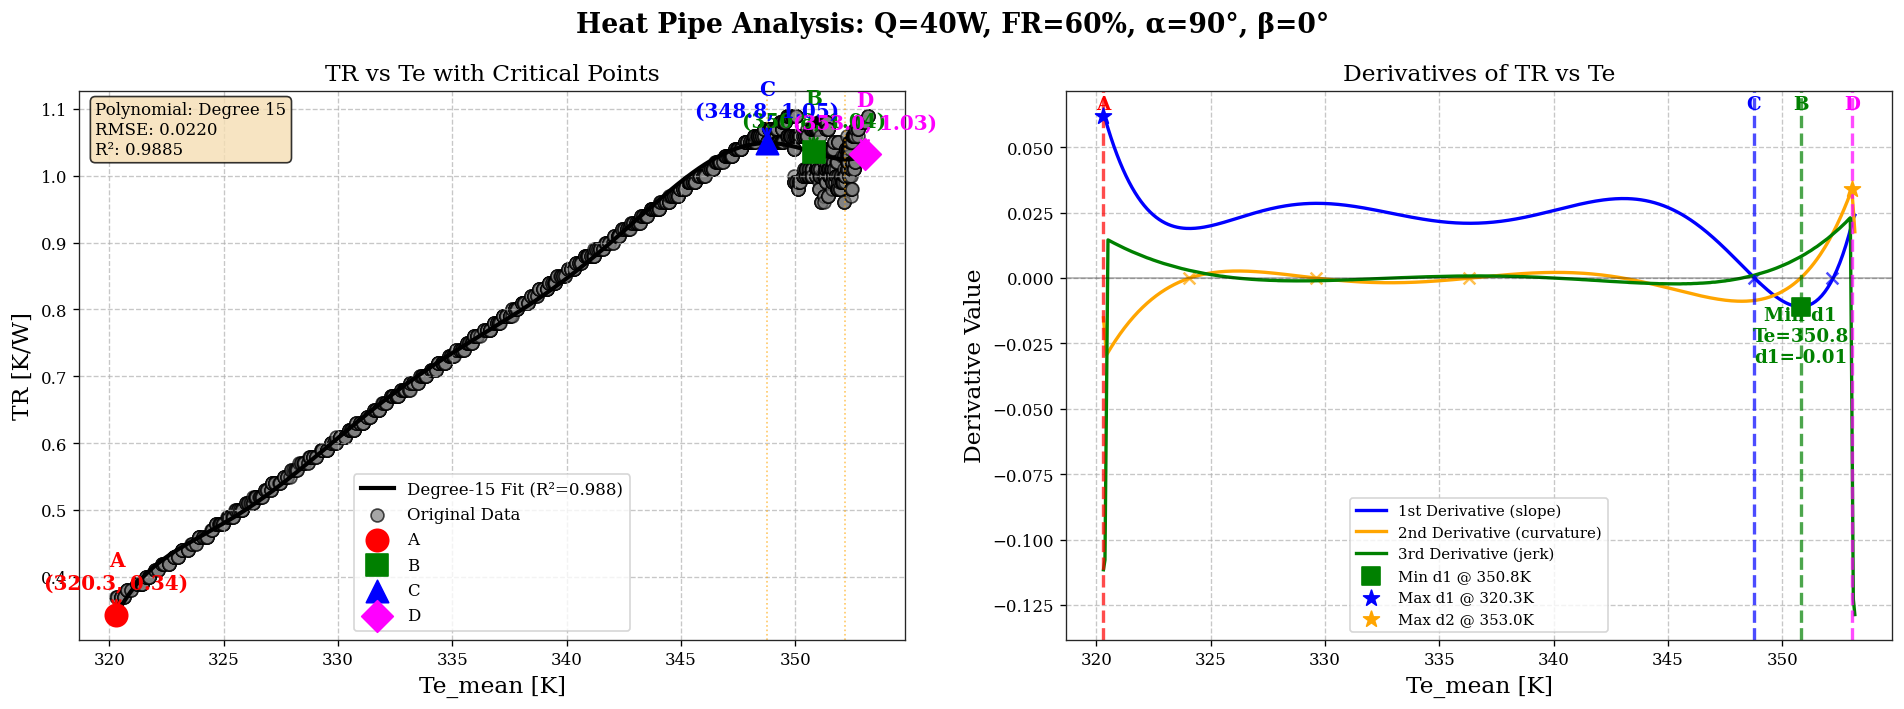

In [10]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 40, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 60 W

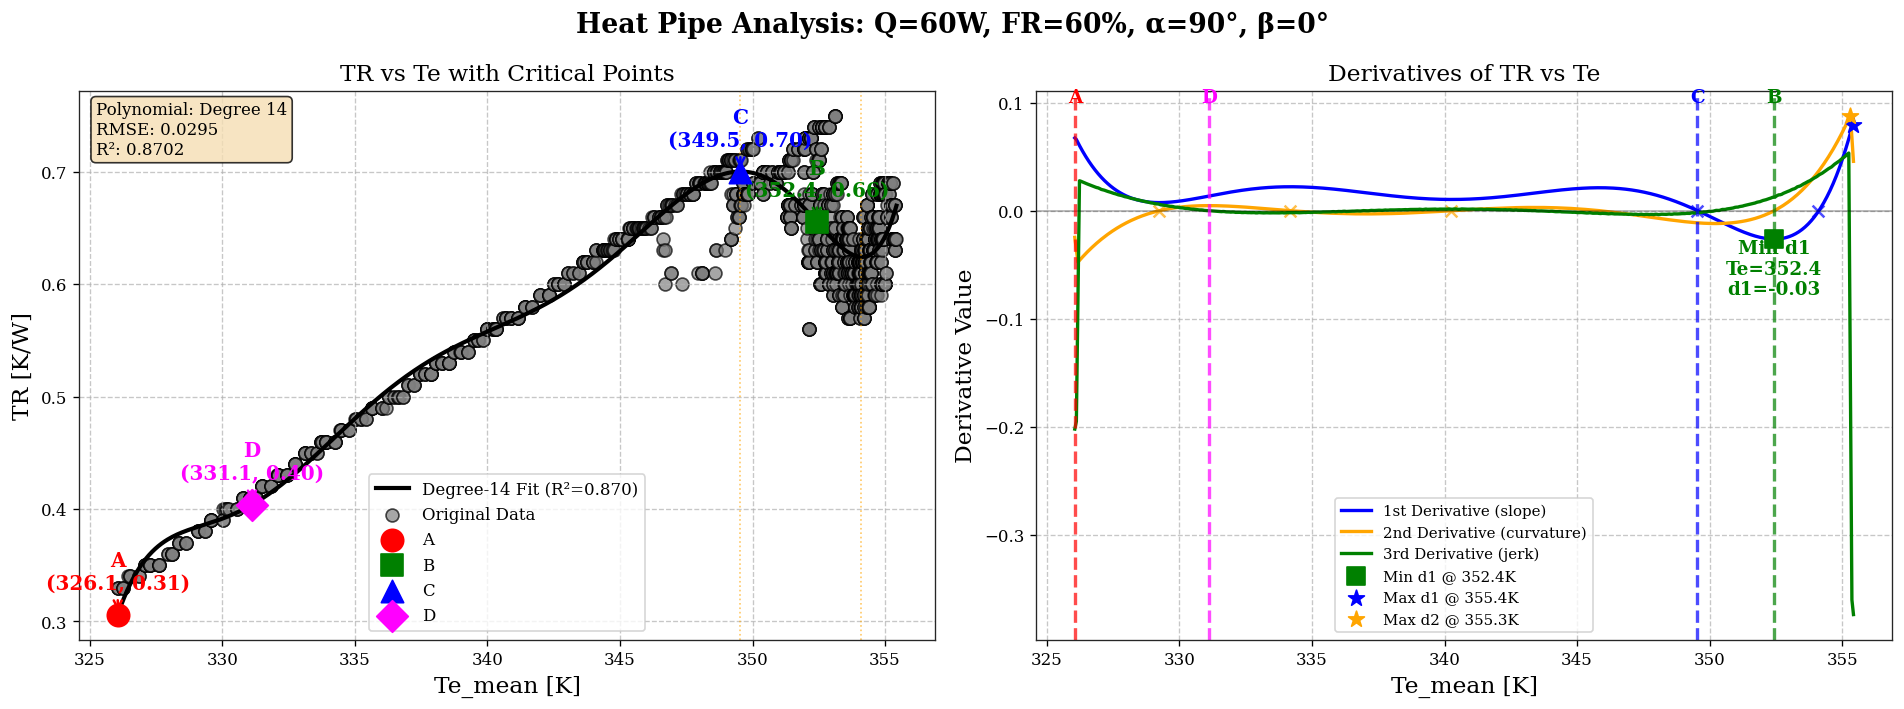

In [11]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 60, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 80 W

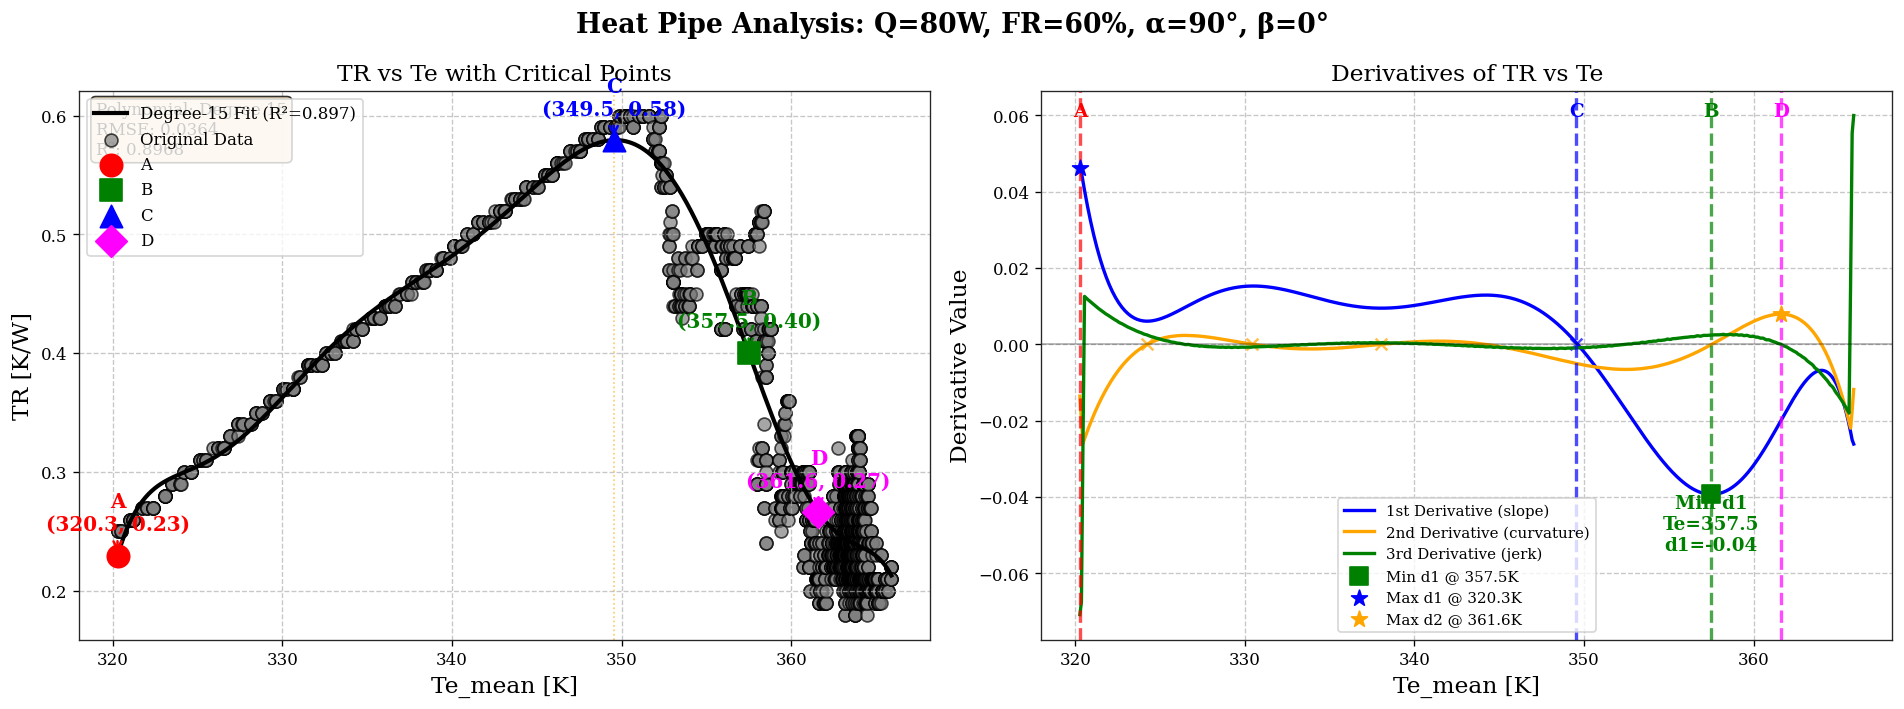

In [12]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 100 W

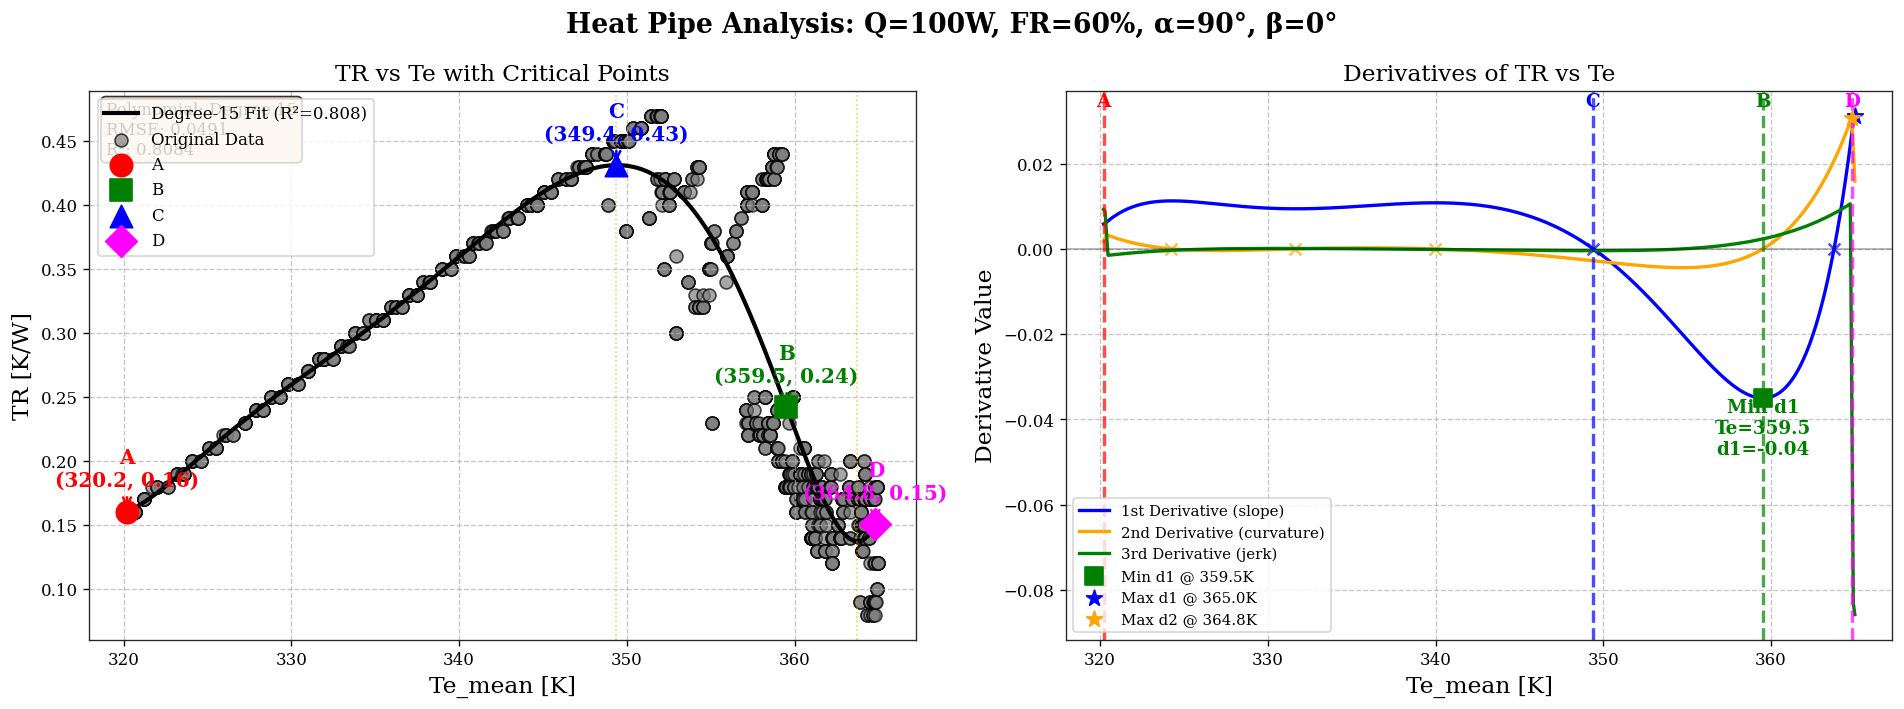

In [13]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 100, 60, 90, 0
te_min, te_max = 320, 365
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 120 W

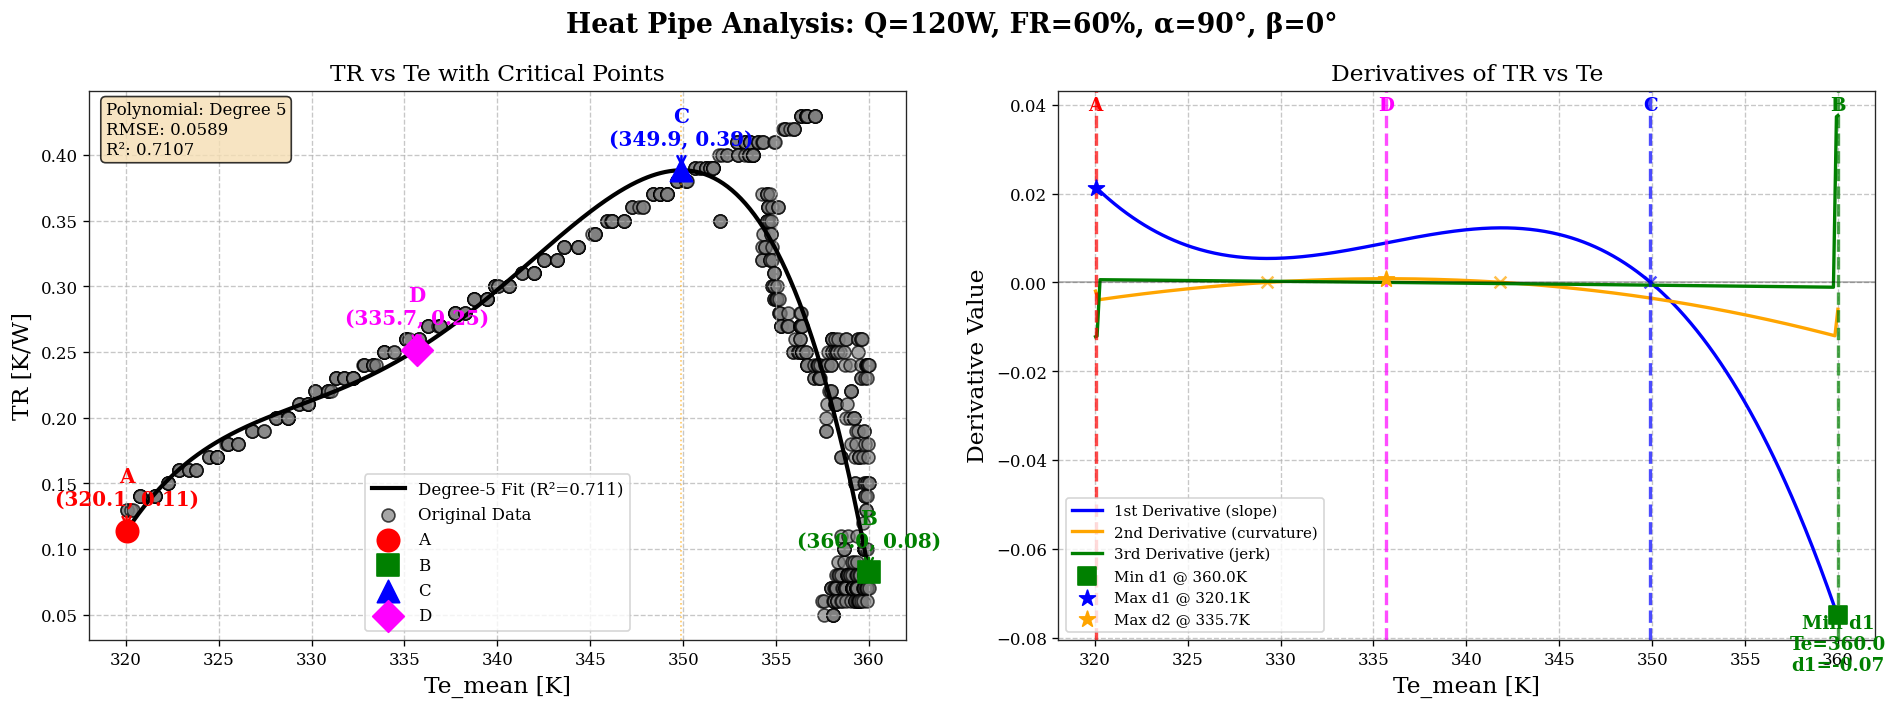

In [14]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 360
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=5,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

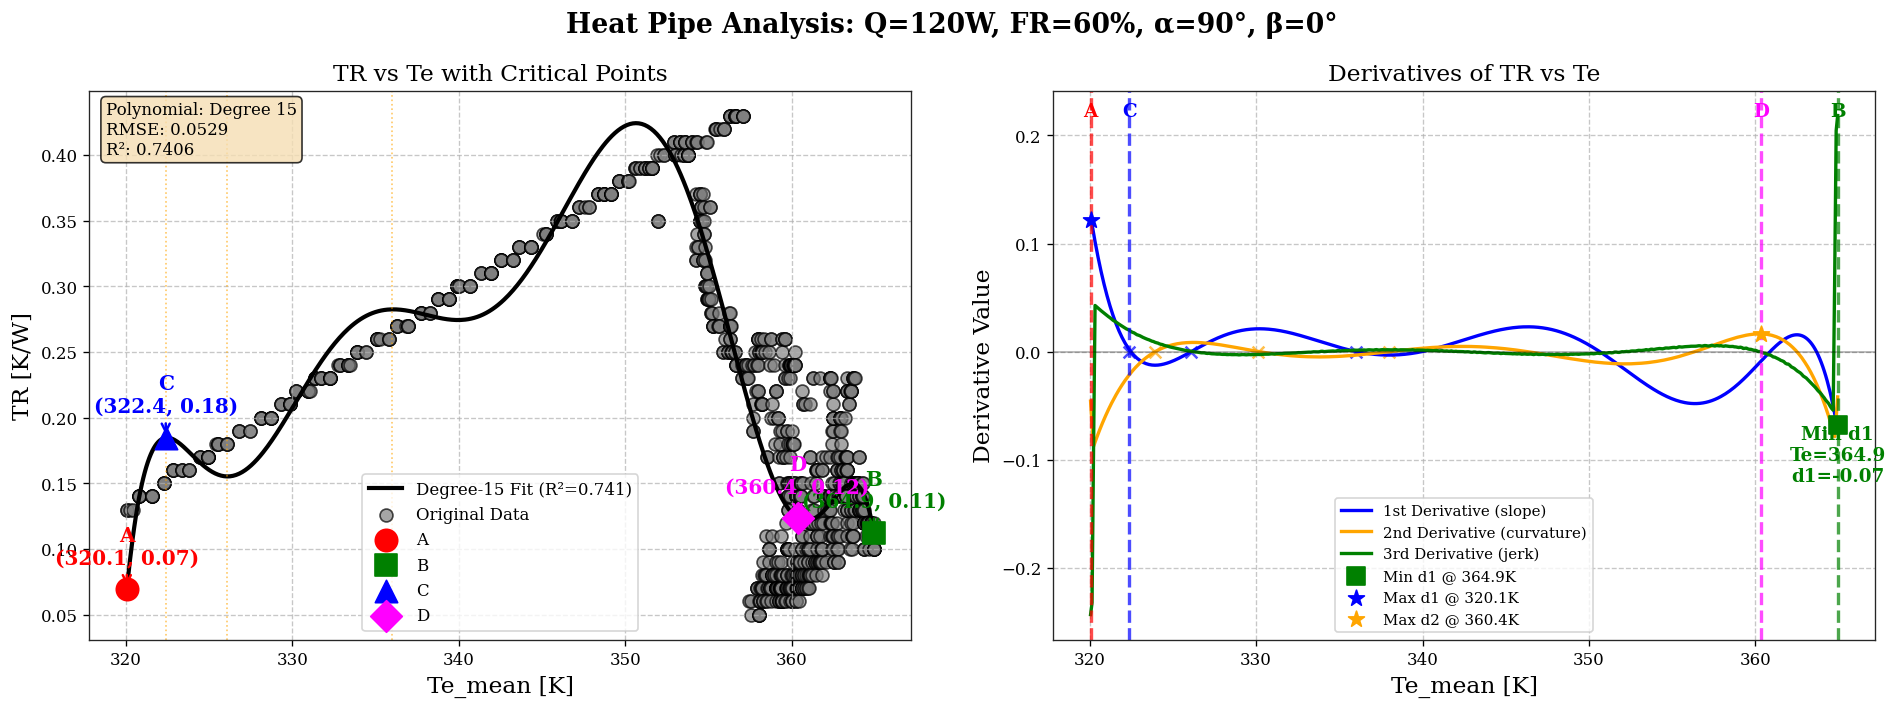

In [15]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 365
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

# Main_TR Analysis


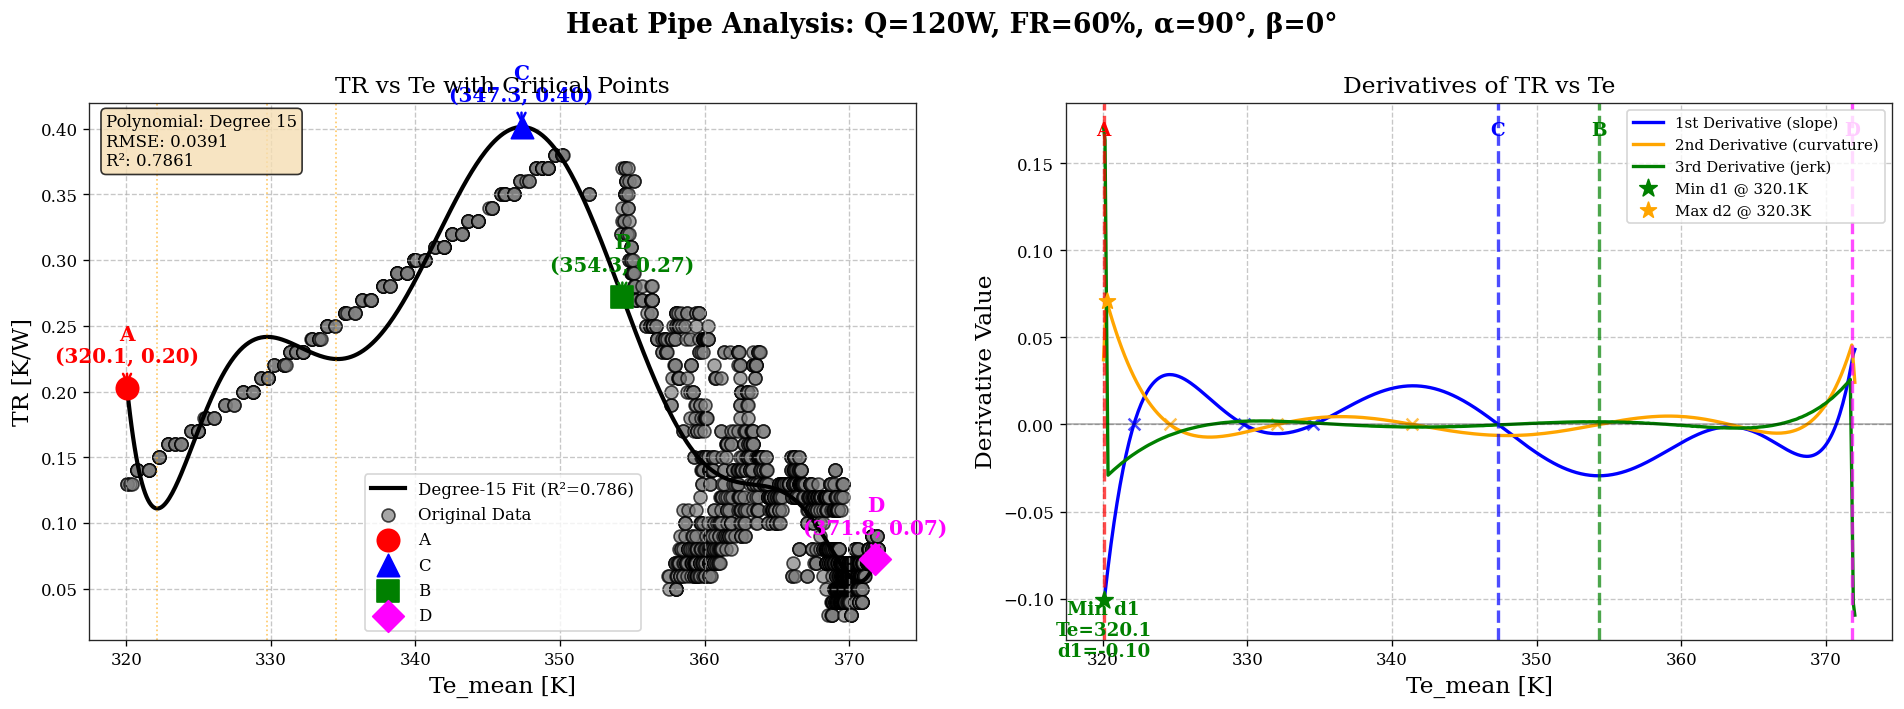

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):
    # Point A: Always first, minimum Te
    point_A_idx = 0 if len(Te_fine) > 0 else None

    # Point C: 1st derivative zero and maximum TR, always second
    zero_crossings_d1 = _find_zero_crossings(d1)
    point_C_idx = None
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmax(Y_fit[zero_crossings_d1])]
    else:
        point_C_idx = np.argmax(Y_fit)

    # Point B: 1st derivative is minimum and 2nd derivative is closer to zero or equal to zero. Always third, after C
    d1_min_idx = np.argmin(d1[point_C_idx+1:]) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d1) else np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2[point_C_idx+1:])) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d2) else np.argmin(np.abs(d2))
    if abs(d2[d1_min_idx]) < 0.1:
        point_B_idx = d1_min_idx
    else:
        point_B_idx = d2_near_zero

    # Point D: 2nd derivative is maximum and 3rd derivative is closer to zero or equal to zero. Always last, after B
    d2_max_idx = np.argmax(d2[point_B_idx+1:]) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d2) else np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3[point_B_idx+1:])) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d3) else np.argmin(np.abs(d3))
    if abs(d3[d2_max_idx]) < 0.1:
        point_D_idx = d2_max_idx
    else:
        point_D_idx = d3_near_zero

    # Sequence: A, C, B, D from Te_min to Te_max
    return {
        'A': point_A_idx,
        'C': point_C_idx,
        'B': point_B_idx,
        'D': point_D_idx
    }

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': TR,
        'Te_fine': Te_fine,
        'Y_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'y_label': 'TR',
        'y_unit': 'K/W',
        'rmse': np.sqrt(mean_squared_error(TR, poly(Te))),
        'r2': 1 - np.sum((TR - poly(Te)) ** 2) / np.sum((TR - np.mean(TR)) ** 2)
    }

def _create_comprehensive_plots(results, Q, FR, alpha, beta):
    """Create comprehensive plots for the first relationship only (removes bottom blank plots)"""
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Heat Pipe Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    # Only plot the first analysis in results
    for analysis_type, data in results.items():
        if data is None:
            continue
        # Main relationship plot
        ax1 = axes[0]
        poly_deg = data.get('poly_degree', 'Unknown')
        rmse = data.get('rmse', 0)
        r2 = data.get('r2', 0)
        ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Degree-{poly_deg} Fit (R²={r2:.3f})')
        ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label='Original Data')
        fit_text = f'Polynomial: Degree {poly_deg}\nRMSE: {rmse:.4f}\nR²: {r2:.4f}'
        ax1.text(0.02, 0.98, fit_text, transform=ax1.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        for label, idx in data['points'].items():
            ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{label}')
            ax1.annotate(f'{label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
        zero_crossings_d1 = _find_zero_crossings(data['d1'])
        zero_crossings_d2 = _find_zero_crossings(data['d2'])
        for zc in zero_crossings_d1[:3]:
            ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
        ax1.set_xlabel('Te_mean [K]', fontsize=14)
        ax1.set_ylabel(f'{data["y_label"]} [{data["y_unit"]}]', fontsize=14)
        ax1.set_title(f'{data["y_label"]} vs Te with Critical Points', fontsize=14)
        ax1.legend(fontsize=10, loc='best')
        ax1.grid(True, alpha=0.7)
        # Derivatives plot
        ax2 = axes[1]
        ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
        ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
        ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
        for label, idx in data['points'].items():
            ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
            ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, label, color=colors[label], fontweight='bold', ha='center')
        # Mark min d1 and write its value at the corresponding Te
        min_d1_idx = np.argmin(data['d1'])
        ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
        ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
        max_d1_idx = np.argmax(data['d1'])
        max_d2_idx = np.argmax(data['d2'])
        max_d3_idx = np.argmax(np.abs(data['d3']))
        ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
        for zc in zero_crossings_d1[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
        for zc in zero_crossings_d2[:3]:
            ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)
        ax2.set_xlabel('Te_mean [K]', fontsize=14)
        ax2.set_ylabel('Derivative Value', fontsize=14)
        ax2.set_title(f'Derivatives of {data["y_label"]} vs Te', fontsize=14)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.7)
        break  # Only plot the first analysis
    plt.tight_layout()
    plt.show()

# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 390
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 80 W

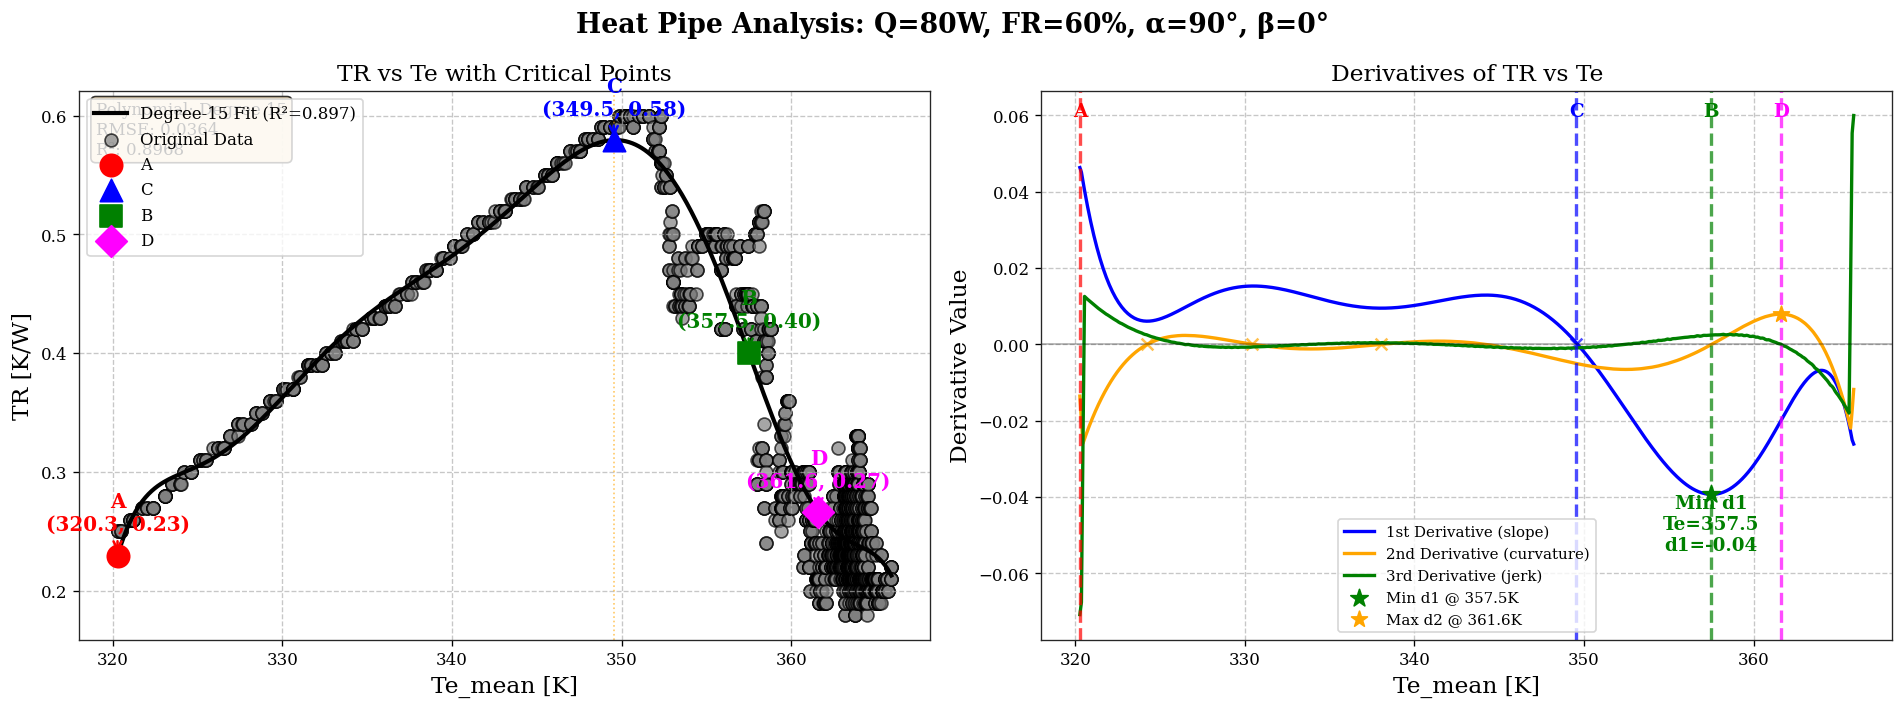

In [17]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 370
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 100 W

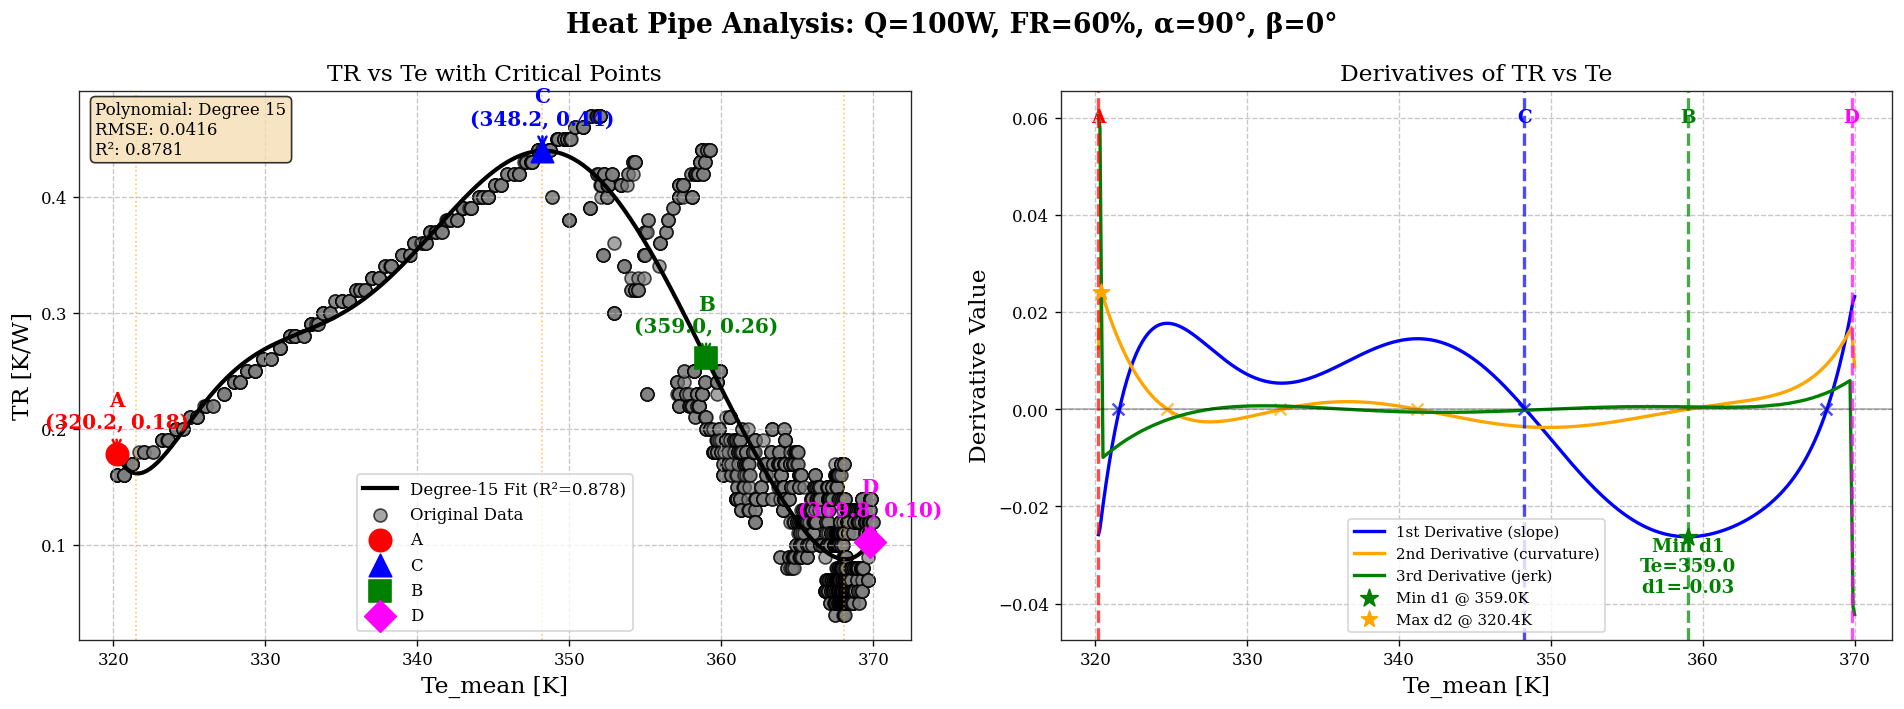

In [18]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 100, 60, 90, 0
te_min, te_max = 320, 370
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=15,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

## 120 W

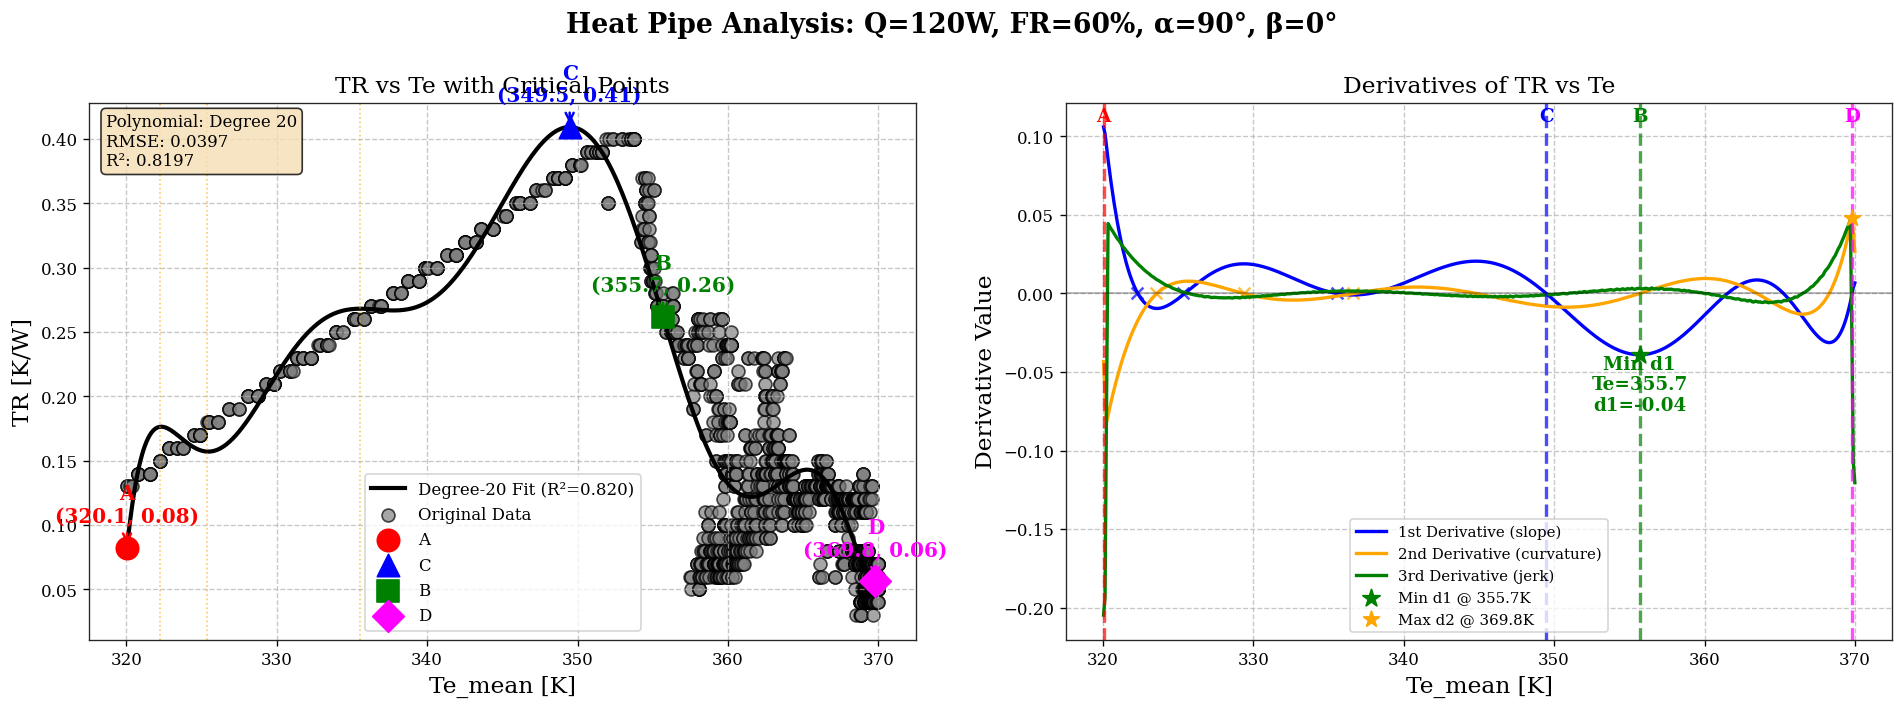

In [19]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 370
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=20,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

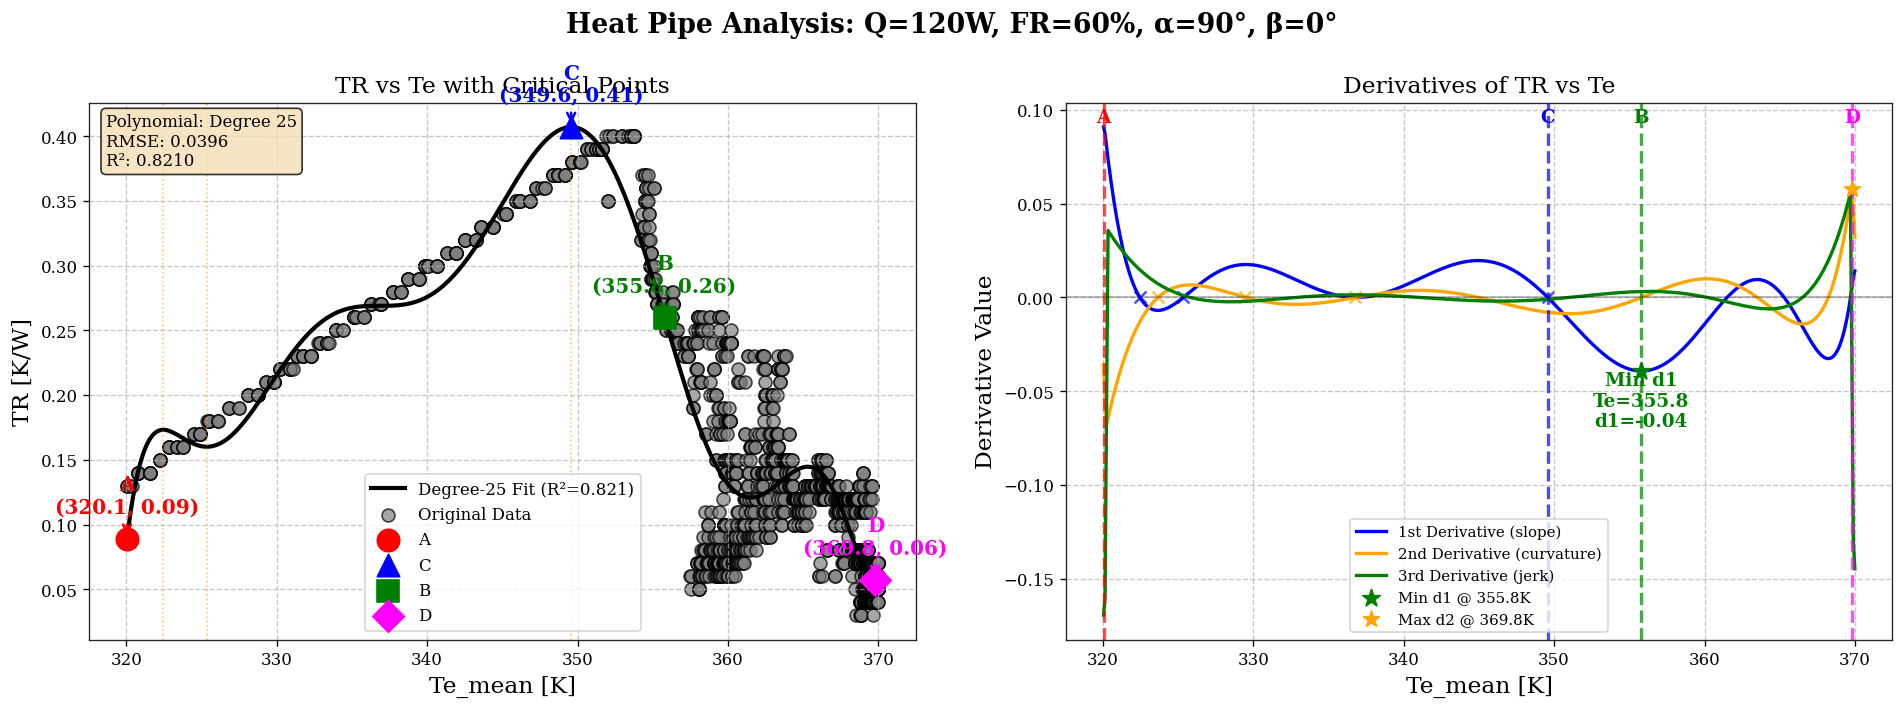

In [20]:
# Example usage:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 370
results_TR = {'TR_analysis': analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=25,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=3
)}
_create_comprehensive_plots(results_TR, Q, FR, alpha, beta)

# TR, Tc, P vs Te - JTAC Special Issue

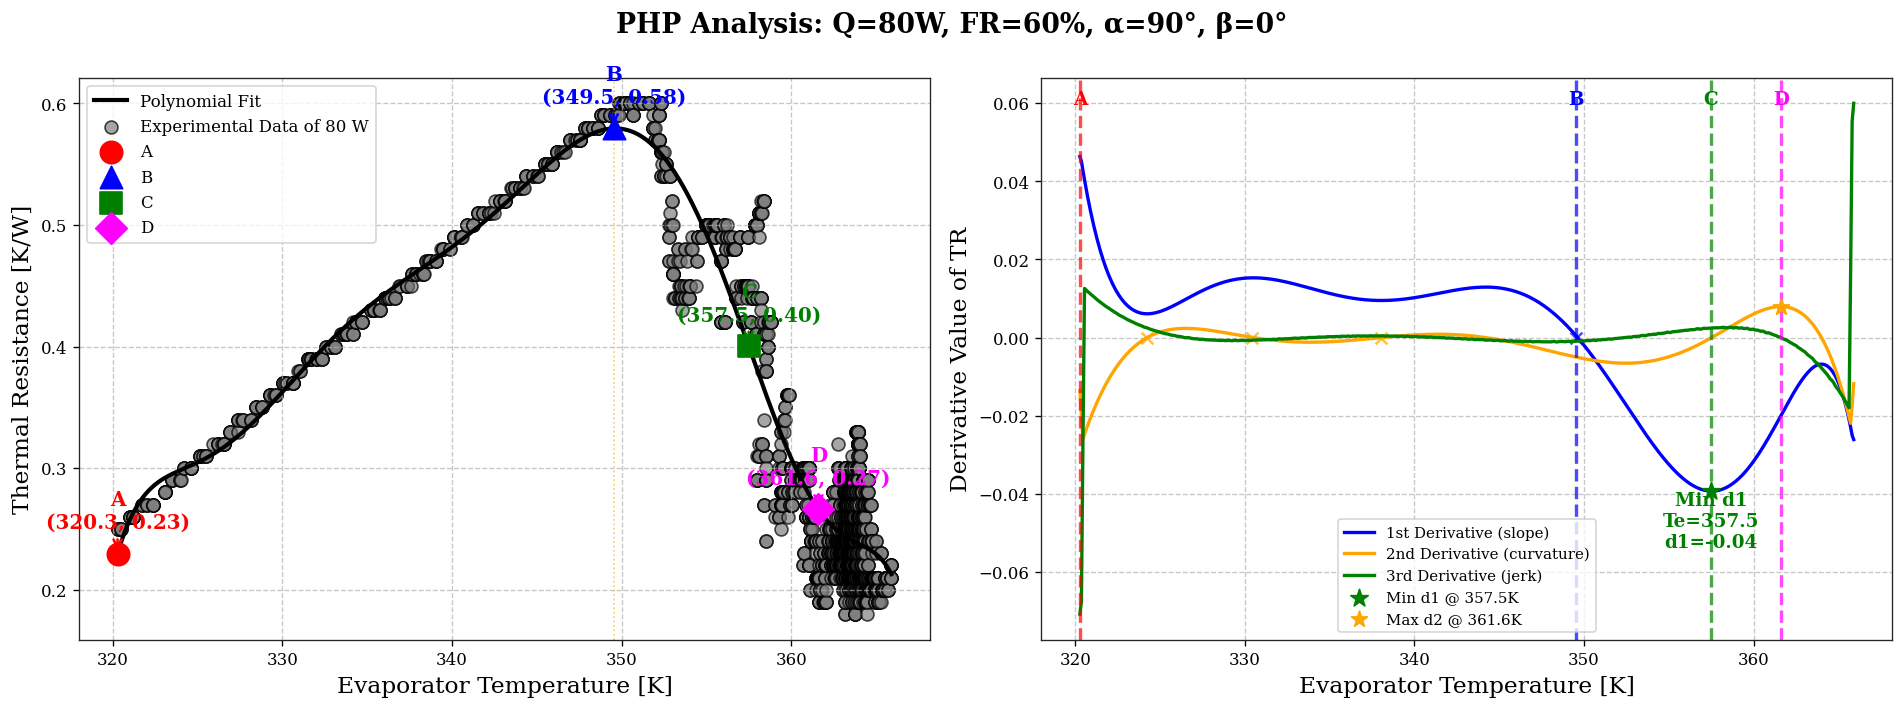

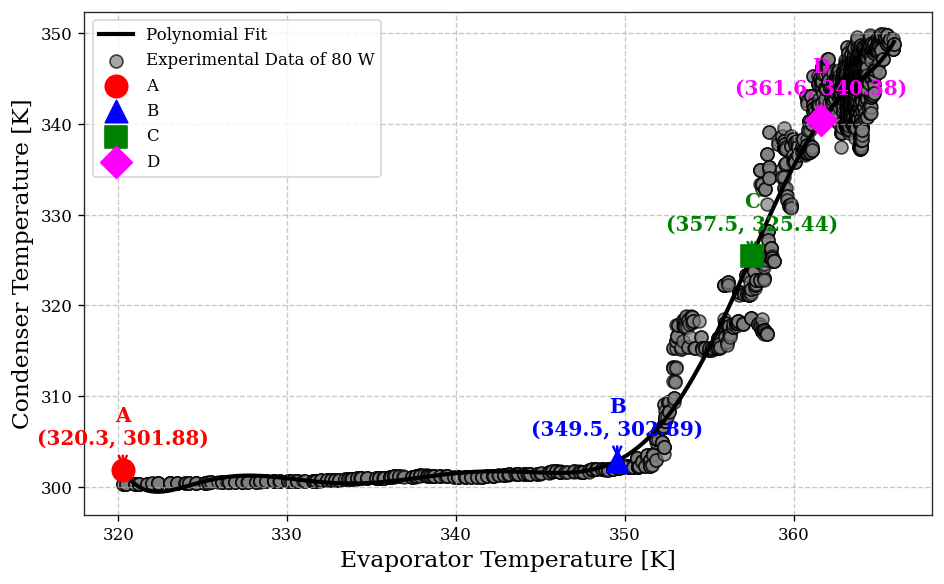

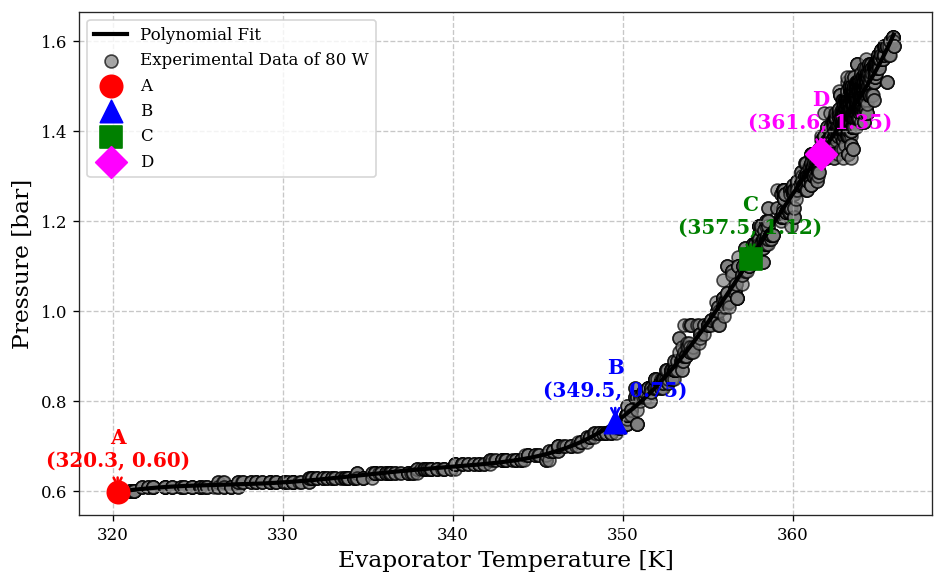

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# --- TR vs Te Analysis (Code 1) ---

def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te) // 3))
    rmse_scores, aic_scores, bic_scores, r2_scores = [], [], [], []
    Te_reshaped = Te.reshape(-1, 1)
    for degree in degrees:
        try:
            poly_pipeline = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('linear', LinearRegression())
            ])
            cv_scores = cross_val_score(poly_pipeline, Te_reshaped, Y, cv=min(cv_folds, len(Te)//2), scoring='neg_root_mean_squared_error')
            rmse_cv = -cv_scores.mean()
            rmse_scores.append(rmse_cv)
            poly_pipeline.fit(Te_reshaped, Y)
            Y_pred = poly_pipeline.predict(Te_reshaped)
            mse = mean_squared_error(Y, Y_pred)
            n = len(Y)
            k = degree + 1
            ss_res = np.sum((Y - Y_pred) ** 2)
            ss_tot = np.sum((Y - np.mean(Y)) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            r2_scores.append(r2)
            aic = n * np.log(mse) + 2 * k
            bic = n * np.log(mse) + k * np.log(n)
            aic_scores.append(aic)
            bic_scores.append(bic)
        except Exception:
            rmse_scores.append(float('inf'))
            aic_scores.append(float('inf'))
            bic_scores.append(float('inf'))
            r2_scores.append(-float('inf'))
    degrees = np.array(degrees)
    rmse_scores = np.array(rmse_scores)
    aic_scores = np.array(aic_scores)
    bic_scores = np.array(bic_scores)
    r2_scores = np.array(r2_scores)
    valid_idx = np.isfinite(rmse_scores)
    if not np.any(valid_idx):
        return {'optimal_degree': 5, 'method': 'default', 'rmse': float('inf')}
    best_rmse_idx = np.argmin(rmse_scores[valid_idx])
    best_aic_idx = np.argmin(aic_scores[valid_idx])
    best_bic_idx = np.argmin(bic_scores[valid_idx])
    best_rmse_degree = degrees[valid_idx][best_rmse_idx]
    best_aic_degree = degrees[valid_idx][best_aic_idx]
    best_bic_degree = degrees[valid_idx][best_bic_idx]
    rmse_norm = (rmse_scores - np.min(rmse_scores[valid_idx])) / (np.max(rmse_scores[valid_idx]) - np.min(rmse_scores[valid_idx]) + 1e-10)
    aic_norm = (aic_scores - np.min(aic_scores[valid_idx])) / (np.max(aic_scores[valid_idx]) - np.min(aic_scores[valid_idx]) + 1e-10)
    composite_scores = 0.6 * rmse_norm + 0.4 * aic_norm
    best_composite_idx = np.argmin(composite_scores[valid_idx])
    best_composite_degree = degrees[valid_idx][best_composite_idx]
    optimal_degree = best_composite_degree
    optimal_rmse = rmse_scores[valid_idx][best_composite_idx]
    optimal_r2 = r2_scores[valid_idx][best_composite_idx]
    return {
        'optimal_degree': int(optimal_degree),
        'method': 'composite_score',
        'rmse': optimal_rmse,
        'r2': optimal_r2,
        'degrees_tested': degrees[valid_idx].tolist(),
        'rmse_scores': rmse_scores[valid_idx].tolist(),
        'aic_scores': aic_scores[valid_idx].tolist(),
        'bic_scores': bic_scores[valid_idx].tolist(),
        'best_rmse_degree': int(best_rmse_degree),
        'best_aic_degree': int(best_aic_degree),
        'best_bic_degree': int(best_bic_degree)
    }

def _find_zero_crossings(arr):
    zero_crossings = []
    for i in range(len(arr) - 1):
        if arr[i] * arr[i + 1] < 0:
            zero_crossings.append(i)
    return np.array(zero_crossings)

def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):
    # Point A: Always first, minimum Te
    point_A_idx = 0 if len(Te_fine) > 0 else None

    # Point C: 1st derivative zero and maximum TR, always second
    zero_crossings_d1 = _find_zero_crossings(d1)
    point_C_idx = None
    if len(zero_crossings_d1) > 0:
        point_C_idx = zero_crossings_d1[np.argmax(Y_fit[zero_crossings_d1])]
    else:
        point_C_idx = np.argmax(Y_fit)

    # Point B: 1st derivative is minimum and 2nd derivative is closer to zero or equal to zero. Always third, after C
    d1_min_idx = np.argmin(d1[point_C_idx+1:]) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d1) else np.argmin(d1)
    d2_near_zero = np.argmin(np.abs(d2[point_C_idx+1:])) + point_C_idx + 1 if point_C_idx is not None and point_C_idx+1 < len(d2) else np.argmin(np.abs(d2))
    if abs(d2[d1_min_idx]) < 0.1:
        point_B_idx = d1_min_idx
    else:
        point_B_idx = d2_near_zero

    # Point D: 2nd derivative is maximum and 3rd derivative is closer to zero or equal to zero. Always last, after B
    d2_max_idx = np.argmax(d2[point_B_idx+1:]) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d2) else np.argmax(d2)
    d3_near_zero = np.argmin(np.abs(d3[point_B_idx+1:])) + point_B_idx + 1 if point_B_idx is not None and point_B_idx+1 < len(d3) else np.argmin(np.abs(d3))
    if abs(d3[d2_max_idx]) < 0.1:
        point_D_idx = d2_max_idx
    else:
        point_D_idx = d3_near_zero

    # Sequence: A, C, B, D from Te_min to Te_max
    return {
        'A': point_A_idx,
        'C': point_C_idx,
        'B': point_B_idx,
        'D': point_D_idx
    }

def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg='auto', outlier_threshold=2.5, max_poly_deg=15, min_poly_deg=2):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty or 'TR[K/W]' not in df_filtered.columns:
        print("No data found for given condition/range or missing TR[K/W] column.")
        return None
    df_tr_clean = df_filtered[np.abs(zscore(df_filtered['TR[K/W]'])) < outlier_threshold]
    Te = df_tr_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
    TR = df_tr_clean.sort_values('Te_mean[K]')['TR[K/W]'].values
    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None
    if poly_deg == 'auto':
        opt_result = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
        poly_deg = opt_result['optimal_degree']
    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    TR_fit = poly(Te_fine)
    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)
    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3)
    return {
        'Te_original': Te,
        'Y_original': TR,
        'Te_fine': Te_fine,
        'Y_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'y_label': 'TR',
        'y_unit': 'K/W',
        'rmse': np.sqrt(mean_squared_error(TR, poly(Te))),
        'r2': 1 - np.sum((TR - poly(Te)) ** 2) / np.sum((TR - np.mean(TR)) ** 2)
    }

# --- Tc vs Te and P vs Te Analysis (Code 2, with A/B/C/D from TR) ---

def analyze_heat_pipe_data(csv_path, Q, FR, alpha, beta, te_min, te_max, 
                          poly_deg='auto', outlier_threshold=2.5, 
                          max_poly_deg=15, min_poly_deg=2, tr_points=None, tr_Te_fine=None):
    df = pd.read_csv(csv_path)
    df_sel = df[(df['Q[W]'] == Q) & (df['FR[%]'] == FR) & 
                (df['alpha'] == alpha) & (df['beta'] == beta)]
    df_filtered = df_sel[(df_sel['Te_mean[K]'] >= te_min) & 
                        (df_sel['Te_mean[K]'] <= te_max)].copy()
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None
    df_tc_clean = df_filtered[np.abs(zscore(df_filtered['Tc_mean[K]'])) < outlier_threshold]
    df_p_clean = df_filtered[np.abs(zscore(df_filtered['P[bar]'])) < outlier_threshold]
    results = {}
    # Tc vs Te
    if len(df_tc_clean) > min_poly_deg:
        Te_tc = df_tc_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        Tc_tc = df_tc_clean.sort_values('Te_mean[K]')['Tc_mean[K]'].values
        if poly_deg == 'auto':
            tc_opt_result = optimize_polynomial_degree(Te_tc, Tc_tc, max_poly_deg, min_poly_deg)
            tc_poly_deg = tc_opt_result['optimal_degree']
        else:
            tc_poly_deg = poly_deg
        results['tc'] = _polyfit_and_plot_with_points(Te_tc, Tc_tc, tc_poly_deg, 'Tc_mean [K]', 'Tc vs Te', Q, tr_points, tr_Te_fine)
    else:
        print("Insufficient Tc data points for analysis")
    # P vs Te
    if len(df_p_clean) > min_poly_deg:
        Te_p = df_p_clean.sort_values('Te_mean[K]')['Te_mean[K]'].values
        P_p = df_p_clean.sort_values('Te_mean[K]')['P[bar]'].values
        if poly_deg == 'auto':
            p_opt_result = optimize_polynomial_degree(Te_p, P_p, max_poly_deg, min_poly_deg)
            p_poly_deg = p_opt_result['optimal_degree']
        else:
            p_poly_deg = poly_deg
        results['p'] = _polyfit_and_plot_with_points(Te_p, P_p, p_poly_deg, 'P [bar]', 'P vs Te', Q, tr_points, tr_Te_fine)
    else:
        print("Insufficient P data points for analysis")
    return results

def _polyfit_and_plot_with_points(Te, Y, poly_deg, y_label, title, Q, tr_points, tr_Te_fine):
    coeffs = np.polyfit(Te, Y, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Y_fit = poly(Te_fine)
    Y_pred = poly(Te)
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))
    plt.figure(figsize=(8, 5))
    plt.plot(Te_fine, Y_fit, '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    plt.scatter(Te, Y, color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    plt.xlabel('Evaporator Temperature [K]', fontsize=14)
    if y_label == 'Tc_mean [K]':
        plt.ylabel('Condenser Temperature [K]', fontsize=14)
    elif y_label == 'P [bar]':
        plt.ylabel('Pressure [bar]', fontsize=14)
    else:
        plt.ylabel(y_label, fontsize=14)
    #plt.title(title, fontsize=14)
    # Add points A, B, C, D from TR analysis, but swap display names of B and C
    if tr_points is not None and tr_Te_fine is not None:
        colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
        markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
        for label, idx in tr_points.items():
            # Swap display names for B and C
            if label == 'B':
                plot_label = 'C'
            elif label == 'C':
                plot_label = 'B'
            else:
                plot_label = label
            if idx is not None and 0 <= idx < len(Te_fine):
                plt.scatter(Te_fine[idx], Y_fit[idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
                plt.annotate(f'{plot_label}\n({Te_fine[idx]:.1f}, {Y_fit[idx]:.2f})', (Te_fine[idx], Y_fit[idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    plt.legend(fontsize=10, loc='best')
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()
    return {
        'Te': Te,
        'Y': Y,
        'Te_fine': Te_fine,
        'Y_fit': Y_fit,
        'poly_coeffs': coeffs,
        'poly_degree': poly_deg,
        'rmse': rmse
    }

# --- Example usage ---

csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 370

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

## 80 W

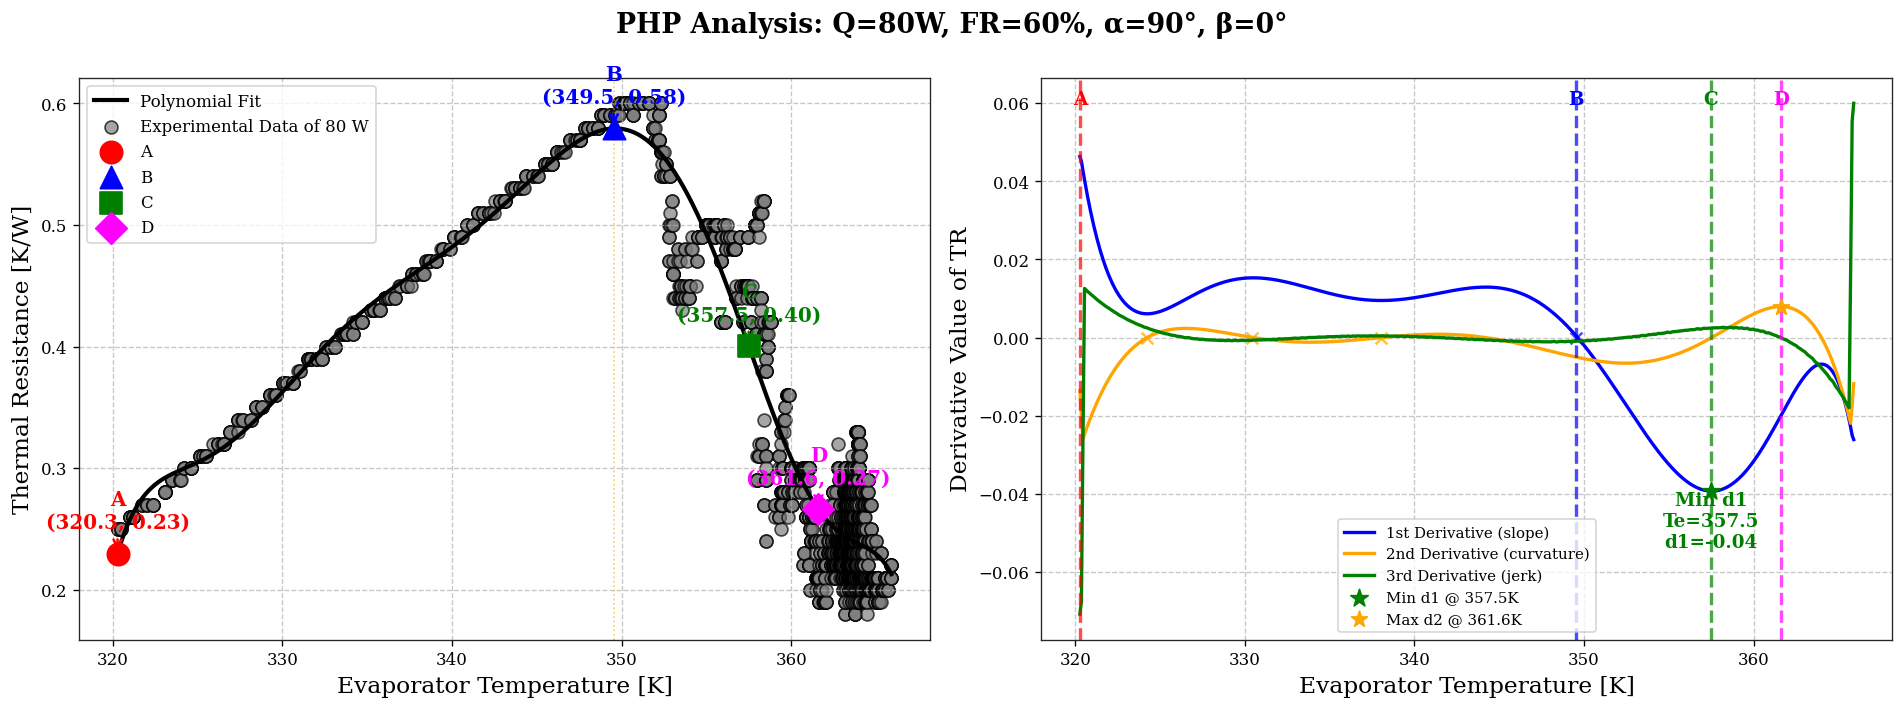

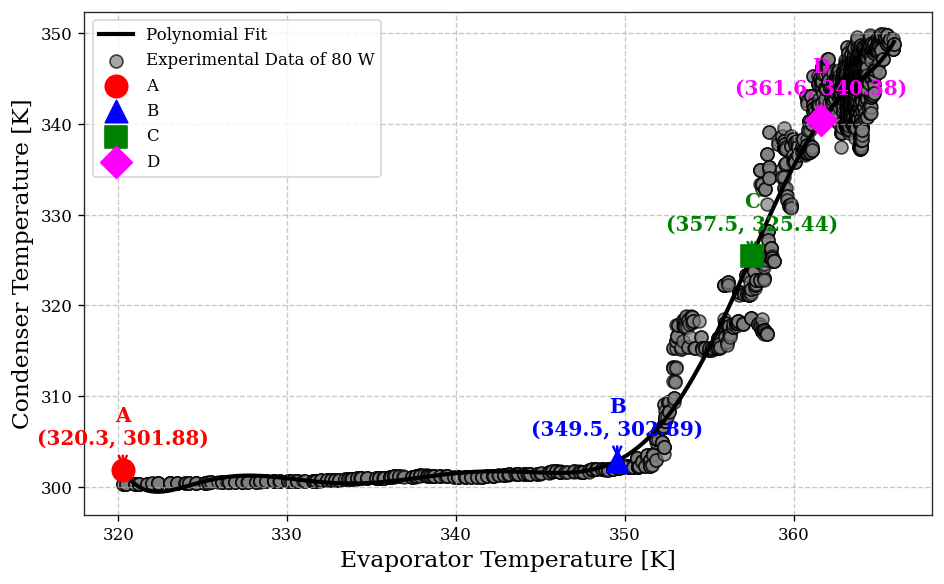

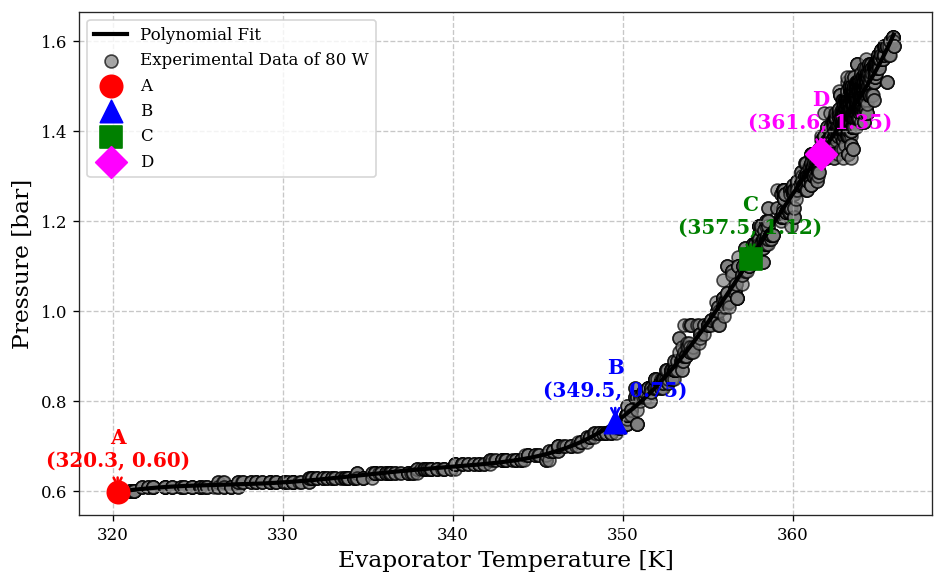

In [22]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 370

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### 80 W - JTAC Special Issue

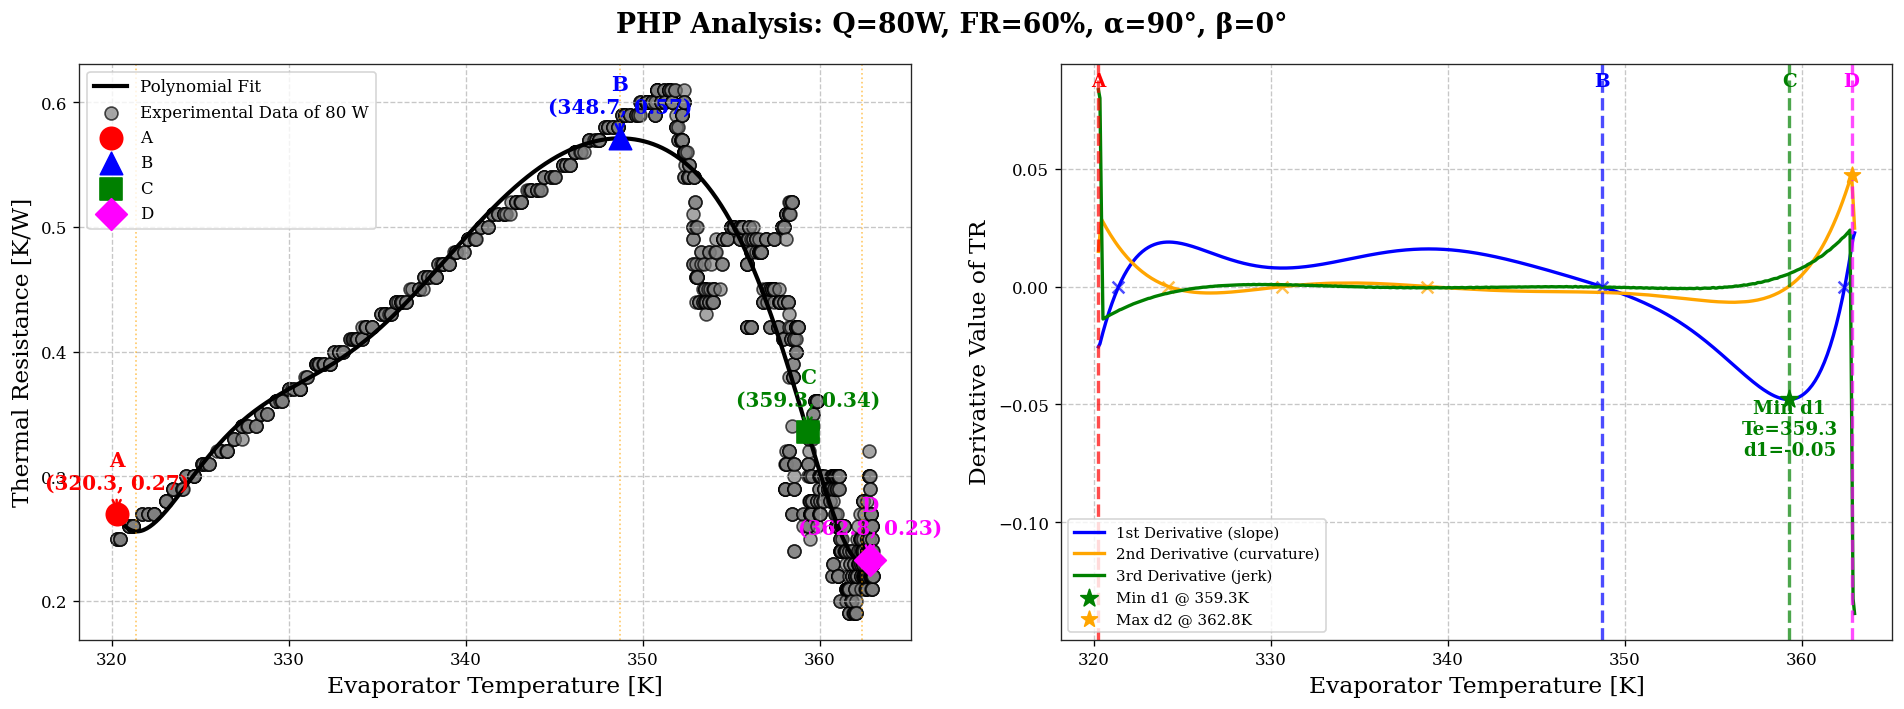

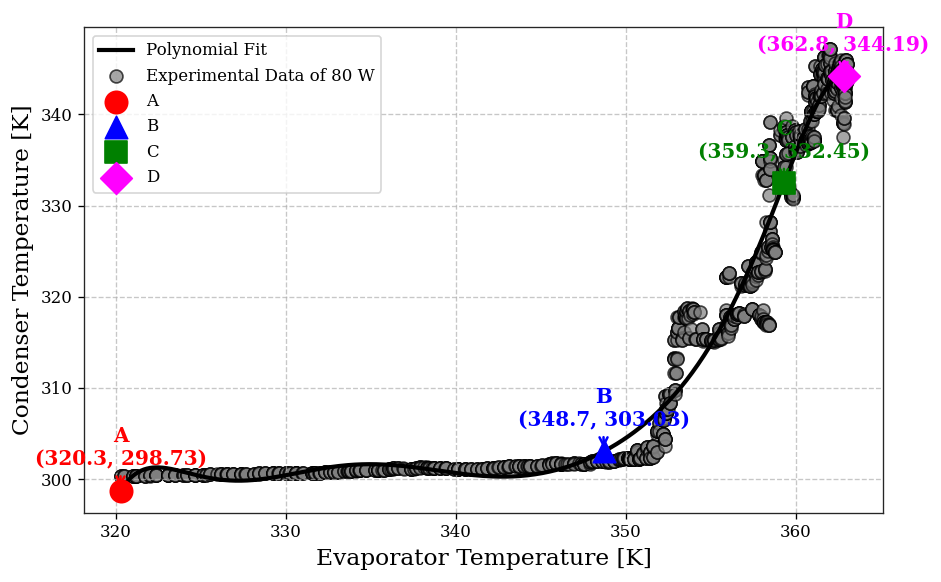

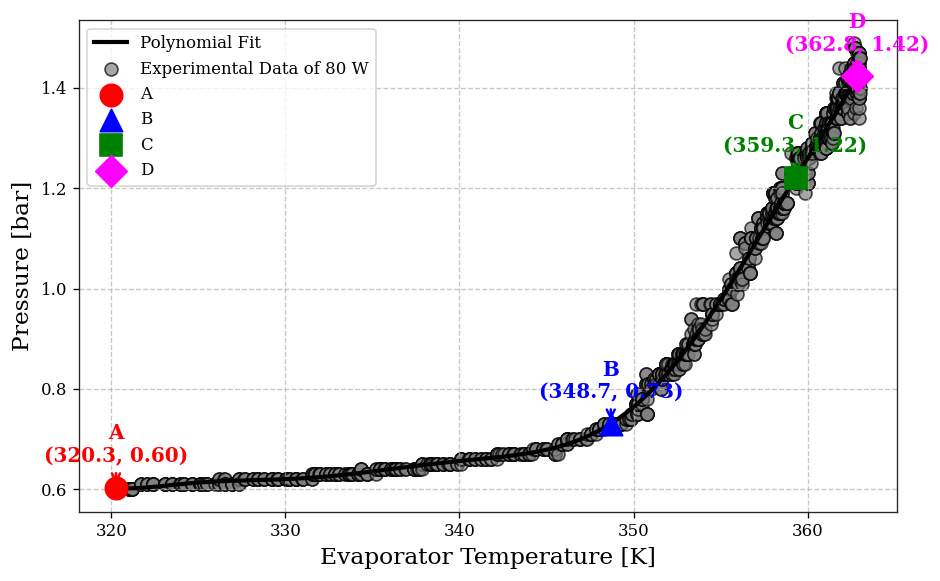

In [43]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 363

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=15,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=15,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

## 100 W

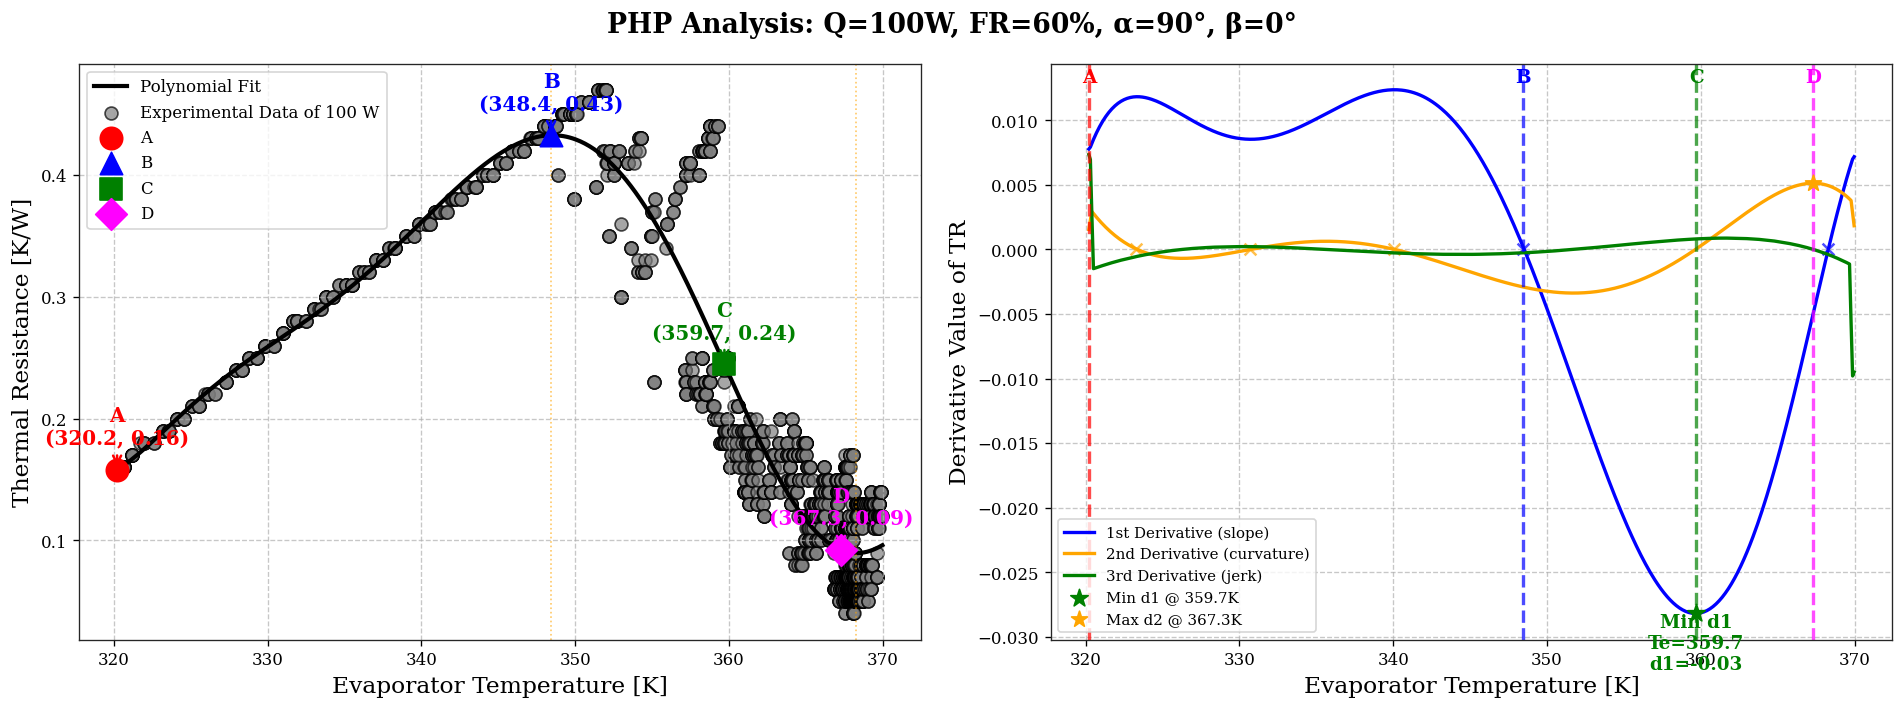

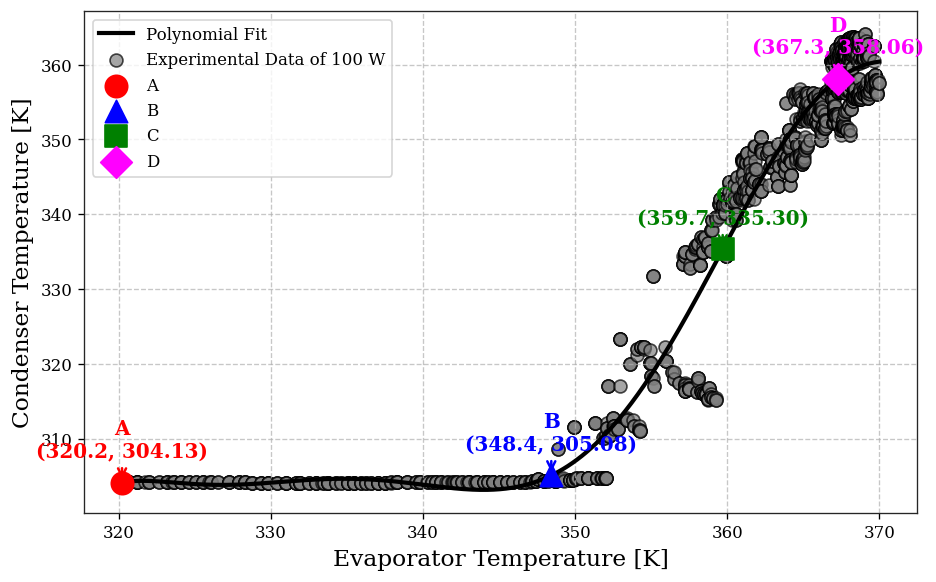

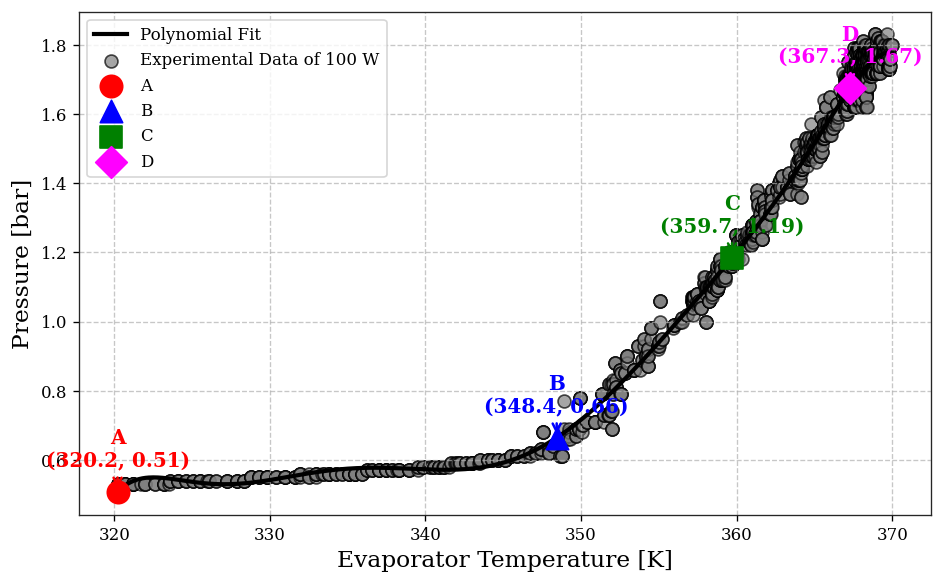

In [24]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 100, 60, 90, 0
te_min, te_max = 320, 370

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg='auto',
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### 100 W - JTAC Special Issue

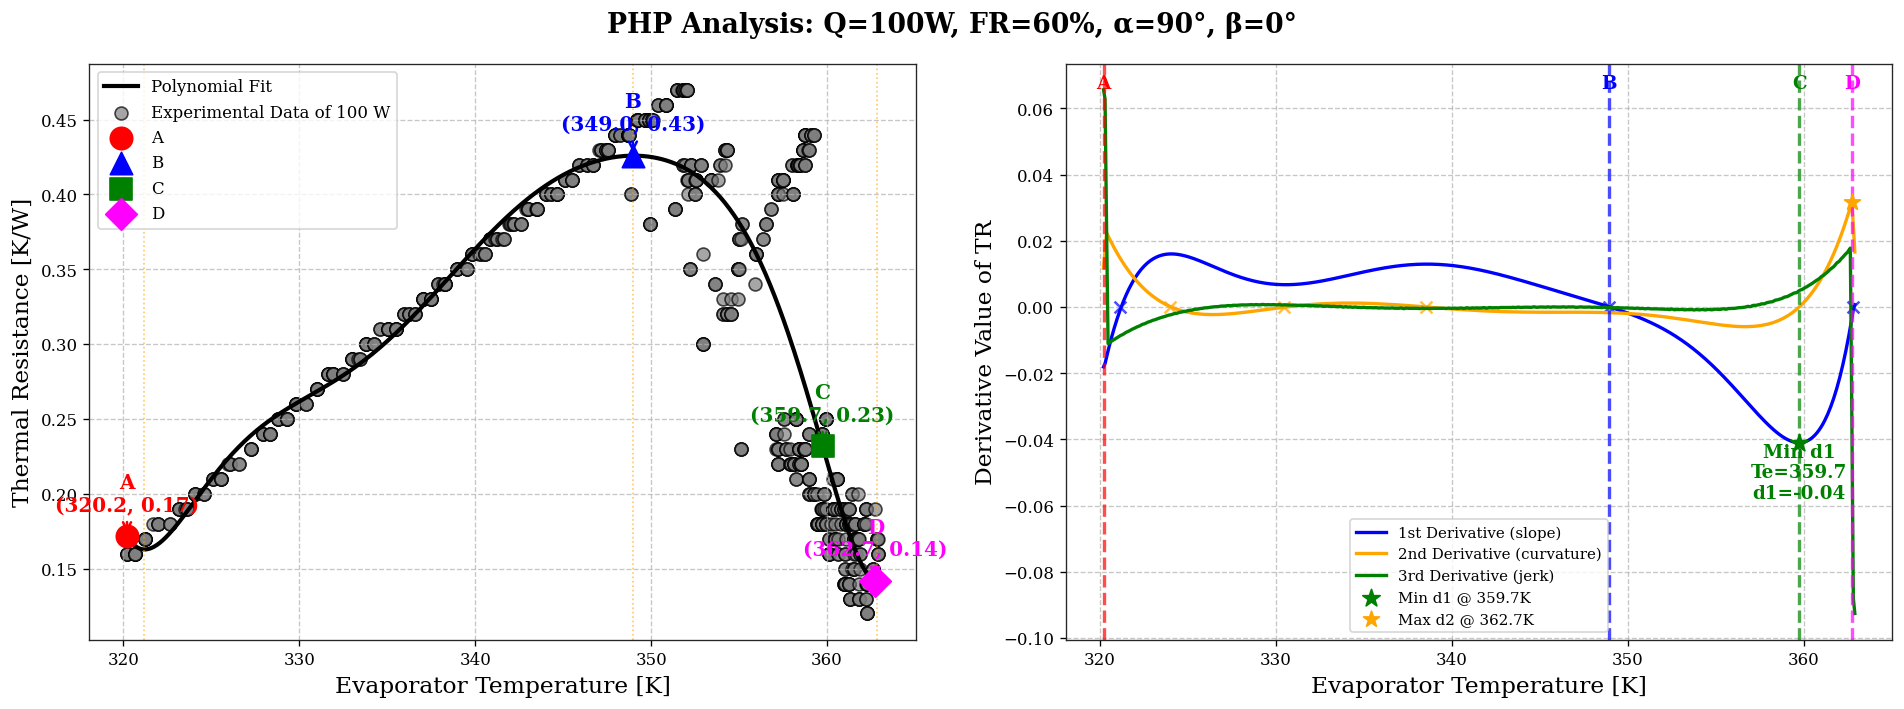

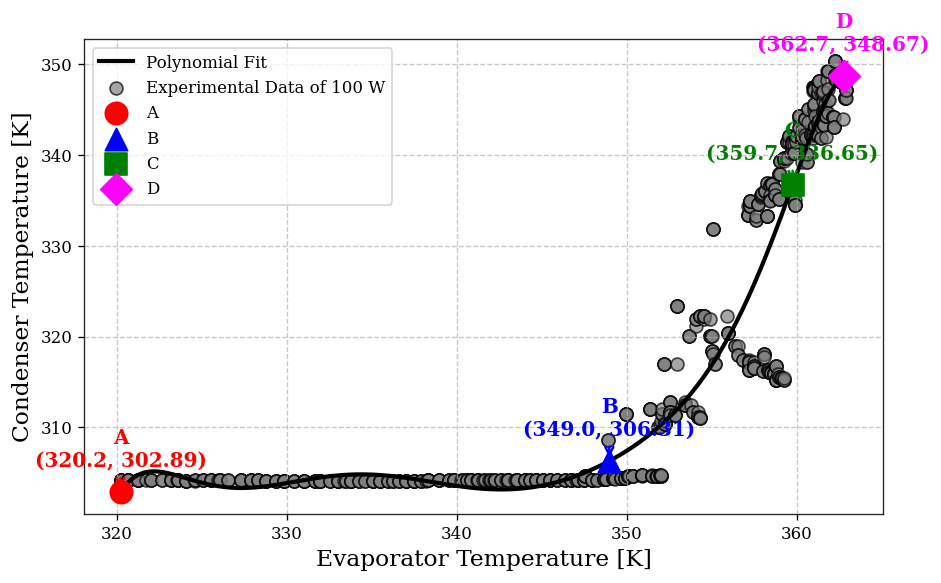

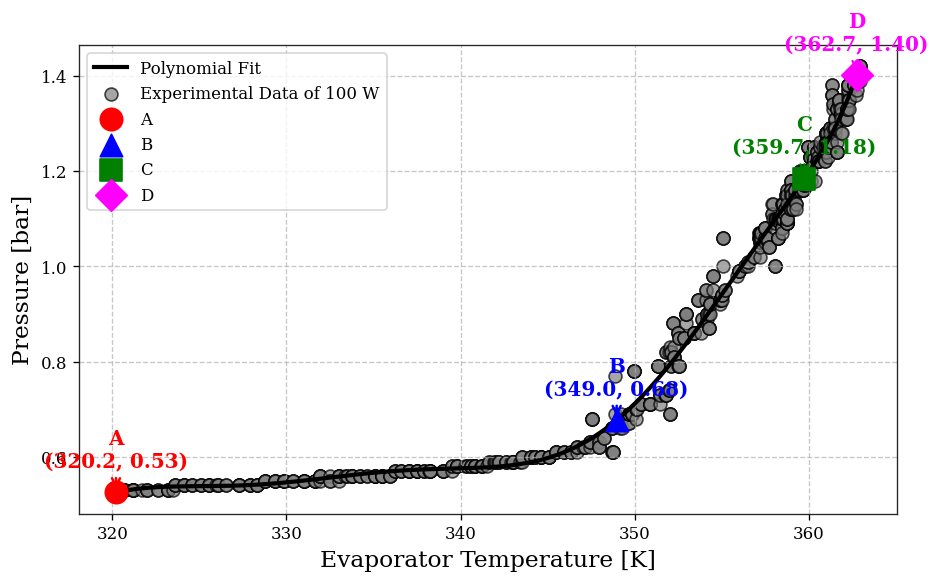

In [25]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 100, 60, 90, 0
te_min, te_max = 320, 363

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=15,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=15,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

## 120 W

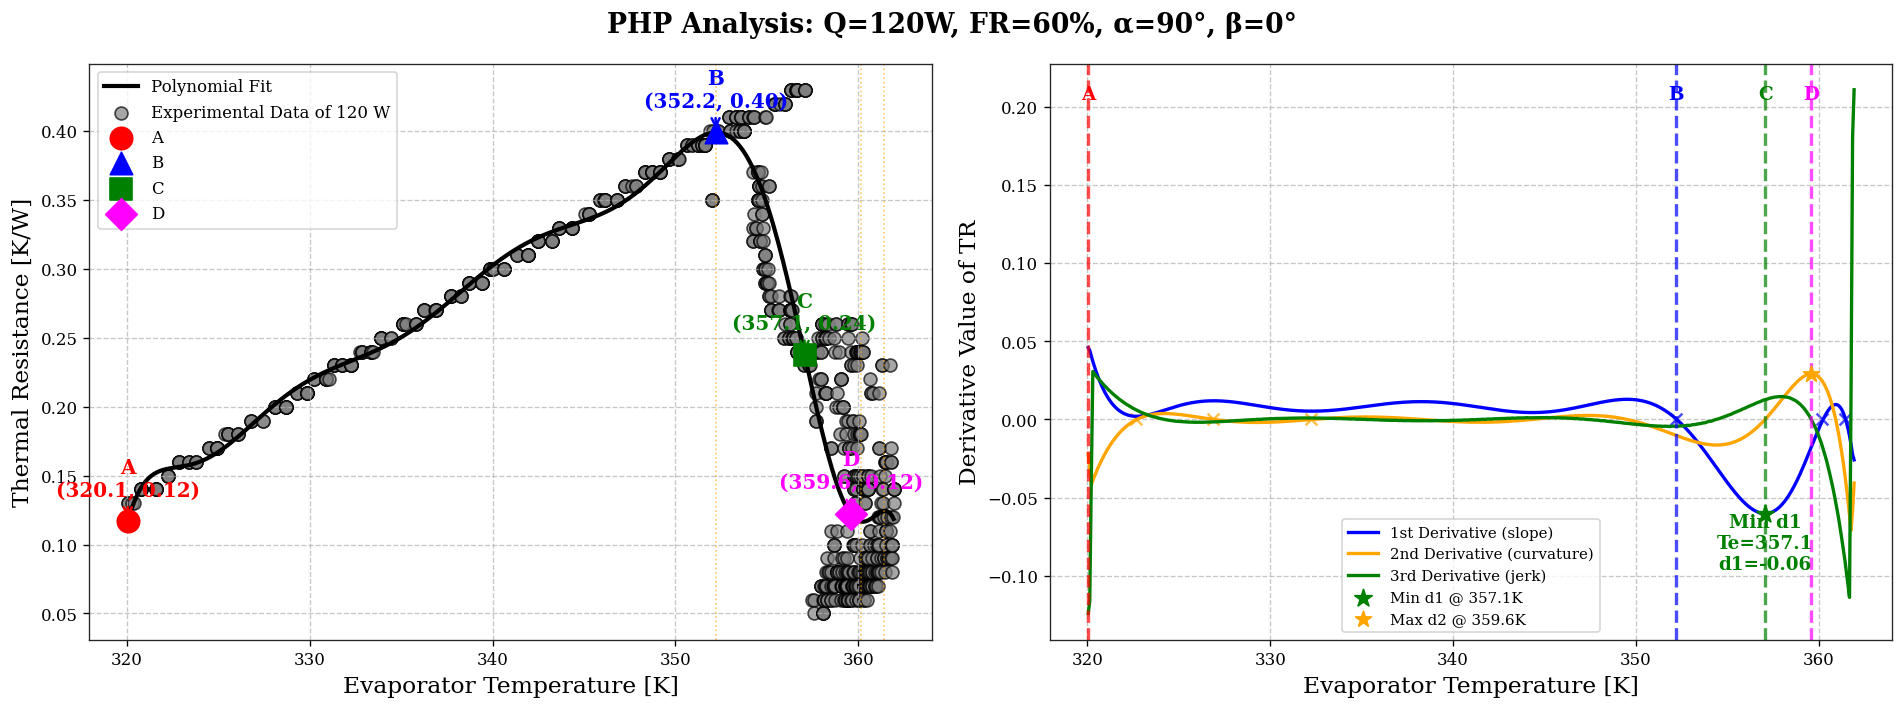

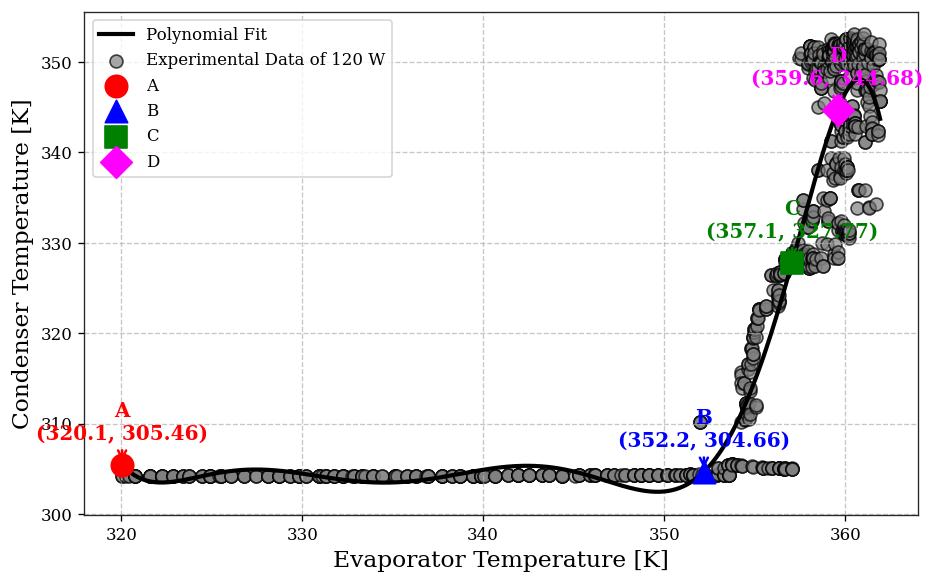

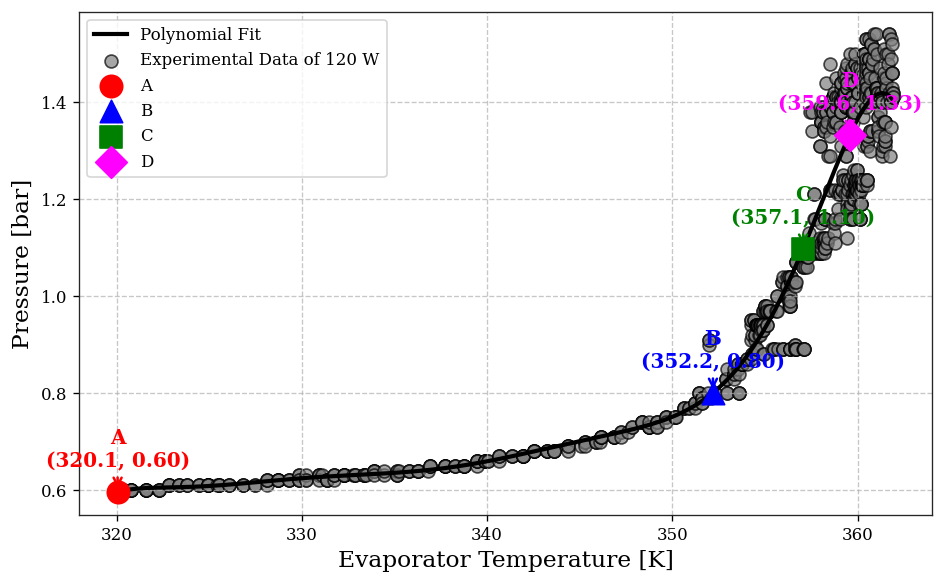

In [26]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 362

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=40,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=15,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

### 120 W - JTAC Special Issue

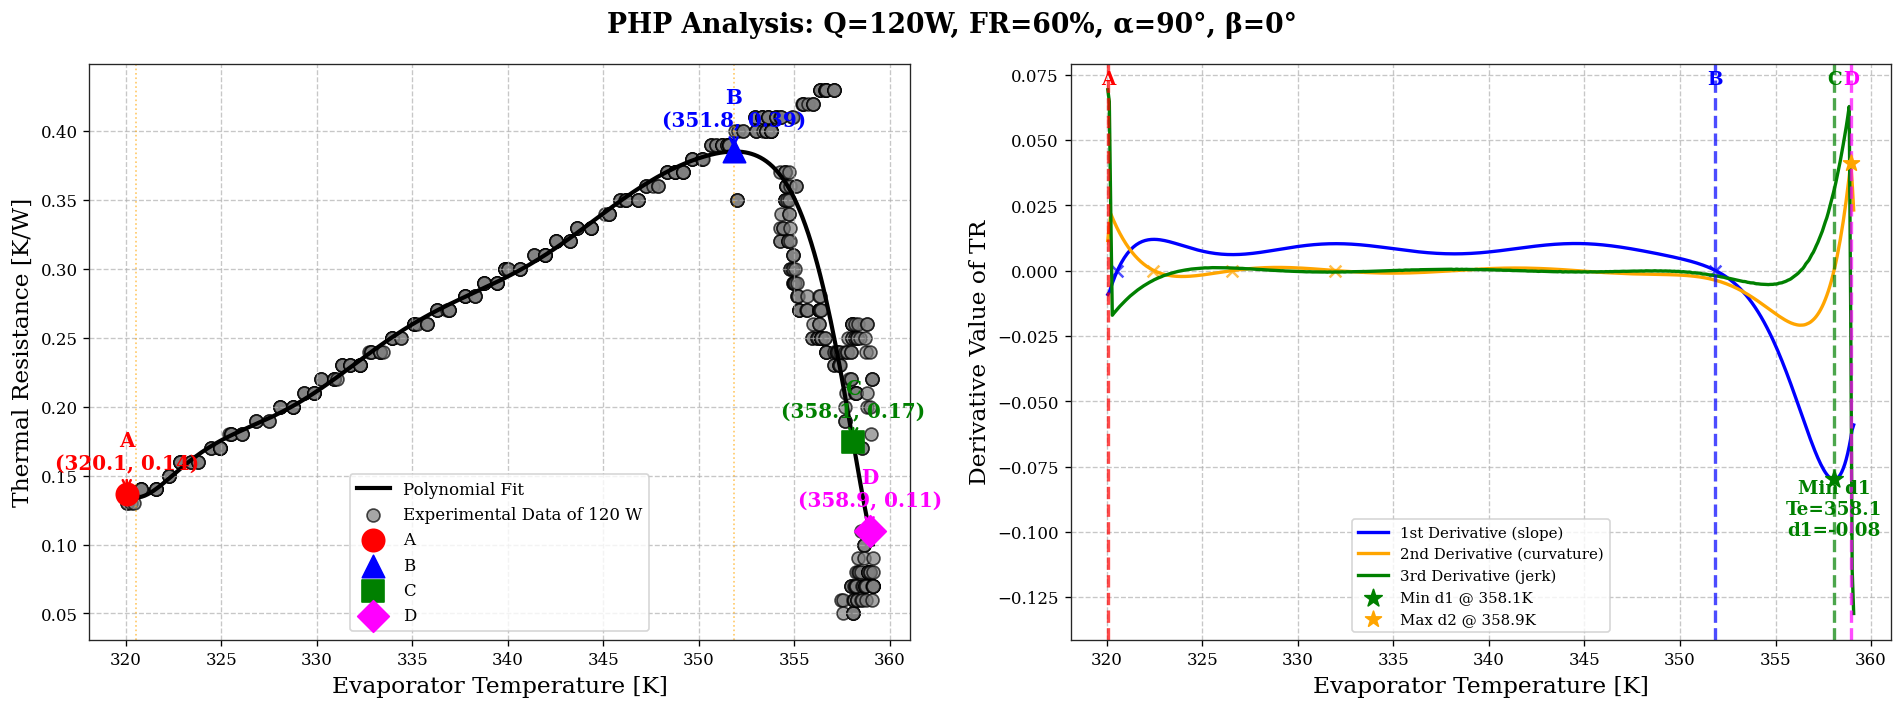

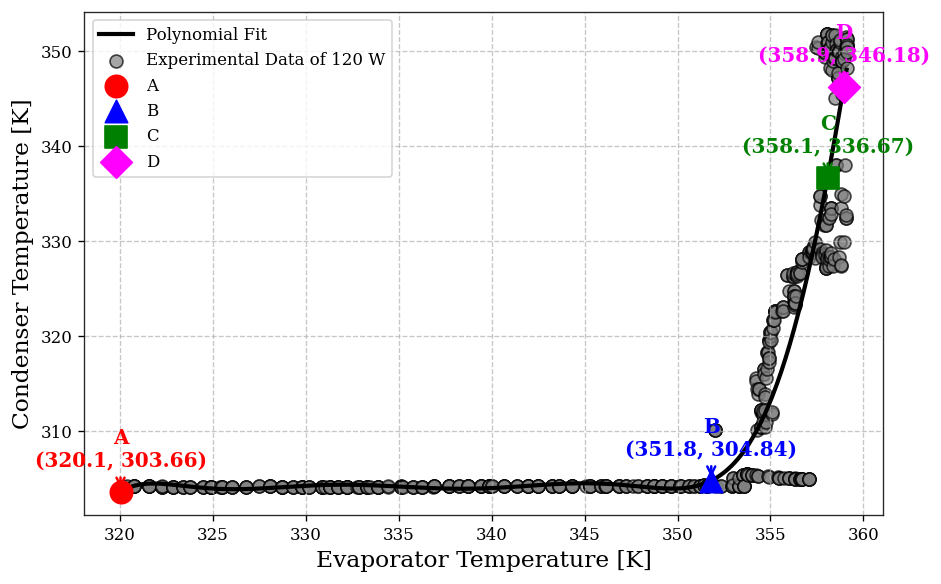

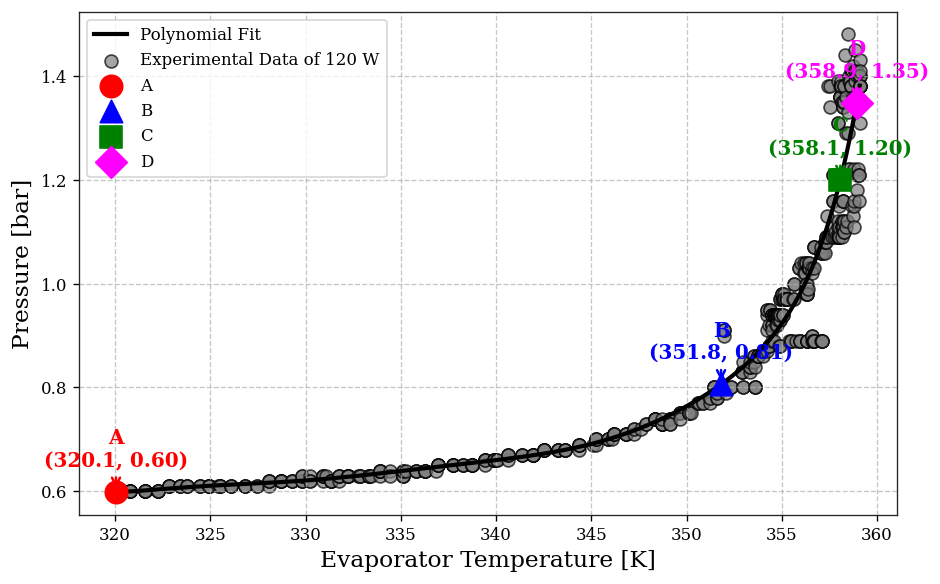

In [35]:
csv_path = 'database.csv'
Q, FR, alpha, beta = 120, 60, 90, 0
te_min, te_max = 320, 359.1

# 1. Analyze TR vs Te and get critical points
results_TR = analyze_TR_vs_Te(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=40,
    outlier_threshold=2.5,
    max_poly_deg=15,
    min_poly_deg=5
)
tr_points = results_TR['points'] if results_TR is not None else None
tr_Te_fine = results_TR['Te_fine'] if results_TR is not None else None

# --- Plot 1: TR vs Te and Derivatives (side by side, with A/B/C/D marked, B and C swapped in display) ---
if results_TR is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'PHP Analysis: Q={Q}W, FR={FR}%, α={alpha}°, β={beta}°', fontsize=16, fontweight='bold')
    colors = {'A': 'red', 'B': 'green', 'C': 'blue', 'D': 'magenta'}
    markers = {'A': 'o', 'B': 's', 'C': '^', 'D': 'D'}
    data = results_TR
    ax1 = axes[0]
    ax1.plot(data['Te_fine'], data['Y_fit'], '-', color='black', linewidth=2.5, label=f'Polynomial Fit')
    ax1.scatter(data['Te_original'], data['Y_original'], color='gray', alpha=0.7, s=60, edgecolor='k', label=f'Experimental Data of {Q} W')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax1.scatter(data['Te_fine'][idx], data['Y_fit'][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f'{plot_label}')
        ax1.annotate(f'{plot_label}\n({data["Te_fine"][idx]:.1f}, {data["Y_fit"][idx]:.2f})', (data['Te_fine'][idx], data['Y_fit'][idx]), textcoords="offset points", xytext=(0,15), ha='center', fontsize=12, color=colors[label], fontweight='bold', arrowprops=dict(arrowstyle='->', color=colors[label], lw=1.5))
    zero_crossings_d1 = _find_zero_crossings(data['d1'])
    zero_crossings_d2 = _find_zero_crossings(data['d2'])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data['Te_fine'][zc], color='orange', linestyle=':', alpha=0.6, linewidth=1)
    
    ax1.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax1.set_ylabel('Thermal Resistance [K/W]', fontsize=14)
    #ax1.set_title('TR vs Te with Critical Points', fontsize=14)
    ax1.legend(fontsize=10, loc='best')
    ax1.grid(True, alpha=0.7)
    ax2 = axes[1]
    ax2.plot(data['Te_fine'], data['d1'], label='1st Derivative (slope)', linewidth=2, color='blue')
    ax2.plot(data['Te_fine'], data['d2'], label='2nd Derivative (curvature)', linewidth=2, color='orange')
    ax2.plot(data['Te_fine'], data['d3'], label='3rd Derivative (jerk)', linewidth=2, color='green')
    for label, idx in data['points'].items():
        # Swap display names for B and C
        if label == 'B':
            plot_label = 'C'
        elif label == 'C':
            plot_label = 'B'
        else:
            plot_label = label
        ax2.axvline(data['Te_fine'][idx], color=colors[label], linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(data['Te_fine'][idx], ax2.get_ylim()[1]*0.9, plot_label, color=colors[label], fontweight='bold', ha='center')
    
    # Mark min d1 and write its value at the corresponding Te
    min_d1_idx = np.argmin(data['d1'])
    ax2.scatter(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], color='green', s=120, marker='*', zorder=10, label=f'Min d1 @ {data["Te_fine"][min_d1_idx]:.1f}K')
    ax2.text(data['Te_fine'][min_d1_idx], data['d1'][min_d1_idx], f'Min d1\nTe={data["Te_fine"][min_d1_idx]:.1f}\nd1={data["d1"][min_d1_idx]:.2f}', color='green', fontsize=11, fontweight='bold', ha='center', va='top')
    max_d1_idx = np.argmax(data['d1'])
    max_d2_idx = np.argmax(data['d2'])
    max_d3_idx = np.argmax(np.abs(data['d3']))
    ax2.scatter(data['Te_fine'][max_d2_idx], data['d2'][max_d2_idx], color='orange', s=100, marker='*', zorder=10, label=f'Max d2 @ {data["Te_fine"][max_d2_idx]:.1f}K')
    for zc in zero_crossings_d1[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='blue', s=50, marker='x', alpha=0.7)
    for zc in zero_crossings_d2[:3]:
        ax2.scatter(data['Te_fine'][zc], 0, color='orange', s=50, marker='x', alpha=0.7)

    ax2.set_xlabel('Evaporator Temperature [K]', fontsize=14)
    ax2.set_ylabel('Derivative Value of TR', fontsize=14)
    #ax2.set_title('Derivatives of TR vs Te', fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

# 2. Analyze and plot Tc vs Te and P vs Te, marking A/B/C/D from TR (B and C swapped in display)
results = analyze_heat_pipe_data(
    csv_path=csv_path,
    Q=Q, FR=FR, alpha=alpha, beta=beta,
    te_min=te_min, te_max=te_max,
    poly_deg=20,
    outlier_threshold=2.5,
    max_poly_deg=5,
    min_poly_deg=5,
    tr_points=tr_points,
    tr_Te_fine=tr_Te_fine
)

# Revision 1 - JTAC Special Issue

## 80 W

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# ==============================
# USER-DEFINED UNCERTAINTIES
# ==============================
UNC_Te = 0.01     # ±1% Temperature
UNC_TR = 0.048    # ±4.8% Thermal Resistance
UNC_P  = 0.019    # ±1.9% Pressure


# ==============================
# POLYNOMIAL DEGREE OPTIMIZATION
# ==============================
def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=5, cv_folds=5):
    degrees = range(min_degree, min(max_degree + 1, len(Te)//3))
    rmse_scores = []

    Te_reshaped = Te.reshape(-1, 1)

    for degree in degrees:
        try:
            pipe = Pipeline([
                ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
                ('lin', LinearRegression())
            ])
            cv_rmse = -cross_val_score(
                pipe, Te_reshaped, Y,
                cv=min(cv_folds, len(Te)//2),
                scoring='neg_root_mean_squared_error'
            ).mean()
            rmse_scores.append(cv_rmse)
        except:
            rmse_scores.append(np.inf)

    best_degree = degrees[np.argmin(rmse_scores)]
    return best_degree


# ==============================
# ZERO-CROSSING FUNCTION
# ==============================
def _find_zero_crossings(arr):
    return np.where(np.diff(np.sign(arr)))[0]


# ==============================
# CRITICAL POINT IDENTIFICATION
# ==============================
def _identify_critical_points(Te_fine, TR_fit, d1, d2, d3):
    A = 0

    # C: dTR/dTe = 0 at max TR
    zc = _find_zero_crossings(d1)
    C = zc[np.argmax(TR_fit[zc])] if len(zc) > 0 else np.argmax(TR_fit)

    # B: min(d1) and d2 ≈ 0 after C
    search_B = slice(C+1, None)
    d1_min = np.argmin(d1[search_B]) + C + 1
    d2_zero = np.argmin(np.abs(d2[search_B])) + C + 1
    B = d1_min if abs(d2[d1_min]) < 0.1 else d2_zero

    # D: max(d2) and d3 ≈ 0 after B
    search_D = slice(B+1, None)
    d2_max = np.argmax(d2[search_D]) + B + 1
    d3_zero = np.argmin(np.abs(d3[search_D])) + B + 1
    D = d2_max if abs(d3[d2_max]) < 0.1 else d3_zero

    return {'A': A, 'C': C, 'B': B, 'D': D}


# ==============================
# TR vs Te ANALYSIS
# ==============================
def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max, poly_deg=15):
    df = pd.read_csv(csv_path)
    df = df[(df['Q[W]']==Q)&(df['FR[%]']==FR)&(df['alpha']==alpha)&(df['beta']==beta)]
    df = df[(df['Te_mean[K]']>=te_min)&(df['Te_mean[K]']<=te_max)]

    df = df[np.abs(zscore(df['TR[K/W]'])) < 2.5]

    Te = df['Te_mean[K]'].values
    TR = df['TR[K/W]'].values

    if len(Te) < 6:
        return None

    coeffs = np.polyfit(Te, TR, deg=poly_deg)
    poly = np.poly1d(coeffs)

    Te_fine = np.linspace(Te.min(), Te.max(), 600)
    TR_fit = poly(Te_fine)

    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)

    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3)

    return {
        'Te_original': Te,
        'TR_original': TR,
        'Te_fine': Te_fine,
        'TR_fit': TR_fit,
        'd1': d1,
        'd2': d2,
        'd3': d3,
        'points': points
    }


# ==============================
# MAIN EXECUTION
# ==============================
csv_path = 'database.csv'
Q, FR, alpha, beta = 80, 60, 90, 0
te_min, te_max = 320, 363

results = analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max)

# ==============================
# PLOTTING WITH ERROR BARS
# ==============================
if results is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16,6))
    ax1, ax2 = axes

    # ---- TR vs Te ----
    ax1.plot(results['Te_fine'], results['TR_fit'], 'k-', lw=2.5, label='Polynomial Fit')
    ax1.scatter(results['Te_original'], results['TR_original'],
                c='gray', alpha=0.6, s=50, label='Experimental Data')

    colors = {'A':'red','B':'green','C':'blue','D':'magenta'}
    markers = {'A':'o','B':'s','C':'^','D':'D'}

    for lbl, idx in results['points'].items():
        Te_val = results['Te_fine'][idx]
        TR_val = results['TR_fit'][idx]

        ax1.errorbar(
            Te_val, TR_val,
            xerr=UNC_Te*Te_val,
            yerr=UNC_TR*TR_val,
            fmt=markers[lbl],
            color=colors[lbl],
            capsize=4,
            elinewidth=1.6,
            markersize=9,
            label=f'{lbl} ± uncertainty'
        )

    ax1.set_xlabel('Evaporator Temperature, Te [K]')
    ax1.set_ylabel('Thermal Resistance, TR [K/W]')
    ax1.legend()
    ax1.grid(alpha=0.7)

    # ---- Derivatives ----
    ax2.plot(results['Te_fine'], results['d1'], label='dTR/dTe', lw=2)
    ax2.plot(results['Te_fine'], results['d2'], label='d²TR/dTe²', lw=2)
    ax2.plot(results['Te_fine'], results['d3'], label='d³TR/dTe³', lw=2)

    for lbl, idx in results['points'].items():
        ax2.axvline(results['Te_fine'][idx], color=colors[lbl], ls='--', lw=1.8)
        ax2.text(results['Te_fine'][idx], ax2.get_ylim()[1]*0.9, lbl,
                 color=colors[lbl], ha='center', fontweight='bold')

    ax2.set_xlabel('Evaporator Temperature, Te [K]')
    ax2.set_ylabel('Derivative Value')
    ax2.legend()
    ax2.grid(alpha=0.7)

    plt.tight_layout()
    plt.show()


In [ ]:
# ...existing code...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")


def optimize_polynomial_degree(Te, Y, max_degree=15, min_degree=3, cv_folds=5):
    Te = np.asarray(Te)
    Y = np.asarray(Y)
    max_deg = min(max_degree, max(min_degree, len(Te) // 2))
    degrees = list(range(min_degree, max_deg + 1))
    scores = []
    X = Te.reshape(-1, 1)
    for d in degrees:
        try:
            pipe = Pipeline([("poly", PolynomialFeatures(degree=d, include_bias=False)),
                             ("lr", LinearRegression())])
            cv = min(cv_folds, max(2, len(Te)//2))
            score = -cross_val_score(pipe, X, Y, cv=cv, scoring="neg_root_mean_squared_error").mean()
        except Exception:
            score = np.inf
        scores.append(score)
    best = degrees[int(np.argmin(scores))]
    return int(best)


def _find_zero_crossings(arr):
    arr = np.asarray(arr)
    idx = np.where(np.diff(np.sign(arr)) != 0)[0]
    return idx


def _identify_critical_points(Te_fine, Y_fit, d1, d2, d3):
    Te_fine = np.asarray(Te_fine)
    Y_fit = np.asarray(Y_fit)
    d1 = np.asarray(d1); d2 = np.asarray(d2); d3 = np.asarray(d3)

    A = 0
    zc = _find_zero_crossings(d1)
    if zc.size > 0:
        C = zc[np.argmax(Y_fit[zc])]
    else:
        C = int(np.argmax(Y_fit))

    # B: min d1 after C or d2 near zero
    if C + 1 < len(d1):
        search = slice(C + 1, None)
        try:
            d1_min = np.argmin(d1[search]) + C + 1
            d2_zero = np.argmin(np.abs(d2[search])) + C + 1
            B = d1_min if abs(d2[d1_min]) < 0.1 else d2_zero
        except Exception:
            B = int(np.argmin(d1))
    else:
        B = int(np.argmin(d1))

    # D: max d2 after B or d3 near zero
    if B + 1 < len(d2):
        search = slice(B + 1, None)
        try:
            d2_max = np.argmax(d2[search]) + B + 1
            d3_zero = np.argmin(np.abs(d3[search])) + B + 1
            D = d2_max if abs(d3[d2_max]) < 0.1 else d3_zero
        except Exception:
            D = int(np.argmax(d2))
    else:
        D = int(np.argmax(d2))

    return {"A": int(A), "B": int(B), "C": int(C), "D": int(D)}


def analyze_TR_vs_Te(csv_path, Q, FR, alpha, beta, te_min, te_max,
                     poly_deg="auto", outlier_threshold=2.5,
                     max_poly_deg=15, min_poly_deg=3, n_fine=500):
    df = pd.read_csv(csv_path)
    df_sel = df[(df["Q[W]"] == Q) & (df["FR[%]"] == FR) & (df["alpha"] == alpha) & (df["beta"] == beta)]
    df_filtered = df_sel[(df_sel["Te_mean[K]"] >= te_min) & (df_sel["Te_mean[K]"] <= te_max)].copy()
    if df_filtered.empty or "TR[K/W]" not in df_filtered.columns:
        print("No TR data for the given conditions/range.")
        return None

    df_clean = df_filtered[np.abs(zscore(df_filtered["TR[K/W]"])) < outlier_threshold]
    df_clean = df_clean.sort_values("Te_mean[K]")
    Te = df_clean["Te_mean[K]"].values
    TR = df_clean["TR[K/W]"].values

    if len(Te) <= min_poly_deg:
        print("Insufficient TR data points for analysis.")
        return None

    if poly_deg == "auto":
        deg = optimize_polynomial_degree(Te, TR, max_poly_deg, min_poly_deg)
    else:
        deg = int(poly_deg)

    coeffs = np.polyfit(Te, TR, deg=deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), n_fine)
    TR_fit = poly(Te_fine)

    d1 = np.gradient(TR_fit, Te_fine)
    d2 = np.gradient(d1, Te_fine)
    d3 = np.gradient(d2, Te_fine)

    points = _identify_critical_points(Te_fine, TR_fit, d1, d2, d3)
    rmse = np.sqrt(mean_squared_error(TR, poly(Te)))
    r2 = 1 - np.sum((TR - poly(Te)) ** 2) / np.sum((TR - np.mean(TR)) ** 2)

    return {
        "Te_original": Te,
        "Y_original": TR,
        "Te_fine": Te_fine,
        "Y_fit": TR_fit,
        "d1": d1,
        "d2": d2,
        "d3": d3,
        "points": points,
        "poly_coeffs": coeffs,
        "poly_degree": deg,
        "rmse": rmse,
        "r2": r2,
        "y_label": "TR",
        "y_unit": "K/W"
    }


def _polyfit_and_plot_with_points(Te, Y, poly_deg, y_label, title, Q, tr_points, tr_Te_fine):
    coeffs = np.polyfit(Te, Y, deg=poly_deg)
    poly = np.poly1d(coeffs)
    Te_fine = np.linspace(Te.min(), Te.max(), 500)
    Y_fit = poly(Te_fine)
    Y_pred = poly(Te)
    rmse = np.sqrt(mean_squared_error(Y, Y_pred))

    plt.figure(figsize=(8, 5))
    plt.plot(Te_fine, Y_fit, "-", color="black", linewidth=2.5, label="Polynomial Fit")
    plt.scatter(Te, Y, color="gray", alpha=0.7, s=60, edgecolor="k", label=f"Experimental Data of {Q} W")
    plt.xlabel("Evaporator Temperature [K]", fontsize=14)
    ylabel = {"Tc_mean [K]": "Condenser Temperature [K]", "P [bar]": "Pressure [bar]"}.get(y_label, y_label)
    plt.ylabel(ylabel, fontsize=14)

    # Add TR critical points (swap display names B<->C)
    if tr_points is not None and tr_Te_fine is not None:
        colors = {"A": "red", "B": "green", "C": "blue", "D": "magenta"}
        markers = {"A": "o", "B": "s", "C": "^", "D": "D"}
        for lbl, idx in tr_points.items():
            if lbl == "B":
                display = "C"
            elif lbl == "C":
                display = "B"
            else:
                display = lbl
            if idx is not None and 0 <= idx < len(Te_fine):
                plt.scatter(Te_fine[idx], Y_fit[idx], color=colors[lbl], s=180, marker=markers[lbl], zorder=5, label=display)
                plt.annotate(f"{display}\n({Te_fine[idx]:.1f}, {Y_fit[idx]:.2f})",
                             (Te_fine[idx], Y_fit[idx]),
                             textcoords="offset points", xytext=(0, 15), ha="center",
                             fontsize=11, color=colors[lbl], fontweight="bold",
                             arrowprops=dict(arrowstyle="->", color=colors[lbl], lw=1.2))

    plt.legend(fontsize=10, loc="best")
    plt.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

    return {"Te": Te, "Y": Y, "Te_fine": Te_fine, "Y_fit": Y_fit, "poly_coeffs": coeffs, "poly_degree": poly_deg, "rmse": rmse}


def analyze_heat_pipe_data(csv_path, Q, FR, alpha, beta, te_min, te_max,
                           poly_deg="auto", outlier_threshold=2.5, max_poly_deg=15,
                           min_poly_deg=3, tr_points=None, tr_Te_fine=None):
    df = pd.read_csv(csv_path)
    df_sel = df[(df["Q[W]"] == Q) & (df["FR[%]"] == FR) & (df["alpha"] == alpha) & (df["beta"] == beta)]
    df_filtered = df_sel[(df_sel["Te_mean[K]"] >= te_min) & (df_sel["Te_mean[K]"] <= te_max)].copy()
    if df_filtered.empty:
        print("No data found for given condition and range.")
        return None

    results = {}
    # Tc vs Te
    if "Tc_mean[K]" in df_filtered.columns:
        df_tc = df_filtered[np.abs(zscore(df_filtered["Tc_mean[K]"])) < outlier_threshold]
        if len(df_tc) > min_poly_deg:
            Te_tc = df_tc.sort_values("Te_mean[K]")["Te_mean[K]"].values
            Tc_tc = df_tc.sort_values("Te_mean[K]")["Tc_mean[K]"].values
            if poly_deg == "auto":
                deg = optimize_polynomial_degree(Te_tc, Tc_tc, max_poly_deg, min_poly_deg)
            else:
                deg = int(poly_deg)
            results["tc"] = _polyfit_and_plot_with_points(Te_tc, Tc_tc, deg, "Tc_mean [K]", "Tc vs Te", Q, tr_points, tr_Te_fine)
        else:
            print("Insufficient Tc data points for analysis.")

    # P vs Te
    if "P[bar]" in df_filtered.columns:
        df_p = df_filtered[np.abs(zscore(df_filtered["P[bar]"])) < outlier_threshold]
        if len(df_p) > min_poly_deg:
            Te_p = df_p.sort_values("Te_mean[K]")["Te_mean[K]"].values
            P_p = df_p.sort_values("Te_mean[K]")["P[bar]"].values
            if poly_deg == "auto":
                deg = optimize_polynomial_degree(Te_p, P_p, max_poly_deg, min_poly_deg)
            else:
                deg = int(poly_deg)
            results["p"] = _polyfit_and_plot_with_points(Te_p, P_p, deg, "P [bar]", "P vs Te", Q, tr_points, tr_Te_fine)
        else:
            print("Insufficient P data points for analysis.")

    return results


def plot_tr_and_derivatives_with_residuals(results_TR, Q, swap_BC_display=True):
    data = results_TR
    colors = {"A": "red", "B": "green", "C": "blue", "D": "magenta"}
    markers = {"A": "o", "B": "s", "C": "^", "D": "D"}

    # Main TR and derivatives subplot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"PHP Analysis: Q={Q}W", fontsize=16, fontweight="bold")
    ax1, ax2 = axes

    ax1.plot(data["Te_fine"], data["Y_fit"], "-", color="black", linewidth=2.5, label="Polynomial Fit")
    ax1.scatter(data["Te_original"], data["Y_original"], color="gray", alpha=0.7, s=60, edgecolor="k", label=f"Experimental Data of {Q} W")

    for label, idx in data["points"].items():
        if swap_BC_display:
            if label == "B":
                plot_label = "C"
            elif label == "C":
                plot_label = "B"
            else:
                plot_label = label
        else:
            plot_label = label
        if idx is not None and 0 <= idx < len(data["Te_fine"]):
            ax1.scatter(data["Te_fine"][idx], data["Y_fit"][idx], color=colors[label], s=180, marker=markers[label], zorder=5, label=f"{plot_label}")
            ax1.annotate(f"{plot_label}\n({data['Te_fine'][idx]:.1f}, {data['Y_fit'][idx]:.2f})",
                         (data["Te_fine"][idx], data["Y_fit"][idx]),
                         textcoords="offset points", xytext=(0, 15), ha="center",
                         fontsize=11, color=colors[label], fontweight="bold",
                         arrowprops=dict(arrowstyle="->", color=colors[label], lw=1.2))

    zero_crossings_d1 = _find_zero_crossings(data["d1"])
    for zc in zero_crossings_d1[:3]:
        ax1.axvline(data["Te_fine"][zc], color="orange", linestyle=":", alpha=0.6, linewidth=1)

    ax1.set_xlabel("Evaporator Temperature [K]", fontsize=14)
    ax1.set_ylabel("Thermal Resistance [K/W]", fontsize=14)
    ax1.legend(fontsize=10, loc="best")
    ax1.grid(True, alpha=0.7)

    # Derivatives plot
    ax2.plot(data["Te_fine"], data["d1"], label="1st Derivative (slope)", linewidth=2, color="blue")
    ax2.plot(data["Te_fine"], data["d2"], label="2nd Derivative (curvature)", linewidth=2, color="orange")
    ax2.plot(data["Te_fine"], data["d3"], label="3rd Derivative (jerk)", linewidth=2, color="green")
    ax2.axhline(0, color="black", linestyle="-", alpha=0.3, linewidth=1)
    for label, idx in data["points"].items():
        if swap_BC_display:
            if label == "B":
                plot_label = "C"
            elif label == "C":
                plot_label = "B"
            else:
                plot_label = label
        else:
            plot_label = label
        ax2.axvline(data["Te_fine"][idx], color=colors[label], linestyle="--", linewidth=2, alpha=0.7)
        ax2.text(data["Te_fine"][idx], ax2.get_ylim()[1] * 0.9, plot_label, color=colors[label], fontweight="bold", ha="center")

    min_d1_idx = np.argmin(data["d1"])
    ax2.scatter(data["Te_fine"][min_d1_idx], data["d1"][min_d1_idx], color="green", s=120, marker="*", zorder=10, label=f"Min d1 @ {data['Te_fine'][min_d1_idx]:.1f}K")
    ax2.text(data["Te_fine"][min_d1_idx], data["d1"][min_d1_idx], f"Min d1\nTe={data['Te_fine'][min_d1_idx]:.1f}\nd1={data['d1'][min_d1_idx]:.2f}", color="green", fontsize=11, fontweight="bold", ha="center", va="top")

    ax2.set_xlabel("Evaporator Temperature [K]", fontsize=14)
    ax2.set_ylabel("Derivative Value of TR", fontsize=14)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.7)
    plt.tight_layout()
    plt.show()

    # Separate publication-ready residuals plot (TR on x, residual on y)
    coeffs = data.get("poly_coeffs", None)
    Te_orig = data.get("Te_original", None)
    TR_orig = data.get("Y_original", None)
    if coeffs is not None and Te_orig is not None and TR_orig is not None:
        poly = np.poly1d(coeffs)
        TR_pred_at_Te = poly(Te_orig)
        residuals = TR_orig - TR_pred_at_Te  # measured - fit
        mean_r = np.mean(residuals)
        std_r = np.std(residuals)
        rmse_r = np.sqrt(np.mean(residuals ** 2))

        figr, axr = plt.subplots(figsize=(8, 5))
        axr.scatter(TR_orig, residuals, c="black", edgecolor="k", s=70, alpha=0.9, label="Residuals")
        axr.axhline(0, color="red", linestyle="--", linewidth=1.5, alpha=0.9)
        # annotate stats in upper left
        stats = f"Mean = {mean_r:.4f}\nStd = {std_r:.4f}\nRMSE = {rmse_r:.4f}"
        axr.text(0.02, 0.98, stats, transform=axr.transAxes, fontsize=10, verticalalignment="top",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.85))

        axr.set_xlabel("Thermal Resistance, TR [K/W]", fontsize=14)
        axr.set_ylabel("Residuals (Measured - Fit) [K/W]", fontsize=14)
        axr.set_title("Residuals of TR Polynomial Fit", fontsize=14, fontweight="bold")
        axr.grid(True, alpha=0.7)
        axr.legend(fontsize=10, loc="best")
        plt.tight_layout()
        plt.show()


# =========================
# Example / Main Execution
# =========================
if __name__ == "__main__":
    csv_path = "database.csv"
    Q, FR, alpha, beta = 80, 60, 90, 0
    te_min, te_max = 320, 363

    # 1. Analyze TR vs Te and get critical points
    results_TR = analyze_TR_vs_Te(csv_path=csv_path,
                                  Q=Q, FR=FR, alpha=alpha, beta=beta,
                                  te_min=te_min, te_max=te_max,
                                  poly_deg=15,
                                  outlier_threshold=2.5,
                                  max_poly_deg=15,
                                  min_poly_deg=5)
    tr_points = results_TR["points"] if results_TR is not None else None
    tr_Te_fine = results_TR["Te_fine"] if results_TR is not None else None

    # Plot TR, derivatives and residuals (residuals separate publication-ready)
    if results_TR is not None:
        plot_tr_and_derivatives_with_residuals(results_TR, Q, swap_BC_display=True)

    # 2. Analyze and plot Tc vs Te and P vs Te (marking A/B/C/D from TR)
    results = analyze_heat_pipe_data(csv_path=csv_path,
                                     Q=Q, FR=FR, alpha=alpha, beta=beta,
                                     te_min=te_min, te_max=te_max,
                                     poly_deg="auto",
                                     outlier_threshold=2.5,
                                     max_poly_deg=15,
                                     min_poly_deg=5,
                                     tr_points=tr_points,
                                     tr_Te_fine=tr_Te_fine)
# ...existing code...

# Residual Plot

## Trial plots

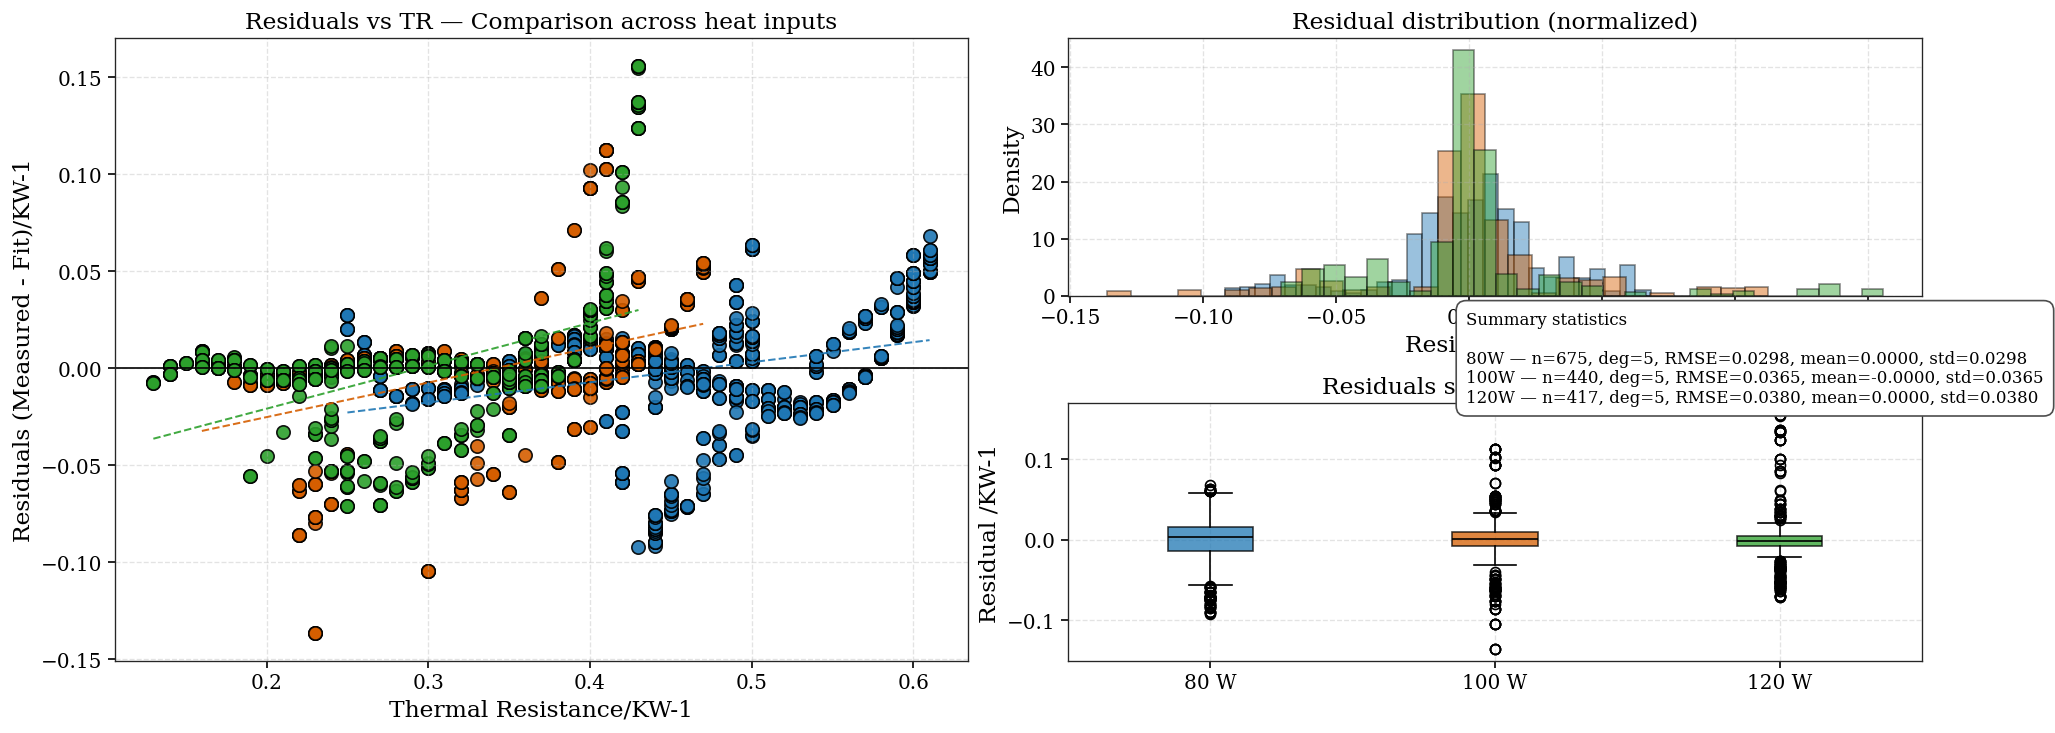

In [ ]:
# ...existing code...
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Publication-quality matplotlib defaults (no seaborn dependency)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5,
    "axes.edgecolor": "0.15"
})


def optimize_polynomial_degree(Te, Y, min_degree=2, max_degree=15, cv_folds=5):
    Te = np.asarray(Te).reshape(-1, 1)
    n = len(Te)
    max_deg = min(max_degree, max(min_degree, max(2, n // 2)))
    degrees = list(range(min_degree, max_deg + 1))
    best_deg = min_degree
    best_score = np.inf
    for d in degrees:
        try:
            pipe = Pipeline([('poly', PolynomialFeatures(degree=d, include_bias=False)),
                             ('lr', LinearRegression())])
            cv = max(2, min(cv_folds, max(2, n // 2)))
            score = -cross_val_score(pipe, Te, Y, cv=cv, scoring='neg_root_mean_squared_error').mean()
            if score < best_score:
                best_score = score
                best_deg = d
        except Exception:
            continue
    return int(best_deg)


def fit_poly_and_residuals(Te, TR, degree='auto', min_deg=2, max_deg=15):
    Te = np.asarray(Te)
    TR = np.asarray(TR)
    if degree == 'auto':
        deg = optimize_polynomial_degree(Te, TR, min_degree=min_deg, max_degree=max_deg)
    else:
        deg = int(degree)
    coeffs = np.polyfit(Te, TR, deg=deg)
    poly = np.poly1d(coeffs)
    TR_pred = poly(Te)
    residuals = TR - TR_pred
    stats = {
        'deg': deg,
        'rmse': float(np.sqrt(mean_squared_error(TR, TR_pred))),
        'mean_res': float(np.mean(residuals)),
        'std_res': float(np.std(residuals)),
        'med_res': float(np.median(residuals)),
        'n': int(len(TR))
    }
    return {'Te': Te, 'TR': TR, 'TR_pred': TR_pred, 'residuals': residuals, 'coeffs': coeffs, 'stats': stats}


def load_filtered_data(csv_path, Q, FR=60, alpha=90, beta=0, te_min=None, te_max=None, outlier_z=2.5):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    df = df[(df.get('Q[W]') == Q) & (df.get('FR[%]') == FR) & (df.get('alpha') == alpha) & (df.get('beta') == beta)]
    if te_min is not None:
        df = df[df['Te_mean[K]'] >= te_min]
    if te_max is not None:
        df = df[df['Te_mean[K]'] <= te_max]
    if df.empty or 'TR[K/W]' not in df.columns:
        return None
    df = df[np.abs(zscore(df['TR[K/W]'])) < outlier_z]
    df = df.sort_values('Te_mean[K]')
    return df[['Te_mean[K]', 'TR[K/W]']].rename(columns={'Te_mean[K]': 'Te', 'TR[K/W]': 'TR'})


def publication_compare_residuals(csv_path,
                                  Q_list=(80, 100, 120),
                                  FR=60, alpha=90, beta=0,
                                  te_range=None,
                                  deg_choice='auto', min_deg=2, max_deg=15,
                                  save_path=None):
    colors = {80: '#1f77b4', 100: '#d55e00', 120: '#2ca02c'}
    results = {}
    for Q in Q_list:
        df = load_filtered_data(csv_path, Q, FR=FR, alpha=alpha, beta=beta,
                                te_min=(te_range[0] if te_range else None),
                                te_max=(te_range[1] if te_range else None))
        if df is None or df.empty:
            continue
        res = fit_poly_and_residuals(df['Te'].values, df['TR'].values,
                                     degree=deg_choice, min_deg=min_deg, max_deg=max_deg)
        results[Q] = {'df': df, **res}

    if not results:
        raise RuntimeError("No data found for requested Q conditions.")

    fig = plt.figure(constrained_layout=True, figsize=(16, 6))
    gs = fig.add_gridspec(2, 4)

    ax_scatter = fig.add_subplot(gs[:, :2])
    ax_hist = fig.add_subplot(gs[0, 2:])
    ax_box = fig.add_subplot(gs[1, 2:])

    for Q, dat in results.items():
        TR = dat['TR']
        resids = dat['residuals']
        ax_scatter.scatter(TR, resids, label=f'{Q} W (n={dat["stats"]["n"]}, deg={dat["stats"]["deg"]})',
                           color=colors.get(Q, '#444444'), alpha=0.9, edgecolor='k', s=64)
        if len(TR) > 1:
            try:
                m, b = np.polyfit(TR, resids, 1)
                x_line = np.linspace(np.min(TR), np.max(TR), 120)
                ax_scatter.plot(x_line, m * x_line + b, color=colors.get(Q), linestyle='--', linewidth=1.2, alpha=0.9)
            except Exception:
                pass

    ax_scatter.axhline(0, color='k', linewidth=1.0, linestyle='-')
    ax_scatter.set_xlabel('Thermal Resistance/KW-1')
    ax_scatter.set_ylabel('Residuals (Measured - Fit)/KW-1')
    ax_scatter.set_title('Residuals vs TR — Comparison across heat inputs')

    bins = 28
    for Q, dat in results.items():
        ax_hist.hist(dat['residuals'], bins=bins, alpha=0.45, label=f'{Q} W', color=colors.get(Q),
                     density=True, edgecolor='k')
    ax_hist.set_xlabel('Residual /KW-1')
    ax_hist.set_ylabel('Density')
    ax_hist.set_title('Residual distribution (normalized)')

    sorted_Q = sorted(results.keys())
    data_for_box = [results[q]['residuals'] for q in sorted_Q]
    box = ax_box.boxplot(data_for_box, labels=[f'{q} W' for q in sorted_Q], patch_artist=True, medianprops=dict(color='black'))
    for patch, q in zip(box['boxes'], sorted_Q):
        patch.set_facecolor(colors.get(q, '#888888'))
        patch.set_alpha(0.75)
    ax_box.set_ylabel('Residual /KW-1')
    ax_box.set_title('Residual summary (boxplot)')

    

    stats_lines = []
    for q in sorted_Q:
        s = results[q]['stats']
        stats_lines.append(f"{q}W — n={s['n']}, deg={s['deg']}, RMSE={s['rmse']:.4f}, mean={s['mean_res']:.4f}, std={s['std_res']:.4f}")
    fig.text(0.76, 0.45, "Summary statistics\n\n" + "\n".join(stats_lines),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="0.3"))

    for ax in (ax_scatter, ax_hist, ax_box):
        ax.tick_params(direction='out', length=4, width=1)

    if save_path:
        d = os.path.dirname(save_path)
        if d:
            os.makedirs(d, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    return results


if __name__ == "__main__":
    # adjust path to your local CSV as required
    csv_path = "database.csv"
    Q_list = [80, 100, 120]
    te_range = (320, 358)  # None to use full available range
    try:
        publication_compare_residuals(csv_path=csv_path,
                                      Q_list=Q_list,
                                      FR=60, alpha=90, beta=0,
                                      te_range=te_range,
                                      deg_choice='auto',
                                      min_deg=5, max_deg=5,
                                      #save_path=os.path.join(os.path.dirname(__file__), "figures", "residuals_comparison_Q80_100_120.png"))
                                      save_path=None)
    except Exception as e:
        print("Error:", e)
# ...existing code...

Error: cannot access local variable 'ax' where it is not associated with a value


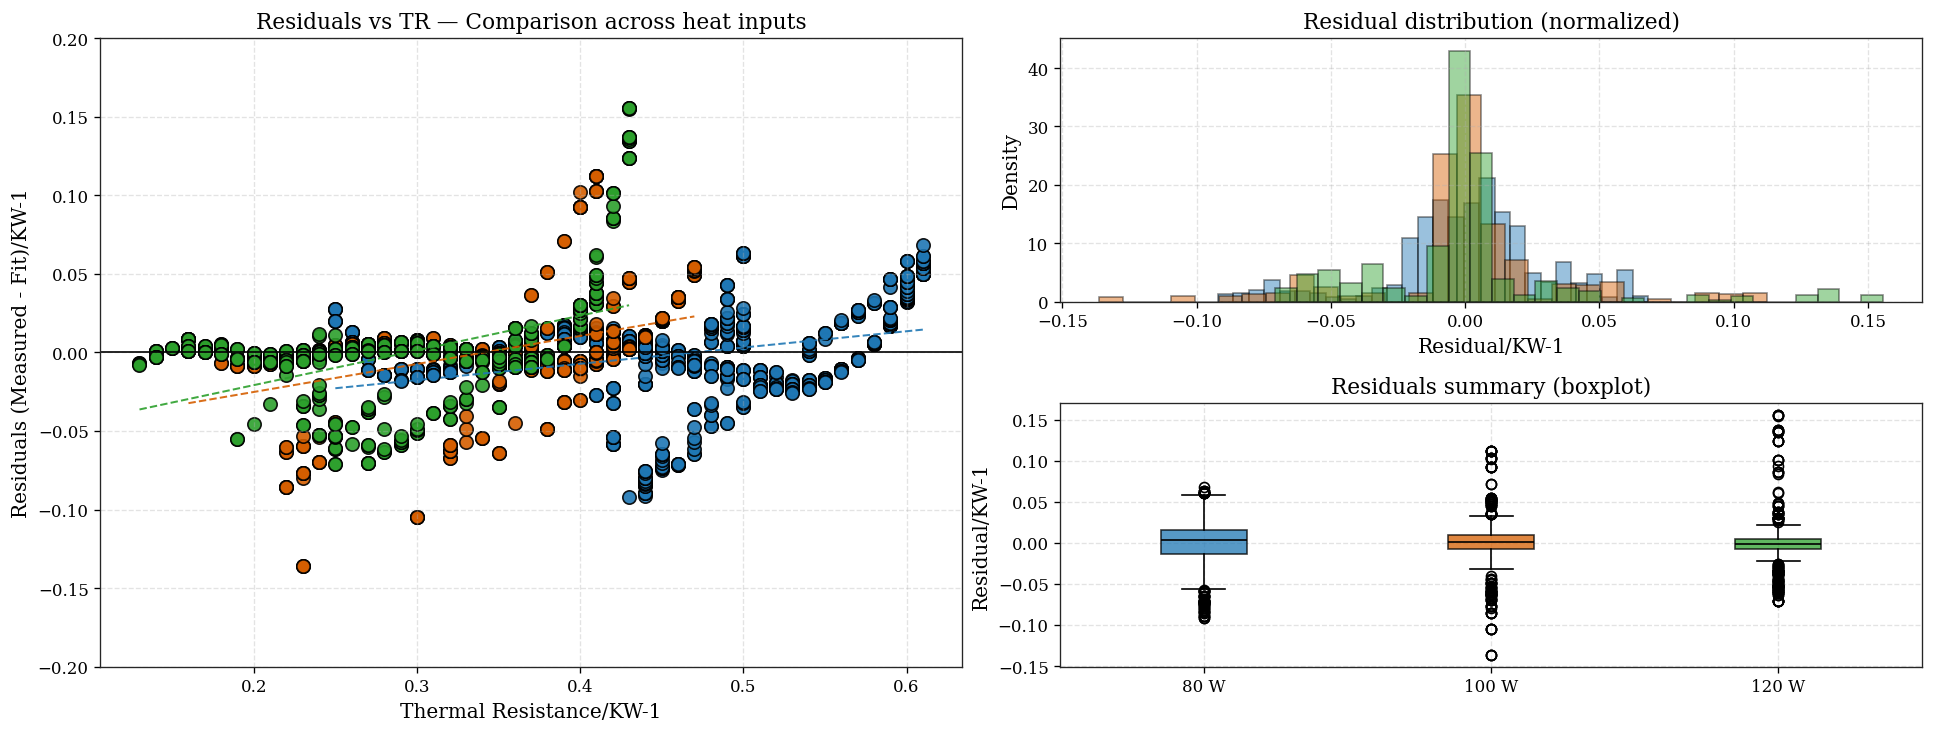

In [ ]:
# ...existing code...
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Publication-quality matplotlib defaults (no seaborn dependency)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5,
    "axes.edgecolor": "0.15"
})


def optimize_polynomial_degree(Te, Y, min_degree=2, max_degree=15, cv_folds=5):
    Te = np.asarray(Te).reshape(-1, 1)
    n = len(Te)
    max_deg = min(max_degree, max(min_degree, max(2, n // 2)))
    degrees = list(range(min_degree, max_deg + 1))
    best_deg = min_degree
    best_score = np.inf
    for d in degrees:
        try:
            pipe = Pipeline([('poly', PolynomialFeatures(degree=d, include_bias=False)),
                             ('lr', LinearRegression())])
            cv = max(2, min(cv_folds, max(2, n // 2)))
            score = -cross_val_score(pipe, Te, Y, cv=cv, scoring='neg_root_mean_squared_error').mean()
            if score < best_score:
                best_score = score
                best_deg = d
        except Exception:
            continue
    return int(best_deg)


def fit_poly_and_residuals(Te, TR, degree='auto', min_deg=2, max_deg=15):
    Te = np.asarray(Te)
    TR = np.asarray(TR)
    if degree == 'auto':
        deg = optimize_polynomial_degree(Te, TR, min_degree=min_deg, max_degree=max_deg)
    else:
        deg = int(degree)
    coeffs = np.polyfit(Te, TR, deg=deg)
    poly = np.poly1d(coeffs)
    TR_pred = poly(Te)
    residuals = TR - TR_pred
    stats = {
        'deg': deg,
        'rmse': float(np.sqrt(mean_squared_error(TR, TR_pred))),
        'mean_res': float(np.mean(residuals)),
        'std_res': float(np.std(residuals)),
        'med_res': float(np.median(residuals)),
        'n': int(len(TR))
    }
    return {'Te': Te, 'TR': TR, 'TR_pred': TR_pred, 'residuals': residuals, 'coeffs': coeffs, 'stats': stats}


def load_filtered_data(csv_path, Q, FR=60, alpha=90, beta=0, te_min=None, te_max=None, outlier_z=2.5):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    df = df[(df.get('Q[W]') == Q) & (df.get('FR[%]') == FR) & (df.get('alpha') == alpha) & (df.get('beta') == beta)]
    if te_min is not None:
        df = df[df['Te_mean[K]'] >= te_min]
    if te_max is not None:
        df = df[df['Te_mean[K]'] <= te_max]
    if df.empty or 'TR[K/W]' not in df.columns:
        return None
    df = df[np.abs(zscore(df['TR[K/W]'])) < outlier_z]
    df = df.sort_values('Te_mean[K]')
    return df[['Te_mean[K]', 'TR[K/W]']].rename(columns={'Te_mean[K]': 'Te', 'TR[K/W]': 'TR'})


def publication_compare_residuals(csv_path,
                                  Q_list=(80, 100, 120),
                                  FR=60, alpha=90, beta=0,
                                  te_range=None,
                                  deg_choice='auto', min_deg=2, max_deg=15,
                                  save_path=None):
    colors = {80: '#1f77b4', 100: '#d55e00', 120: '#2ca02c'}
    results = {}
    for Q in Q_list:
        df = load_filtered_data(csv_path, Q, FR=FR, alpha=alpha, beta=beta,
                                te_min=(te_range[0] if te_range else None),
                                te_max=(te_range[1] if te_range else None))
        if df is None or df.empty:
            continue
        res = fit_poly_and_residuals(df['Te'].values, df['TR'].values,
                                     degree=deg_choice, min_deg=min_deg, max_deg=max_deg)
        results[Q] = {'df': df, **res}

    if not results:
        raise RuntimeError("No data found for requested Q conditions.")

    fig = plt.figure(constrained_layout=True, figsize=(16, 6))
    gs = fig.add_gridspec(2, 4)

    ax_scatter = fig.add_subplot(gs[:, :2])
    ax_hist = fig.add_subplot(gs[0, 2:])
    ax_box = fig.add_subplot(gs[1, 2:])

    for Q, dat in results.items():
        TR = dat['TR']
        resids = dat['residuals']
        ax_scatter.scatter(TR, resids, label=f'{Q} W (n={dat["stats"]["n"]}, deg={dat["stats"]["deg"]})',
                           color=colors.get(Q, '#444444'), alpha=0.9, edgecolor='k', s=64)
        if len(TR) > 1:
            try:
                m, b = np.polyfit(TR, resids, 1)
                x_line = np.linspace(np.min(TR), np.max(TR), 120)
                ax_scatter.plot(x_line, m * x_line + b, color=colors.get(Q), linestyle='--', linewidth=1.2, alpha=0.9)
            except Exception:
                pass

    ax_scatter.axhline(0, color='k', linewidth=1.0, linestyle='-')
    ax_scatter.set_xlabel('Thermal Resistance/KW-1')
    ax_scatter.set_ylabel('Residuals (Measured - Fit)/KW-1')
    ax_scatter.set_title('Residuals vs TR — Comparison across heat inputs')

    # force residual y-range to [-0.20, 0.20]
    ax_scatter.set_ylim(-0.20, 0.20)


    bins = 28
    for Q, dat in results.items():
        ax_hist.hist(dat['residuals'], bins=bins, alpha=0.45, label=f'{Q} W', color=colors.get(Q),
                     density=True, edgecolor='k')
    ax_hist.set_xlabel('Residual/KW-1')
    ax_hist.set_ylabel('Density')
    ax_hist.set_title('Residual distribution (normalized)')

    sorted_Q = sorted(results.keys())
    data_for_box = [results[q]['residuals'] for q in sorted_Q]
    box = ax_box.boxplot(data_for_box, labels=[f'{q} W' for q in sorted_Q], patch_artist=True, medianprops=dict(color='black'))
    for patch, q in zip(box['boxes'], sorted_Q):
        patch.set_facecolor(colors.get(q, '#888888'))
        patch.set_alpha(0.75)
    ax_box.set_ylabel('Residual/KW-1')
    ax_box.set_title('Residual summary (boxplot)')

    # force residual y-range to [-20, 20]
    ax.set_ylim(-20, 20)

    stats_lines = []
    for q in sorted_Q:
        s = results[q]['stats']
        stats_lines.append(f"{q}W — n={s['n']}, deg={s['deg']}, RMSE={s['rmse']:.4f}, mean={s['mean_res']:.4f}, std={s['std_res']:.4f}")
    
    # Remove or comment out the summary textbox to exclude it from the plot:
    #fig.text(0.76, 0.45, "Summary statistics\n\n" + "\n".join(stats_lines),
    #         fontsize=10, bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="0.3"))

    for ax in (ax_scatter, ax_hist, ax_box):
        ax.tick_params(direction='out', length=4, width=1)

    if save_path:
        d = os.path.dirname(save_path)
        if d:
            os.makedirs(d, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    return results


if __name__ == "__main__":
    # adjust path to your local CSV as required
    csv_path = "database.csv"
    Q_list = [80, 100, 120]
    te_range = (320, 358)  # None to use full available range
    try:
        publication_compare_residuals(csv_path=csv_path,
                                      Q_list=Q_list,
                                      FR=60, alpha=90, beta=0,
                                      te_range=te_range,
                                      deg_choice='auto',
                                      min_deg=5, max_deg=5,
                                      #save_path=os.path.join(os.path.dirname(__file__), "figures", "residuals_comparison_Q80_100_120.png"))
                                      save_path=None)
    except Exception as e:
        print("Error:", e)
# ...existing code...

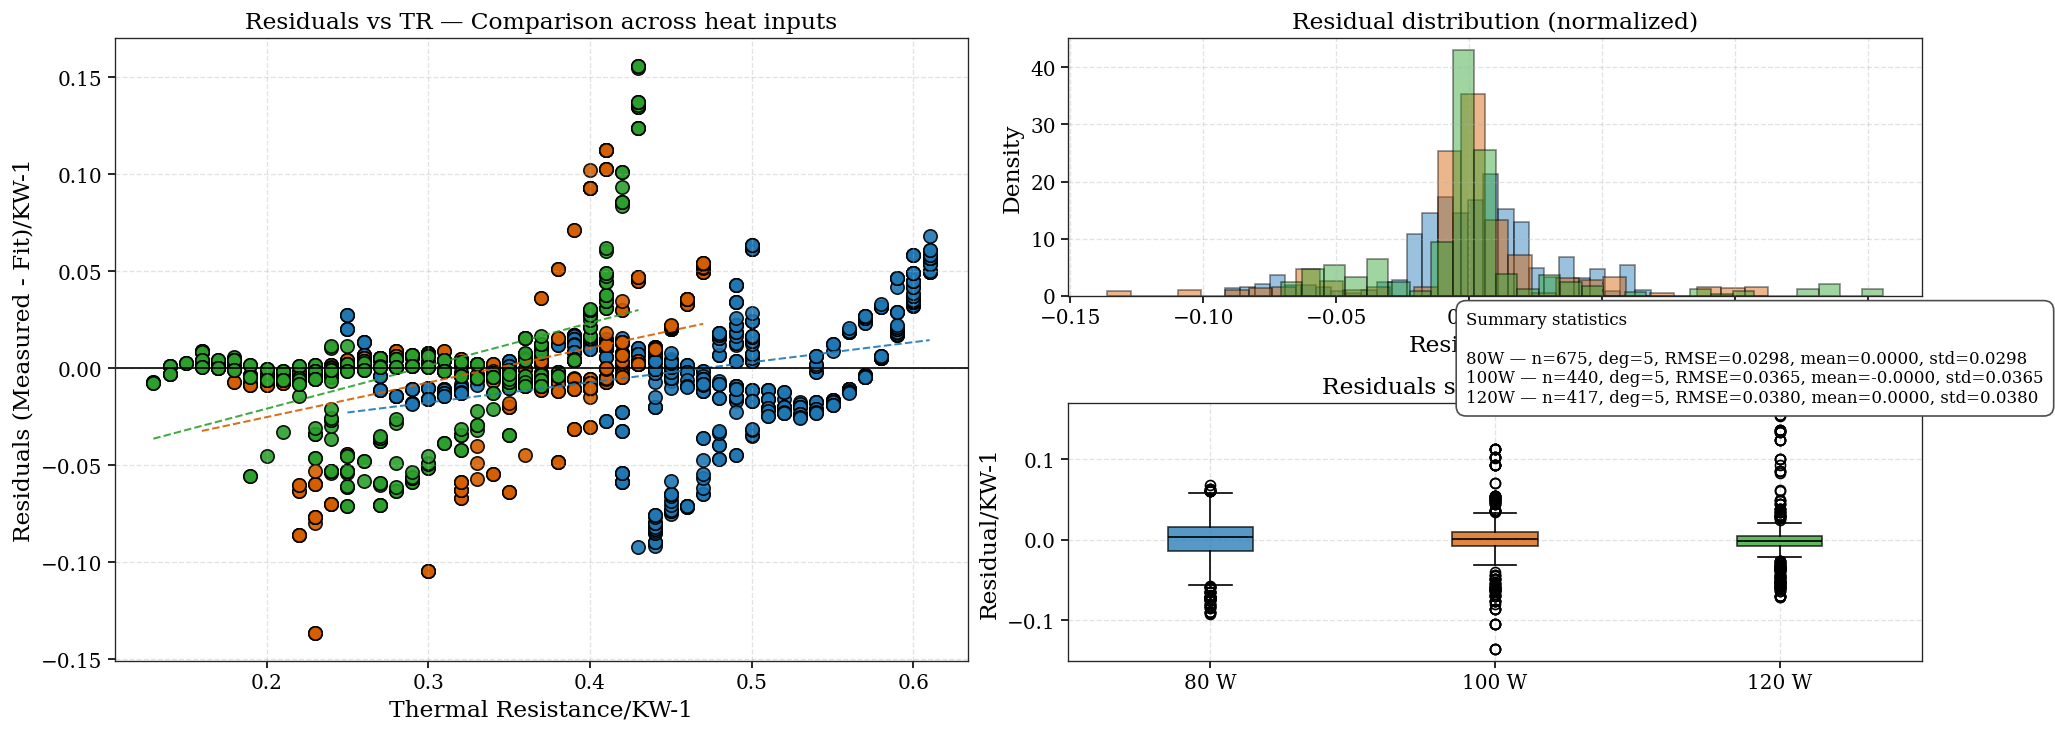

In [ ]:
# ...existing code...
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Publication-quality matplotlib defaults (no seaborn dependency)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5,
    "axes.edgecolor": "0.15"
})


def optimize_polynomial_degree(Te, Y, min_degree=2, max_degree=15, cv_folds=5):
    Te = np.asarray(Te).reshape(-1, 1)
    n = len(Te)
    max_deg = min(max_degree, max(min_degree, max(2, n // 2)))
    degrees = list(range(min_degree, max_deg + 1))
    best_deg = min_degree
    best_score = np.inf
    for d in degrees:
        try:
            pipe = Pipeline([('poly', PolynomialFeatures(degree=d, include_bias=False)),
                             ('lr', LinearRegression())])
            cv = max(2, min(cv_folds, max(2, n // 2)))
            score = -cross_val_score(pipe, Te, Y, cv=cv, scoring='neg_root_mean_squared_error').mean()
            if score < best_score:
                best_score = score
                best_deg = d
        except Exception:
            continue
    return int(best_deg)


def fit_poly_and_residuals(Te, TR, degree='auto', min_deg=2, max_deg=15):
    Te = np.asarray(Te)
    TR = np.asarray(TR)
    if degree == 'auto':
        deg = optimize_polynomial_degree(Te, TR, min_degree=min_deg, max_degree=max_deg)
    else:
        deg = int(degree)
    coeffs = np.polyfit(Te, TR, deg=deg)
    poly = np.poly1d(coeffs)
    TR_pred = poly(Te)
    residuals = TR - TR_pred
    stats = {
        'deg': deg,
        'rmse': float(np.sqrt(mean_squared_error(TR, TR_pred))),
        'mean_res': float(np.mean(residuals)),
        'std_res': float(np.std(residuals)),
        'med_res': float(np.median(residuals)),
        'n': int(len(TR))
    }
    return {'Te': Te, 'TR': TR, 'TR_pred': TR_pred, 'residuals': residuals, 'coeffs': coeffs, 'stats': stats}


def load_filtered_data(csv_path, Q, FR=60, alpha=90, beta=0, te_min=None, te_max=None, outlier_z=2.5):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    df = df[(df.get('Q[W]') == Q) & (df.get('FR[%]') == FR) & (df.get('alpha') == alpha) & (df.get('beta') == beta)]
    if te_min is not None:
        df = df[df['Te_mean[K]'] >= te_min]
    if te_max is not None:
        df = df[df['Te_mean[K]'] <= te_max]
    if df.empty or 'TR[K/W]' not in df.columns:
        return None
    df = df[np.abs(zscore(df['TR[K/W]'])) < outlier_z]
    df = df.sort_values('Te_mean[K]')
    return df[['Te_mean[K]', 'TR[K/W]']].rename(columns={'Te_mean[K]': 'Te', 'TR[K/W]': 'TR'})


def publication_compare_residuals(csv_path,
                                  Q_list=(80, 100, 120),
                                  FR=60, alpha=90, beta=0,
                                  te_range=None,
                                  deg_choice='auto', min_deg=2, max_deg=15,
                                  save_path=None):
    colors = {80: '#1f77b4', 100: '#d55e00', 120: '#2ca02c'}
    results = {}
    for Q in Q_list:
        df = load_filtered_data(csv_path, Q, FR=FR, alpha=alpha, beta=beta,
                                te_min=(te_range[0] if te_range else None),
                                te_max=(te_range[1] if te_range else None))
        if df is None or df.empty:
            continue
        res = fit_poly_and_residuals(df['Te'].values, df['TR'].values,
                                     degree=deg_choice, min_deg=min_deg, max_deg=max_deg)
        results[Q] = {'df': df, **res}

    if not results:
        raise RuntimeError("No data found for requested Q conditions.")

    fig = plt.figure(constrained_layout=True, figsize=(16, 6))
    gs = fig.add_gridspec(2, 4)

    ax_scatter = fig.add_subplot(gs[:, :2])
    ax_hist = fig.add_subplot(gs[0, 2:])
    ax_box = fig.add_subplot(gs[1, 2:])

    for Q, dat in results.items():
        TR = dat['TR']
        resids = dat['residuals']
        ax_scatter.scatter(TR, resids, label=f'{Q} W (n={dat["stats"]["n"]}, deg={dat["stats"]["deg"]})',
                           color=colors.get(Q, '#444444'), alpha=0.9, edgecolor='k', s=64)
        if len(TR) > 1:
            try:
                m, b = np.polyfit(TR, resids, 1)
                x_line = np.linspace(np.min(TR), np.max(TR), 120)
                ax_scatter.plot(x_line, m * x_line + b, color=colors.get(Q), linestyle='--', linewidth=1.2, alpha=0.9)
            except Exception:
                pass

    ax_scatter.axhline(0, color='k', linewidth=1.0, linestyle='-')
    ax_scatter.set_xlabel('Thermal Resistance/KW-1')
    ax_scatter.set_ylabel('Residuals (Measured - Fit)/KW-1')
    ax_scatter.set_title('Residuals vs TR — Comparison across heat inputs')

    bins = 28
    for Q, dat in results.items():
        ax_hist.hist(dat['residuals'], bins=bins, alpha=0.45, label=f'{Q} W', color=colors.get(Q),
                     density=True, edgecolor='k')
    ax_hist.set_xlabel('Residual /KW-1')
    ax_hist.set_ylabel('Density')
    ax_hist.set_title('Residual distribution (normalized)')

    sorted_Q = sorted(results.keys())
    data_for_box = [results[q]['residuals'] for q in sorted_Q]
    box = ax_box.boxplot(data_for_box, labels=[f'{q} W' for q in sorted_Q], patch_artist=True, medianprops=dict(color='black'))
    for patch, q in zip(box['boxes'], sorted_Q):
        patch.set_facecolor(colors.get(q, '#888888'))
        patch.set_alpha(0.75)
    ax_box.set_ylabel('Residual /KW-1')
    ax_box.set_title('Residual summary (boxplot)')

    

    stats_lines = []
    for q in sorted_Q:
        s = results[q]['stats']
        stats_lines.append(f"{q}W — n={s['n']}, deg={s['deg']}, RMSE={s['rmse']:.4f}, mean={s['mean_res']:.4f}, std={s['std_res']:.4f}")
    fig.text(0.76, 0.45, "Summary statistics\n\n" + "\n".join(stats_lines),
             fontsize=10, bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="0.3"))

    for ax in (ax_scatter, ax_hist, ax_box):
        ax.tick_params(direction='out', length=4, width=1)

    if save_path:
        d = os.path.dirname(save_path)
        if d:
            os.makedirs(d, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    return results


if __name__ == "__main__":
    # adjust path to your local CSV as required
    csv_path = "database.csv"
    Q_list = [80, 100, 120]
    te_range = (320, 358)  # None to use full available range
    try:
        publication_compare_residuals(csv_path=csv_path,
                                      Q_list=Q_list,
                                      FR=60, alpha=90, beta=0,
                                      te_range=te_range,
                                      deg_choice='auto',
                                      min_deg=5, max_deg=5,
                                      #save_path=os.path.join(os.path.dirname(__file__), "figures", "residuals_comparison_Q80_100_120.png"))
                                      save_path=None)
    except Exception as e:
        print("Error:", e)
# ...existing code...

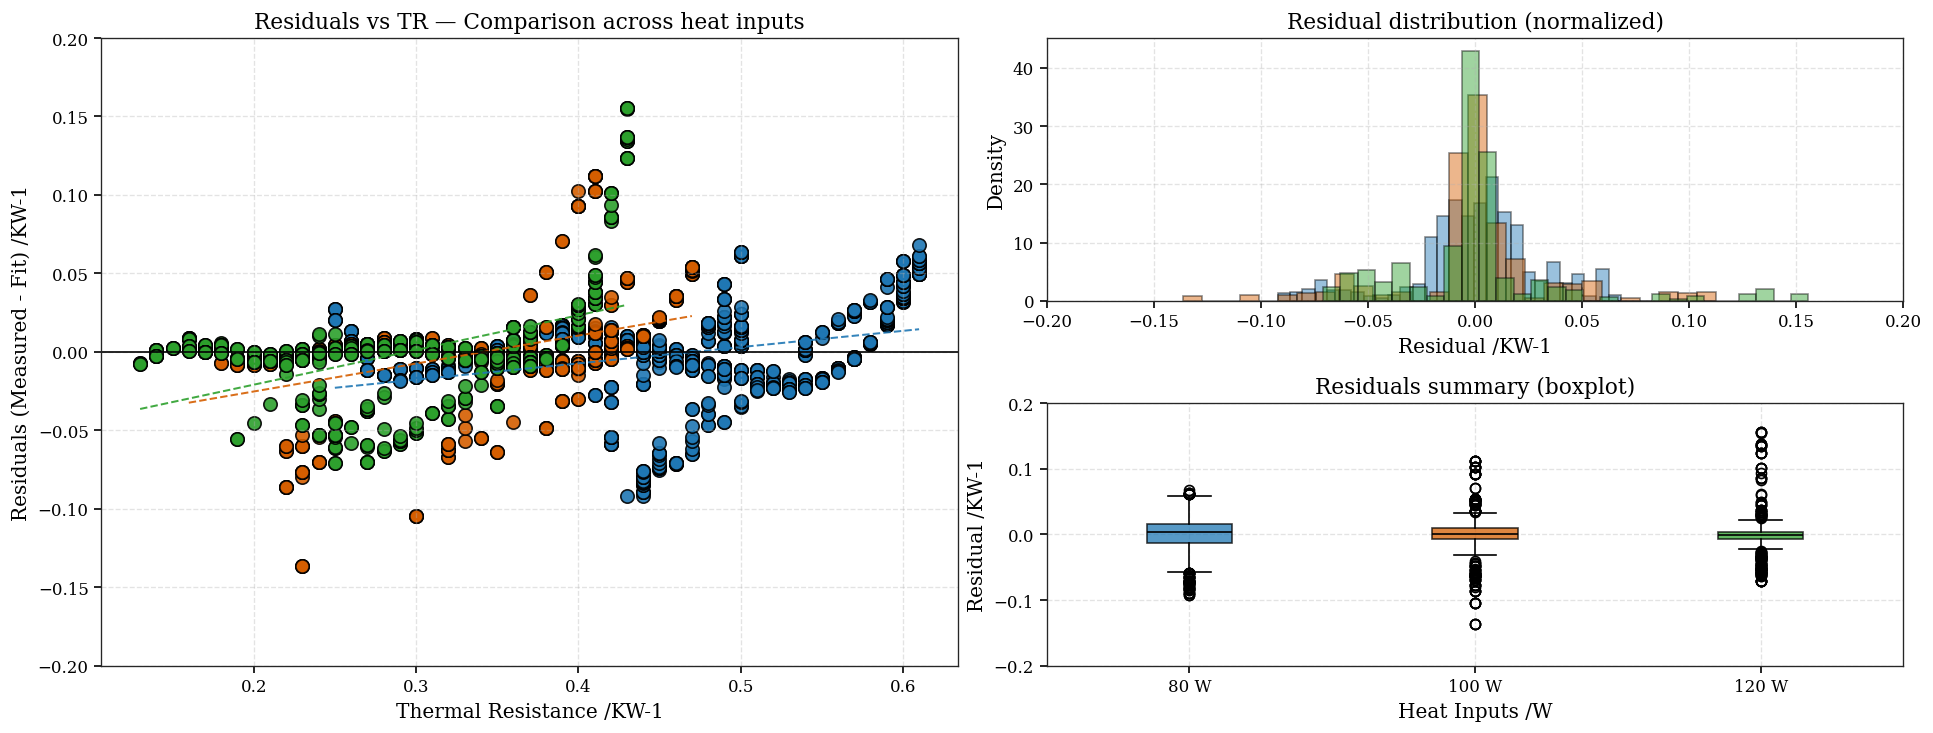

In [ ]:
# ...existing code...
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Publication-quality matplotlib defaults (no seaborn dependency)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5,
    "axes.edgecolor": "0.15"
})


def optimize_polynomial_degree(Te, Y, min_degree=2, max_degree=15, cv_folds=5):
    Te = np.asarray(Te).reshape(-1, 1)
    n = len(Te)
    max_deg = min(max_degree, max(min_degree, max(2, n // 2)))
    degrees = list(range(min_degree, max_deg + 1))
    best_deg = min_degree
    best_score = np.inf
    for d in degrees:
        try:
            pipe = Pipeline([('poly', PolynomialFeatures(degree=d, include_bias=False)),
                             ('lr', LinearRegression())])
            cv = max(2, min(cv_folds, max(2, n // 2)))
            score = -cross_val_score(pipe, Te, Y, cv=cv, scoring='neg_root_mean_squared_error').mean()
            if score < best_score:
                best_score = score
                best_deg = d
        except Exception:
            continue
    return int(best_deg)


def fit_poly_and_residuals(Te, TR, degree='auto', min_deg=2, max_deg=15):
    Te = np.asarray(Te)
    TR = np.asarray(TR)
    if degree == 'auto':
        deg = optimize_polynomial_degree(Te, TR, min_degree=min_deg, max_degree=max_deg)
    else:
        deg = int(degree)
    coeffs = np.polyfit(Te, TR, deg=deg)
    poly = np.poly1d(coeffs)
    TR_pred = poly(Te)
    residuals = TR - TR_pred
    stats = {
        'deg': deg,
        'rmse': float(np.sqrt(mean_squared_error(TR, TR_pred))),
        'mean_res': float(np.mean(residuals)),
        'std_res': float(np.std(residuals)),
        'med_res': float(np.median(residuals)),
        'n': int(len(TR))
    }
    return {'Te': Te, 'TR': TR, 'TR_pred': TR_pred, 'residuals': residuals, 'coeffs': coeffs, 'stats': stats}


def load_filtered_data(csv_path, Q, FR=60, alpha=90, beta=0, te_min=None, te_max=None, outlier_z=2.5):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    df = df[(df.get('Q[W]') == Q) & (df.get('FR[%]') == FR) & (df.get('alpha') == alpha) & (df.get('beta') == beta)]
    if te_min is not None:
        df = df[df['Te_mean[K]'] >= te_min]
    if te_max is not None:
        df = df[df['Te_mean[K]'] <= te_max]
    if df.empty or 'TR[K/W]' not in df.columns:
        return None
    df = df[np.abs(zscore(df['TR[K/W]'])) < outlier_z]
    df = df.sort_values('Te_mean[K]')
    return df[['Te_mean[K]', 'TR[K/W]']].rename(columns={'Te_mean[K]': 'Te', 'TR[K/W]': 'TR'})


def publication_compare_residuals(csv_path,
                                  Q_list=(80, 100, 120),
                                  FR=60, alpha=90, beta=0,
                                  te_range=None,
                                  deg_choice='auto', min_deg=2, max_deg=15,
                                  save_path=None):
    colors = {80: '#1f77b4', 100: '#d55e00', 120: '#2ca02c'}
    results = {}
    for Q in Q_list:
        df = load_filtered_data(csv_path, Q, FR=FR, alpha=alpha, beta=beta,
                                te_min=(te_range[0] if te_range else None),
                                te_max=(te_range[1] if te_range else None))
        if df is None or df.empty:
            continue
        res = fit_poly_and_residuals(df['Te'].values, df['TR'].values,
                                     degree=deg_choice, min_deg=min_deg, max_deg=max_deg)
        results[Q] = {'df': df, **res}

    if not results:
        raise RuntimeError("No data found for requested Q conditions.")

    fig = plt.figure(constrained_layout=True, figsize=(16, 6))
    gs = fig.add_gridspec(2, 4)

    ax_scatter = fig.add_subplot(gs[:, :2])
    ax_hist = fig.add_subplot(gs[0, 2:])
    ax_box = fig.add_subplot(gs[1, 2:])

    for Q, dat in results.items():
        TR = dat['TR']
        resids = dat['residuals']
        ax_scatter.scatter(TR, resids, label=f'{Q} W (n={dat["stats"]["n"]}, deg={dat["stats"]["deg"]})',
                           color=colors.get(Q, '#444444'), alpha=0.9, edgecolor='k', s=64)
        if len(TR) > 1:
            try:
                m, b = np.polyfit(TR, resids, 1)
                x_line = np.linspace(np.min(TR), np.max(TR), 120)
                ax_scatter.plot(x_line, m * x_line + b, color=colors.get(Q), linestyle='--', linewidth=1.2, alpha=0.9)
            except Exception:
                pass

    ax_scatter.axhline(0, color='k', linewidth=1.0, linestyle='-')
    ax_scatter.set_xlabel('Thermal Resistance /KW-1')
    ax_scatter.set_ylabel('Residuals (Measured - Fit) /KW-1')
    ax_scatter.set_title('Residuals vs TR — Comparison across heat inputs')

    # force residual y-range to [-0.20, 0.20]
    ax_scatter.set_ylim(-0.20, 0.20)

    bins = 28
    for Q, dat in results.items():
        ax_hist.hist(dat['residuals'], bins=bins, alpha=0.45, label=f'{Q} W', color=colors.get(Q),
                     density=True, edgecolor='k')
    ax_hist.set_xlabel('Residual /KW-1')
    ax_hist.set_ylabel('Density')
    ax_hist.set_title('Residual distribution (normalized)')
    # limit histogram x-range to residual bounds
    ax_hist.set_xlim(-0.20, 0.20)

    sorted_Q = sorted(results.keys())
    data_for_box = [results[q]['residuals'] for q in sorted_Q]
    box = ax_box.boxplot(data_for_box, labels=[f'{q} W' for q in sorted_Q], patch_artist=True, medianprops=dict(color='black'))
    for patch, q in zip(box['boxes'], sorted_Q):
        patch.set_facecolor(colors.get(q, '#888888'))
        patch.set_alpha(0.75)
    
    ax_box.set_xlabel('Heat Inputs /W')
    ax_box.set_ylabel('Residual /KW-1')
    ax_box.set_title('Residual summary (boxplot)')
    # force residual y-range to [-0.20, 0.20]
    ax_box.set_ylim(-0.20, 0.20)

    stats_lines = []
    for q in sorted_Q:
        s = results[q]['stats']
        stats_lines.append(f"{q}W — n={s['n']}, deg={s['deg']}, RMSE={s['rmse']:.4f}, mean={s['mean_res']:.4f}, std={s['std_res']:.4f}")
    
    # Optional summary textbox (commented out by default)
    # fig.text(0.76, 0.45, "Summary statistics\n\n" + "\n".join(stats_lines),
    #          fontsize=10, bbox=dict(boxstyle="round,pad=0.6", fc="white", ec="0.3"))

    for ax in (ax_scatter, ax_hist, ax_box):
        ax.tick_params(direction='out', length=4, width=1)

    if save_path:
        d = os.path.dirname(save_path)
        if d:
            os.makedirs(d, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()
    return results


if __name__ == "__main__":
    # adjust path to your local CSV as required
    csv_path = "database.csv"
    Q_list = [80, 100, 120]
    te_range = (320, 358)  # None to use full available range
    try:
        publication_compare_residuals(csv_path=csv_path,
                                      Q_list=Q_list,
                                      FR=60, alpha=90, beta=0,
                                      te_range=te_range,
                                      deg_choice='auto',
                                      min_deg=5, max_deg=5,
                                      #save_path=os.path.join(os.path.dirname(__file__), "figures", "residuals_comparison_Q80_100_120.png"))
                                      save_path=None)
    except Exception as e:
        print("Error:", e)


## main plots

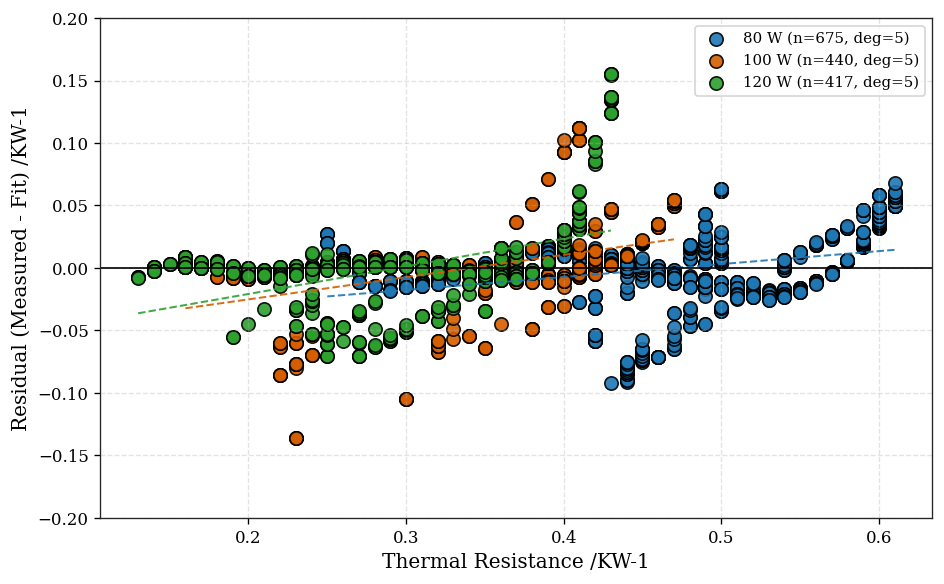

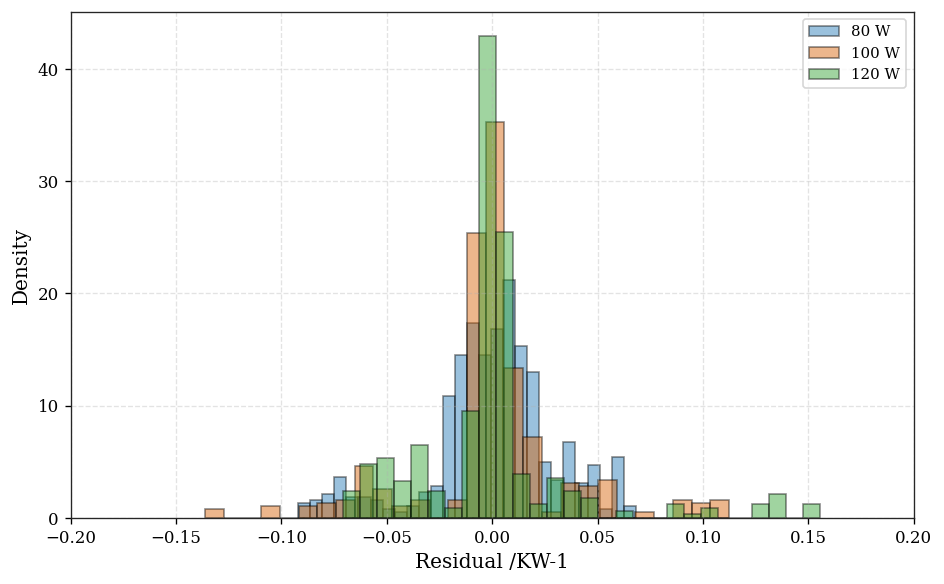

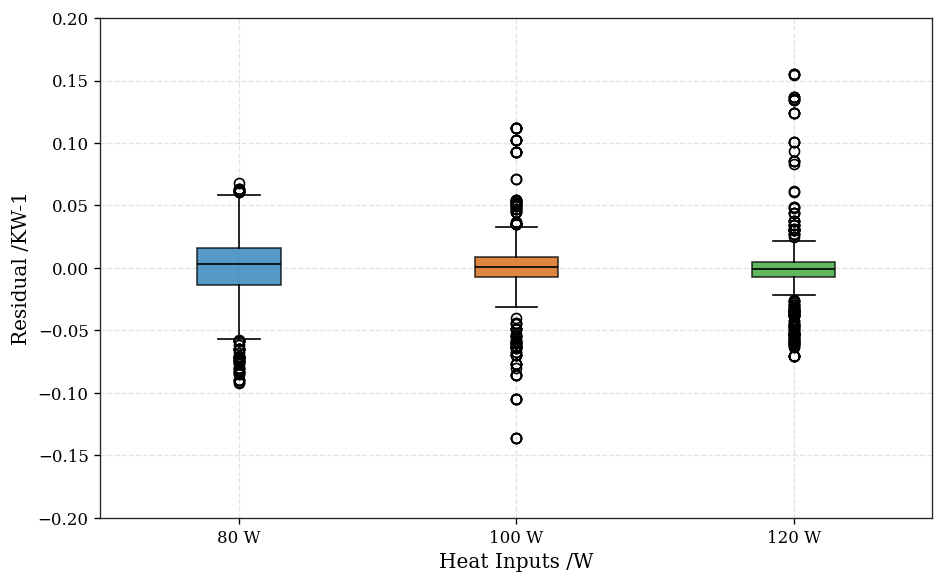

In [77]:
# ...existing code...
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Publication-quality matplotlib defaults (no seaborn dependency)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5,
    "axes.edgecolor": "0.15"
})


def optimize_polynomial_degree(Te, Y, min_degree=2, max_degree=15, cv_folds=5):
    Te = np.asarray(Te).reshape(-1, 1)
    n = len(Te)
    max_deg = min(max_degree, max(min_degree, max(2, n // 2)))
    degrees = list(range(min_degree, max_deg + 1))
    best_deg = min_degree
    best_score = np.inf
    for d in degrees:
        try:
            pipe = Pipeline([('poly', PolynomialFeatures(degree=d, include_bias=False)),
                             ('lr', LinearRegression())])
            cv = max(2, min(cv_folds, max(2, n // 2)))
            score = -cross_val_score(pipe, Te, Y, cv=cv, scoring='neg_root_mean_squared_error').mean()
            if score < best_score:
                best_score = score
                best_deg = d
        except Exception:
            continue
    return int(best_deg)


def fit_poly_and_residuals(Te, TR, degree='auto', min_deg=2, max_deg=15):
    Te = np.asarray(Te)
    TR = np.asarray(TR)
    if degree == 'auto':
        deg = optimize_polynomial_degree(Te, TR, min_degree=min_deg, max_degree=max_deg)
    else:
        deg = int(degree)
    coeffs = np.polyfit(Te, TR, deg=deg)
    poly = np.poly1d(coeffs)
    TR_pred = poly(Te)
    residuals = TR - TR_pred
    stats = {
        'deg': deg,
        'rmse': float(np.sqrt(mean_squared_error(TR, TR_pred))),
        'mean_res': float(np.mean(residuals)),
        'std_res': float(np.std(residuals)),
        'med_res': float(np.median(residuals)),
        'n': int(len(TR))
    }
    return {'Te': Te, 'TR': TR, 'TR_pred': TR_pred, 'residuals': residuals, 'coeffs': coeffs, 'stats': stats}


def load_filtered_data(csv_path, Q, FR=60, alpha=90, beta=0, te_min=None, te_max=None, outlier_z=2.5):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    df = df[(df.get('Q[W]') == Q) & (df.get('FR[%]') == FR) & (df.get('alpha') == alpha) & (df.get('beta') == beta)]
    if te_min is not None:
        df = df[df['Te_mean[K]'] >= te_min]
    if te_max is not None:
        df = df[df['Te_mean[K]'] <= te_max]
    if df.empty or 'TR[K/W]' not in df.columns:
        return None
    df = df[np.abs(zscore(df['TR[K/W]'])) < outlier_z]
    df = df.sort_values('Te_mean[K]')
    return df[['Te_mean[K]', 'TR[K/W]']].rename(columns={'Te_mean[K]': 'Te', 'TR[K/W]': 'TR'})

# ...existing code...
def publication_compare_residuals(csv_path,
                                  Q_list=(80, 100, 120),
                                  FR=60, alpha=90, beta=0,
                                  te_range=None,
                                  deg_choice='auto', min_deg=2, max_deg=15,
                                  save_path=None):
    colors = {80: '#1f77b4', 100: '#d55e00', 120: '#2ca02c'}
    results = {}
    for Q in Q_list:
        df = load_filtered_data(csv_path, Q, FR=FR, alpha=alpha, beta=beta,
                                te_min=(te_range[0] if te_range else None),
                                te_max=(te_range[1] if te_range else None))
        if df is None or df.empty:
            continue
        res = fit_poly_and_residuals(df['Te'].values, df['TR'].values,
                                     degree=deg_choice, min_deg=min_deg, max_deg=max_deg)
        results[Q] = {'df': df, **res}

    if not results:
        raise RuntimeError("No data found for requested Q conditions.")

    # 1) Residuals vs TR (scatter + optional trend line)
    fig_scatter, ax_scatter = plt.subplots(figsize=(8, 5))
    for Q, dat in results.items():
        TR = dat['TR']
        resids = dat['residuals']
        ax_scatter.scatter(TR, resids, label=f'{Q} W (n={dat["stats"]["n"]}, deg={dat["stats"]["deg"]})',
                           color=colors.get(Q, '#444444'), alpha=0.9, edgecolor='k', s=64)
        if len(TR) > 1:
            try:
                m, b = np.polyfit(TR, resids, 1)
                x_line = np.linspace(np.min(TR), np.max(TR), 120)
                ax_scatter.plot(x_line, m * x_line + b, color=colors.get(Q), linestyle='--', linewidth=1.2, alpha=0.9)
            except Exception:
                pass
    ax_scatter.axhline(0, color='k', linewidth=1.0, linestyle='-')
    ax_scatter.set_xlabel('Thermal Resistance /KW-1')
    ax_scatter.set_ylabel('Residual (Measured - Fit) /KW-1')
    #ax_scatter.set_title('Residual vs TR — Comparison across heat inputs')
    ax_scatter.set_ylim(-0.20, 0.20)
    ax_scatter.legend(fontsize=9, loc='best')
    ax_scatter.grid(True, alpha=0.35)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        scatter_path = f"{base}_scatter{ext or '.png'}"
        fig_scatter.savefig(scatter_path, dpi=300, bbox_inches='tight')
    plt.show()

    # 2) Residuals distribution (normalized histogram, overlaid)
    fig_hist, ax_hist = plt.subplots(figsize=(8, 5))
    bins = 28
    for Q, dat in results.items():
        ax_hist.hist(dat['residuals'], bins=bins, alpha=0.45, label=f'{Q} W', color=colors.get(Q),
                     density=True, edgecolor='k')
    ax_hist.set_xlabel('Residual /KW-1')
    ax_hist.set_ylabel('Density')
    #ax_hist.set_title('Residual distribution (normalized) for all Heat Inputs')
    ax_hist.set_xlim(-0.20, 0.20)
    ax_hist.legend(fontsize=9)
    ax_hist.grid(True, alpha=0.35)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        hist_path = f"{base}_hist{ext or '.png'}"
        fig_hist.savefig(hist_path, dpi=300, bbox_inches='tight')
    plt.show()

    # 3) Residual summary (boxplot)
    sorted_Q = sorted(results.keys())
    data_for_box = [results[q]['residuals'] for q in sorted_Q]
    fig_box, ax_box = plt.subplots(figsize=(8, 5))
    box = ax_box.boxplot(data_for_box, labels=[f'{q} W' for q in sorted_Q], patch_artist=True, medianprops=dict(color='black'))
    for patch, q in zip(box['boxes'], sorted_Q):
        patch.set_facecolor(colors.get(q, '#888888'))
        patch.set_alpha(0.75)
    ax_box.set_xlabel('Heat Inputs /W')
    ax_box.set_ylabel('Residual /KW-1')
    #ax_box.set_title('Residual summary (boxplot)')
    ax_box.set_ylim(-0.20, 0.20)
    ax_box.grid(True, alpha=0.35)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        box_path = f"{base}_box{ext or '.png'}"
        fig_box.savefig(box_path, dpi=300, bbox_inches='tight')
    plt.show()

    return results


if __name__ == "__main__":
    # adjust path to your local CSV as required
    csv_path = "database.csv"
    Q_list = [80, 100, 120]
    te_range = (320, 358)  # None to use full available range
    try:
        publication_compare_residuals(csv_path=csv_path,
                                      Q_list=Q_list,
                                      FR=60, alpha=90, beta=0,
                                      te_range=te_range,
                                      deg_choice='auto',
                                      min_deg=5, max_deg=5,
                                      save_path=None)
    except Exception as e:
        print("Error:", e)
# ...existing code...

## For Publication

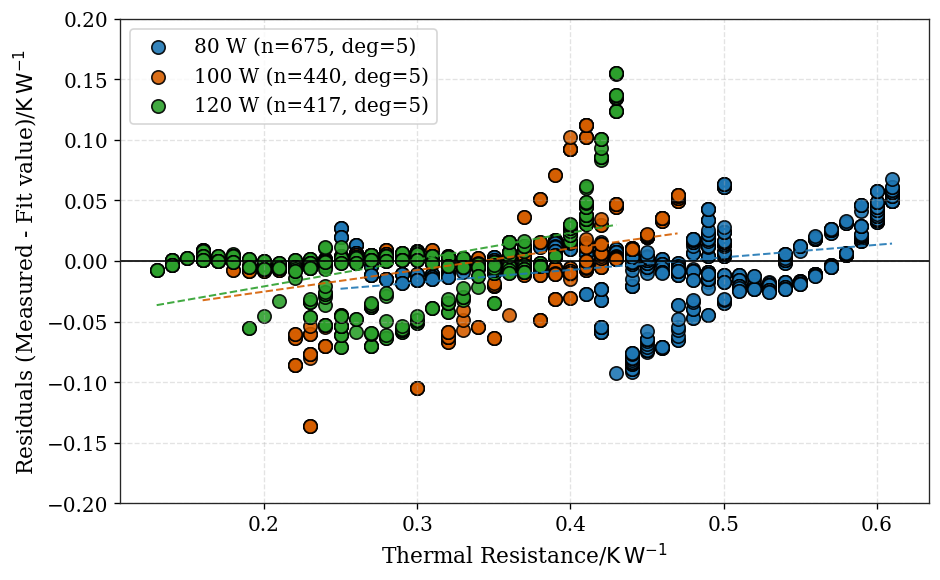

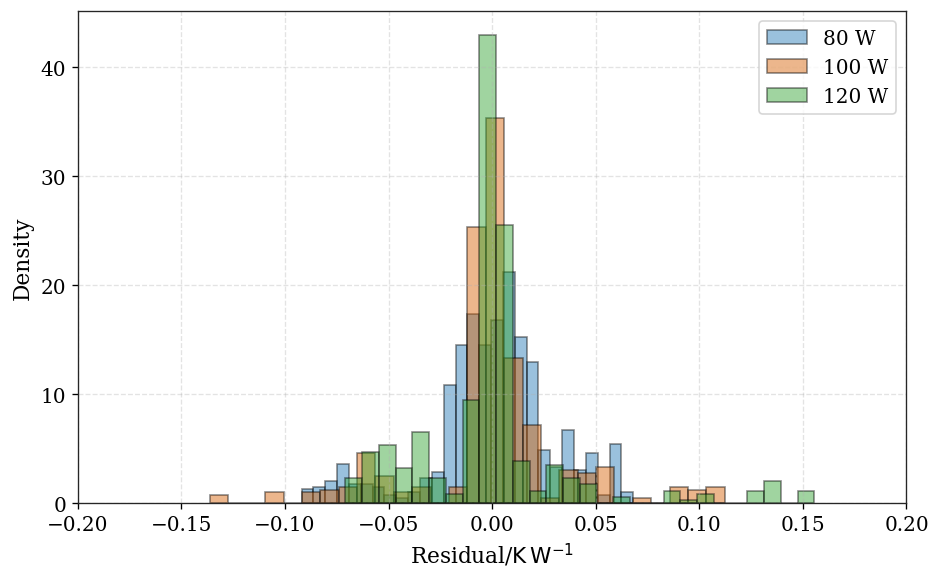

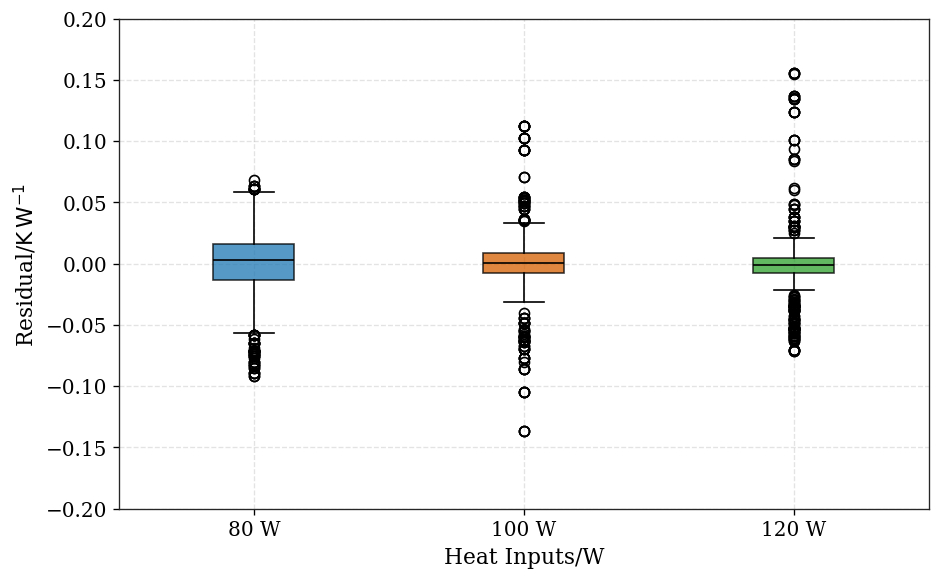

In [88]:
# ...existing code...
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import zscore
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error

# Publication-quality matplotlib defaults (no seaborn dependency)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5,
    "axes.edgecolor": "0.15"
})


def optimize_polynomial_degree(Te, Y, min_degree=2, max_degree=15, cv_folds=5):
    Te = np.asarray(Te).reshape(-1, 1)
    n = len(Te)
    max_deg = min(max_degree, max(min_degree, max(2, n // 2)))
    degrees = list(range(min_degree, max_deg + 1))
    best_deg = min_degree
    best_score = np.inf
    for d in degrees:
        try:
            pipe = Pipeline([('poly', PolynomialFeatures(degree=d, include_bias=False)),
                             ('lr', LinearRegression())])
            cv = max(2, min(cv_folds, max(2, n // 2)))
            score = -cross_val_score(pipe, Te, Y, cv=cv, scoring='neg_root_mean_squared_error').mean()
            if score < best_score:
                best_score = score
                best_deg = d
        except Exception:
            continue
    return int(best_deg)


def fit_poly_and_residuals(Te, TR, degree='auto', min_deg=2, max_deg=15):
    Te = np.asarray(Te)
    TR = np.asarray(TR)
    if degree == 'auto':
        deg = optimize_polynomial_degree(Te, TR, min_degree=min_deg, max_degree=max_deg)
    else:
        deg = int(degree)
    coeffs = np.polyfit(Te, TR, deg=deg)
    poly = np.poly1d(coeffs)
    TR_pred = poly(Te)
    residuals = TR - TR_pred
    stats = {
        'deg': deg,
        'rmse': float(np.sqrt(mean_squared_error(TR, TR_pred))),
        'mean_res': float(np.mean(residuals)),
        'std_res': float(np.std(residuals)),
        'med_res': float(np.median(residuals)),
        'n': int(len(TR))
    }
    return {'Te': Te, 'TR': TR, 'TR_pred': TR_pred, 'residuals': residuals, 'coeffs': coeffs, 'stats': stats}


def load_filtered_data(csv_path, Q, FR=60, alpha=90, beta=0, te_min=None, te_max=None, outlier_z=2.5):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV not found: {csv_path}")
    df = pd.read_csv(csv_path)
    df = df[(df.get('Q[W]') == Q) & (df.get('FR[%]') == FR) & (df.get('alpha') == alpha) & (df.get('beta') == beta)]
    if te_min is not None:
        df = df[df['Te_mean[K]'] >= te_min]
    if te_max is not None:
        df = df[df['Te_mean[K]'] <= te_max]
    if df.empty or 'TR[K/W]' not in df.columns:
        return None
    df = df[np.abs(zscore(df['TR[K/W]'])) < outlier_z]
    df = df.sort_values('Te_mean[K]')
    return df[['Te_mean[K]', 'TR[K/W]']].rename(columns={'Te_mean[K]': 'Te', 'TR[K/W]': 'TR'})

# ...existing code...
def publication_compare_residuals(csv_path,
                                  Q_list=(80, 100, 120),
                                  FR=60, alpha=90, beta=0,
                                  te_range=None,
                                  deg_choice='auto', min_deg=2, max_deg=15,
                                  save_path=None):
    colors = {80: '#1f77b4', 100: '#d55e00', 120: '#2ca02c'}
    results = {}
    for Q in Q_list:
        df = load_filtered_data(csv_path, Q, FR=FR, alpha=alpha, beta=beta,
                                te_min=(te_range[0] if te_range else None),
                                te_max=(te_range[1] if te_range else None))
        if df is None or df.empty:
            continue
        res = fit_poly_and_residuals(df['Te'].values, df['TR'].values,
                                     degree=deg_choice, min_deg=min_deg, max_deg=max_deg)
        results[Q] = {'df': df, **res}

    if not results:
        raise RuntimeError("No data found for requested Q conditions.")

    # 1) Residuals vs TR (scatter + optional trend line)
    fig_scatter, ax_scatter = plt.subplots(figsize=(8, 5))
    for Q, dat in results.items():
        TR = dat['TR']
        resids = dat['residuals']
        ax_scatter.scatter(TR, resids, label=f'{Q} W (n={dat["stats"]["n"]}, deg={dat["stats"]["deg"]})',
                           color=colors.get(Q, '#444444'), alpha=0.9, edgecolor='k', s=64)
        if len(TR) > 1:
            try:
                m, b = np.polyfit(TR, resids, 1)
                x_line = np.linspace(np.min(TR), np.max(TR), 120)
                ax_scatter.plot(x_line, m * x_line + b, color=colors.get(Q), linestyle='--', linewidth=1.2, alpha=0.9)
            except Exception:
                pass
    ax_scatter.axhline(0, color='k', linewidth=1.0, linestyle='-')
    ax_scatter.set_xlabel(r'Thermal Resistance/$\mathrm{K\,W^{-1}}$')
    ax_scatter.set_ylabel(r'Residuals (Measured - Fit value)/$\mathrm{K\,W^{-1}}$')
    #ax_scatter.set_title('Residual vs TR — Comparison across heat inputs')
    ax_scatter.set_ylim(-0.20, 0.20)
    ax_scatter.legend(fontsize=12, loc='best')
    ax_scatter.grid(True, alpha=0.35)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        scatter_path = f"{base}_scatter{ext or '.png'}"
        fig_scatter.savefig(scatter_path, dpi=300, bbox_inches='tight')
    plt.show()

    # 2) Residuals distribution (normalized histogram, overlaid)
    fig_hist, ax_hist = plt.subplots(figsize=(8, 5))
    bins = 28
    for Q, dat in results.items():
        ax_hist.hist(dat['residuals'], bins=bins, alpha=0.45, label=f'{Q} W', color=colors.get(Q),
                     density=True, edgecolor='k')
    ax_hist.set_xlabel(r'Residual/$\mathrm{K\,W^{-1}}$')
    ax_hist.set_ylabel('Density')
    #ax_hist.set_title('Residual distribution (normalized) for all Heat Inputs')
    ax_hist.set_xlim(-0.20, 0.20)
    ax_hist.legend(fontsize=12)
    ax_hist.grid(True, alpha=0.35)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        hist_path = f"{base}_hist{ext or '.png'}"
        fig_hist.savefig(hist_path, dpi=300, bbox_inches='tight')
    plt.show()

    # 3) Residual summary (boxplot)
    sorted_Q = sorted(results.keys())
    data_for_box = [results[q]['residuals'] for q in sorted_Q]
    fig_box, ax_box = plt.subplots(figsize=(8, 5))
    box = ax_box.boxplot(data_for_box, labels=[f'{q} W' for q in sorted_Q], patch_artist=True, medianprops=dict(color='black'))
    for patch, q in zip(box['boxes'], sorted_Q):
        patch.set_facecolor(colors.get(q, '#888888'))
        patch.set_alpha(0.75)
    ax_box.set_xlabel('Heat Inputs/W')
    ax_box.set_ylabel(r'Residual/$\mathrm{K\,W^{-1}}$')
    #ax_box.set_title('Residual summary (boxplot)')
    ax_box.set_ylim(-0.20, 0.20)
    ax_box.grid(True, alpha=0.35)
    plt.tight_layout()
    if save_path:
        base, ext = os.path.splitext(save_path)
        box_path = f"{base}_box{ext or '.png'}"
        fig_box.savefig(box_path, dpi=300, bbox_inches='tight')
    plt.show()

    return results


if __name__ == "__main__":
    # adjust path to your local CSV as required
    csv_path = "database.csv"
    Q_list = [80, 100, 120]
    te_range = (320, 358)  # None to use full available range
    try:
        publication_compare_residuals(csv_path=csv_path,
                                      Q_list=Q_list,
                                      FR=60, alpha=90, beta=0,
                                      te_range=te_range,
                                      deg_choice='auto',
                                      min_deg=5, max_deg=5,
                                      save_path=None)
    except Exception as e:
        print("Error:", e)
# ...existing code...